In [ ]:
# plot the light curves of other sources and the variability S/N checking plot

Duplicate key in file '/Users/zijianzhang/Astro_Data/paper.mplstyle', line 23 ('axes.linewidth : 1.5')


In [1]:
#rename file
import os
import glob
from astropy.io import fits
import numpy as np
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt
from scipy.optimize import leastsq
from scipy.optimize import fsolve
from scipy.optimize import minimize
import os
import re
from astropy.table import Table
import astropy.units as u
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from photutils.aperture import SkyCircularAperture, SkyCircularAnnulus
from photutils.aperture import aperture_photometry
from photutils.centroids import centroid_com
from astropy.stats import sigma_clipped_stats
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import make_lupton_rgb, AsinhStretch, MinMaxInterval
import os
from matplotlib.patches import Rectangle
import matplotlib.transforms as transforms

plt.style.use('/Users/zijianzhang/Astro_Data/paper.mplstyle')

def nJy_to_ABmag(flux, flux_error):
    """
    将流量 (nJy) 转换为 AB 星等，并计算误差。
    
    参数:
        flux (float or np.ndarray): 流量值，单位为 nJy。
        flux_error (float or np.ndarray): 流量的误差，单位为 nJy。
    
    返回:
        tuple: 星等 (magnitude) 和星等误差 (magnitude_error)。
    """
    # 防止非正流量导致对数计算报错
    flux = np.array(flux)
    flux_error = np.array(flux_error)
    
    # 仅对 flux > 0 计算
    valid = flux > 0
    magnitude = np.full_like(flux, np.nan, dtype=np.float64)  # 默认 NaN
    magnitude_error = np.full_like(flux, np.nan, dtype=np.float64)  # 默认 NaN
    
    if np.any(valid):
        magnitude[valid] = -2.5 * np.log10(flux[valid]) + 31.4
        magnitude_error[valid] = 2.5 / np.log(10) * (flux_error[valid] / flux[valid])
    
    return magnitude, magnitude_error

Duplicate key in file '/Users/zijianzhang/Astro_Data/paper.mplstyle', line 23 ('axes.linewidth : 1.5')


In [3]:

def read_lens_data(filename):
    """
    读取 lensing 参数文件并解析为字典。
    每个系统像 (如 4.1, 16.2) 的数据结构：
        {'x': (value, +err, -err), 'y': (...), 'mu': (...), 'dt': (...)}
    """
    data = {}

    pattern = re.compile(
        r'(?P<param>[xy]|mu|dt)\((?P<id>[\d\.]+)\).*?([ \t]+)?(?P<value>[-\d\.]+)\^\{\+(?P<errp>[\d\.]+)\}_\{\-(?P<errm>[\d\.]+)\}'
    )

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = pattern.search(line)
            if m:
                param = m.group('param')
                if param == 'dt':  # 处理 dt(4.1)[day] 这种情况
                    param = 'dt'
                img_id = m.group('id')
                val = float(m.group('value'))
                errp = float(m.group('errp'))
                errm = float(m.group('errm'))

                if img_id not in data:
                    data[img_id] = {}
                data[img_id][param] = (val, errp, errm)
    return data

lens_data_file = '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/RXCJ2211/full_output.csv'
# lens_data_file = '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/rj2211_glafic_v0p9_summary_mu_td_others.dat'
# lens_dict = read_lens_data(lens_data_file)
lens_dict = Table.read(lens_data_file) 
lens_IDs = Table.read('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/RXCJ2211-multi-img/multi-img.dat', format = 'ascii')
tab_hst_jwst_combined  = Table.read('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/sfw_image/RXCJ2211-0350_v01_merged_phot_multiimage.fits', 2)


In [4]:
hdu = fits.open('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/sfw_image/RXCJ2211-0350_v01_merged_phot.fits')
hdu[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 2792 / length of dimension 1                          
NAXIS2  =                 7739 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                  350 / number of table fields                         
EXTNAME = 'PHOT    '           / extension name                                 
TTYPE1  = 'ID      '                                                            
TFORM1  = 'J       '                                                            
TTYPE2  = 'RA      '                                                            
TFORM2  = 'D       '        

In [5]:
mask = np.array([int(i) == 8 for i in tab_hst_jwst_combined['id_1']])
tab_hst_jwst_combined[mask]

id_1,ra_1,dec_1,z_lensing,mu_best,mu_tan_best,mu_rad_best,theta_best,deflect_x_best,deflect_y_best,ra_source_best,dec_source_best,mu_50,mu_16,mu_84,mu_rad_50,mu_rad_16,mu_rad_84,mu_tan_50,mu_tan_16,mu_tan_84,theta_50,theta_16,theta_84,deflect_x_50,deflect_y_50,deflect_x_16,deflect_y_16,deflect_x_84,deflect_y_84,ra_source_50,dec_source_50,ra_source_16,dec_source_16,ra_source_84,dec_source_84,ID_2,RA_2,DEC_2,X,Y,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_sigma,semiminor_sigma,orientation,eccentricity,min_value,max_value,local_background,kron_radius,Gini,det_segment_flux,det_segment_fluxerr,det_kron_flux,det_kron_fluxerr,F090W_CIRC1,F090W_CIRC1_e,F090W_CIRC1_en,F090W_CIRC2,F090W_CIRC2_e,F090W_CIRC2_en,F090W_CIRC3,F090W_CIRC3_e,F090W_CIRC3_en,F090W_CIRC4,F090W_CIRC4_e,F090W_CIRC4_en,F090W_CIRC5,F090W_CIRC5_e,F090W_CIRC5_en,F090W_CIRC6,F090W_CIRC6_e,F090W_CIRC6_en,F090W_KRON,F090W_KRON_S,F090W_KRON_S_e,F090W_KRON_S_en,F090W_KRON_e,F090W_KRON_en,F090W_local_background,F090W_segment_flux,F090W_segment_flux_err,F115W_CIRC1,F115W_CIRC1_e,F115W_CIRC1_en,F115W_CIRC2,F115W_CIRC2_e,F115W_CIRC2_en,F115W_CIRC3,F115W_CIRC3_e,F115W_CIRC3_en,F115W_CIRC4,F115W_CIRC4_e,F115W_CIRC4_en,F115W_CIRC5,F115W_CIRC5_e,F115W_CIRC5_en,F115W_CIRC6,F115W_CIRC6_e,F115W_CIRC6_en,F115W_KRON,F115W_KRON_S,F115W_KRON_S_e,F115W_KRON_S_en,F115W_KRON_e,F115W_KRON_en,F115W_local_background,F115W_segment_flux,F115W_segment_flux_err,F150W2_CIRC1,F150W2_CIRC1_e,F150W2_CIRC1_en,F150W2_CIRC2,F150W2_CIRC2_e,F150W2_CIRC2_en,F150W2_CIRC3,F150W2_CIRC3_e,F150W2_CIRC3_en,F150W2_CIRC4,F150W2_CIRC4_e,F150W2_CIRC4_en,F150W2_CIRC5,F150W2_CIRC5_e,F150W2_CIRC5_en,F150W2_CIRC6,F150W2_CIRC6_e,F150W2_CIRC6_en,F150W2_KRON,F150W2_KRON_S,F150W2_KRON_S_e,F150W2_KRON_S_en,F150W2_KRON_e,F150W2_KRON_en,F150W2_local_background,F150W2_segment_flux,F150W2_segment_flux_err,F150W_CIRC1,F150W_CIRC1_e,F150W_CIRC1_en,F150W_CIRC2,F150W_CIRC2_e,F150W_CIRC2_en,F150W_CIRC3,F150W_CIRC3_e,F150W_CIRC3_en,F150W_CIRC4,F150W_CIRC4_e,F150W_CIRC4_en,F150W_CIRC5,F150W_CIRC5_e,F150W_CIRC5_en,F150W_CIRC6,F150W_CIRC6_e,F150W_CIRC6_en,F150W_KRON,F150W_KRON_S,F150W_KRON_S_e,F150W_KRON_S_en,F150W_KRON_e,F150W_KRON_en,F150W_local_background,F150W_segment_flux,F150W_segment_flux_err,F200W_CIRC1,F200W_CIRC1_e,F200W_CIRC1_en,F200W_CIRC2,F200W_CIRC2_e,F200W_CIRC2_en,F200W_CIRC3,F200W_CIRC3_e,F200W_CIRC3_en,F200W_CIRC4,F200W_CIRC4_e,F200W_CIRC4_en,F200W_CIRC5,F200W_CIRC5_e,F200W_CIRC5_en,F200W_CIRC6,F200W_CIRC6_e,F200W_CIRC6_en,F200W_KRON,F200W_KRON_S,F200W_KRON_S_e,F200W_KRON_S_en,F200W_KRON_e,F200W_KRON_en,F200W_local_background,F200W_segment_flux,F200W_segment_flux_err,F210M_CIRC1,F210M_CIRC1_e,F210M_CIRC1_en,F210M_CIRC2,F210M_CIRC2_e,F210M_CIRC2_en,F210M_CIRC3,F210M_CIRC3_e,F210M_CIRC3_en,F210M_CIRC4,F210M_CIRC4_e,F210M_CIRC4_en,F210M_CIRC5,F210M_CIRC5_e,F210M_CIRC5_en,F210M_CIRC6,F210M_CIRC6_e,F210M_CIRC6_en,F210M_KRON,F210M_KRON_S,F210M_KRON_S_e,F210M_KRON_S_en,F210M_KRON_e,F210M_KRON_en,F210M_local_background,F210M_segment_flux,F210M_segment_flux_err,F277W_CIRC1,F277W_CIRC1_e,F277W_CIRC1_en,F277W_CIRC2,F277W_CIRC2_e,F277W_CIRC2_en,F277W_CIRC3,F277W_CIRC3_e,F277W_CIRC3_en,F277W_CIRC4,F277W_CIRC4_e,F277W_CIRC4_en,F277W_CIRC5,F277W_CIRC5_e,F277W_CIRC5_en,F277W_CIRC6,F277W_CIRC6_e,F277W_CIRC6_en,F277W_KRON,F277W_KRON_S,F277W_KRON_S_e,F277W_KRON_S_en,F277W_KRON_e,F277W_KRON_en,F277W_local_background,F277W_segment_flux,F277W_segment_flux_err,F300M_CIRC1,F300M_CIRC1_e,F300M_CIRC1_en,F300M_CIRC2,F300M_CIRC2_e,F300M_CIRC2_en,F300M_CIRC3,F300M_CIRC3_e,F300M_CIRC3_en,F300M_CIRC4,F300M_CIRC4_e,F300M_CIRC4_en,F300M_CIRC5,F300M_CIRC5_e,F300M_CIRC5_en,F300M_CIRC6,F300M_CIRC6_e,F300M_CIRC6_en,F300M_KRON,F300M_KRON_S,F300M_KRON_S_e,F300M_KRON_S_en,F300M_KRON_e,F300M_KRON_en,F300M_local_background,F300M_segment_flux,F300M_segment_flux_err,F322W2_CIRC1,F322W2_CIRC1_e,F322W2_CIRC1_en,F322W2_CIRC2,F322W2_CIRC2_e,F322W2_CIRC2_en,F322W2_CIRC3,F322W2_CIRC3_e,F322W2_CIRC3_en,F322W2_CIRC4,F322W2_CIRC4_e,F322W2_CIRC4_en,F322W2_CIRC5,F3

(array([ 1.,  0.,  1.,  3.,  1.,  4., 13., 77., 40.,  5.]),
 array([-2.65880319, -2.16675701, -1.67471083, -1.18266465, -0.69061847,
        -0.19857229,  0.29347389,  0.78552007,  1.27756625,  1.76961244,
         2.26165862]),
 <BarContainer object of 10 artists>)

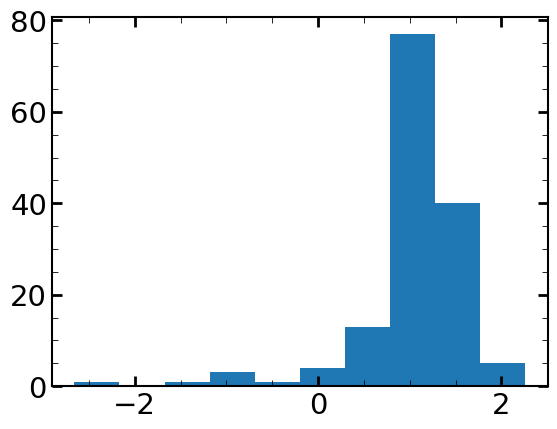

In [6]:
plt.hist(tab_hst_jwst_combined['F444W_CIRC6']/tab_hst_jwst_combined['F444W_CIRC3'])

(array([ 2.,  2.,  6.,  9., 10., 10., 18., 14., 38., 36.]),
 array([0.10763712, 0.19560378, 0.28357044, 0.3715371 , 0.45950376,
        0.54747042, 0.63543708, 0.72340374, 0.8113704 , 0.89933706,
        0.98730372]),
 <BarContainer object of 10 artists>)

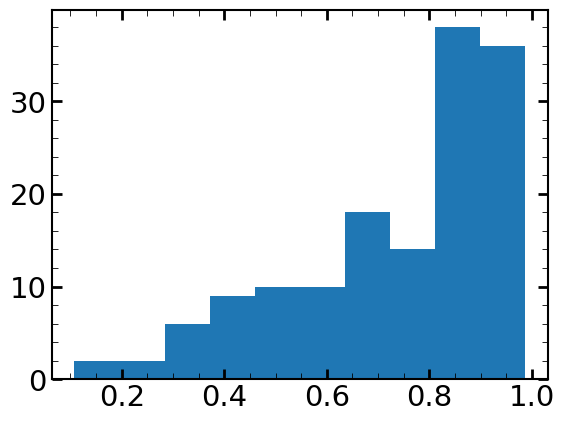

In [7]:
plt.hist(tab_hst_jwst_combined['eccentricity'])

(0.0, 1.0)

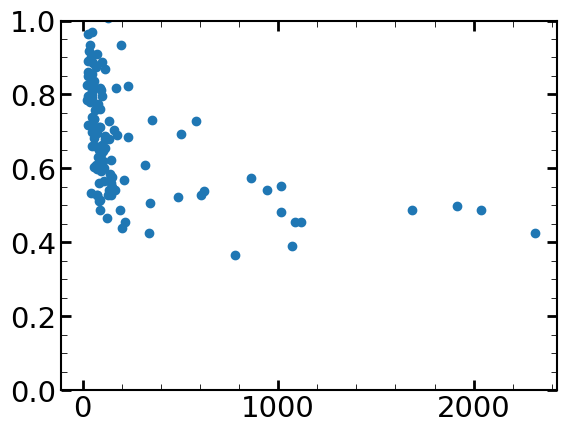

In [8]:
plt.scatter(tab_hst_jwst_combined['F444W_CIRC3'], tab_hst_jwst_combined['F444W_CIRC2']/tab_hst_jwst_combined['F444W_CIRC5']) 
# ~ < 0.7为展源
# COMMENT  - CIRC1:  circular aperture with radius = 0.10 arcsec                  
# COMMENT  - CIRC2:  circular aperture with radius = 0.15 arcsec                  
# COMMENT  - CIRC3:  circular aperture with radius = 0.25 arcsec                  
# COMMENT  - CIRC4:  circular aperture with radius = 0.30 arcsec                  
# COMMENT  - CIRC5:  circular aperture with radius = 0.35 arcsec                  
# COMMENT  - CIRC6:  circular aperture with radius = 0.50 arcsec
plt.ylim(0,1)

In [9]:
IDs_image_mask = (tab_hst_jwst_combined['z_lensing'] > 3.0) #* (tab_hst_jwst_combined['z_lensing'] <6)
contamination = [1.5, 4.1, 4.5, 11.4, 11.5, 11.6, 17.3, 18.1, 18.2, 18.3, 18.4, 19.1, 19.2, 19.3, 21.3,23.1, 26.1, 26.2, 29.1, 29.2, 29.4,30.2, 34.2, 36.1, 36.2,36.3, 36.4, 39.1, 39.2, 41.4]
compact_mask = tab_hst_jwst_combined['eccentricity'] < 0.95
contamination = np.array([str(i) for i in contamination ])
contamination_mask = np.array([str(i) in contamination for i in tab_hst_jwst_combined['id_1']])
sel_image = tab_hst_jwst_combined[IDs_image_mask * compact_mask * (~contamination_mask)]   
IDs_image = np.unique([int(i) for i in sel_image['id_1']])

In [10]:
compact_mask = (tab_hst_jwst_combined['F444W_CIRC2']/tab_hst_jwst_combined['F444W_CIRC5'] > 0.8)#*(tab_hst_jwst_combined['F444W_CIRC2']/tab_hst_jwst_combined['F444W_CIRC5'] < 1)
print(np.unique([int(i) for i in tab_hst_jwst_combined[IDs_image_mask * (~contamination_mask) * compact_mask * compact_mask]['id_1']]))



[ 9 10 11 16 17 21 22 28 30 31 35 37]


In [11]:
# IDs_image_mask = (tab_hst_jwst_combined['z_lensing'] > 3.0) #* (tab_hst_jwst_combined['z_lensing'] <6)
# sel_image = tab_hst_jwst_combined[IDs_image_mask  * (~contamination_mask) * compact_mask]
# len(np.unique([int(i) for i in sel_image['id_1']]))

In [12]:
np.unique([int(i) for i in sel_image['id_1']])

array([ 4,  9, 10, 11, 16, 17, 21, 22, 23, 24, 28, 29, 30, 31, 35, 37, 38,
       39])

In [13]:
IDs_image = np.array([ 4,  9, 10, 11, 16, 17, 21, 22, 23, 24, 28, 29, 30,  35, 37, 38,
       39])

compact = [9,10,11,16,17,21, 28,30,31,35]


In [14]:
IDs_image

array([ 4,  9, 10, 11, 16, 17, 21, 22, 23, 24, 28, 29, 30, 35, 37, 38, 39])

In [15]:
# IDs_image = np.array([ 4,  8,  9, 10, 11,  16, 22, 25,  28, 30, 32, 33, 34, 35, 37,  39, 40,41])

# IDs_image = np.array([ 4,  9, 10, 11, 16,  22, 28,  38])


0


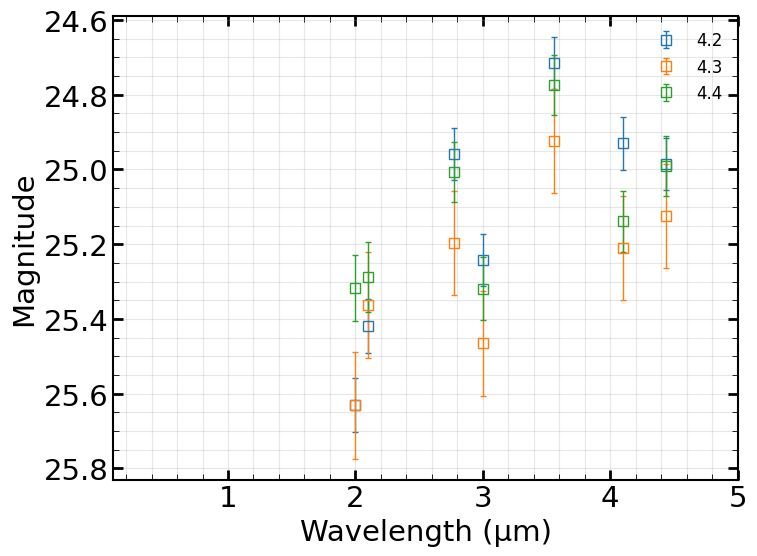

[1.4156379119791123, 0.45671669787310487, 0.9172845345908741]
1


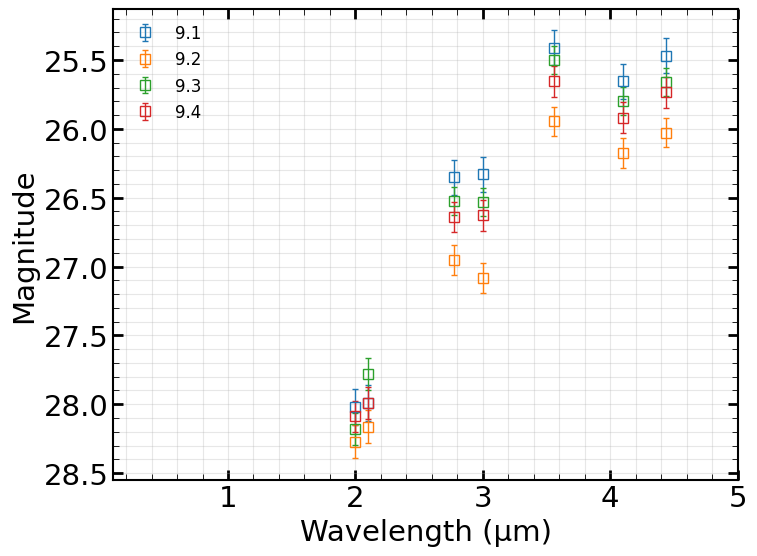

[2.9514267365468134, 0.8992080640152774, 1.5252954898032152, 2.5043880614618, 1.8452591651939882, 0.7801058425173821]
2


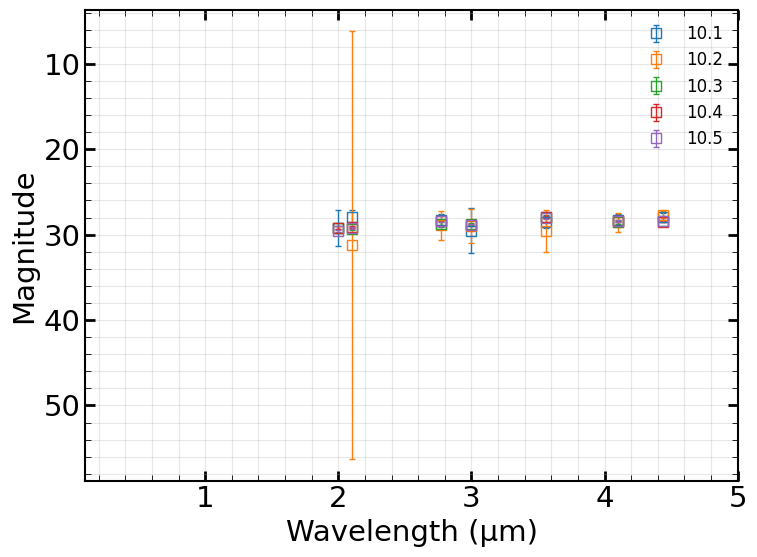

[0.36912687621077517, 0.3156473115174493, 0.005030552773623149, 0.14836316199740618, 0.14859831799863835, 0.2729369515379954, 0.22560269847848957, 0.025311652732982786, 0.21172403617417446, 0.4952589911662519]
3


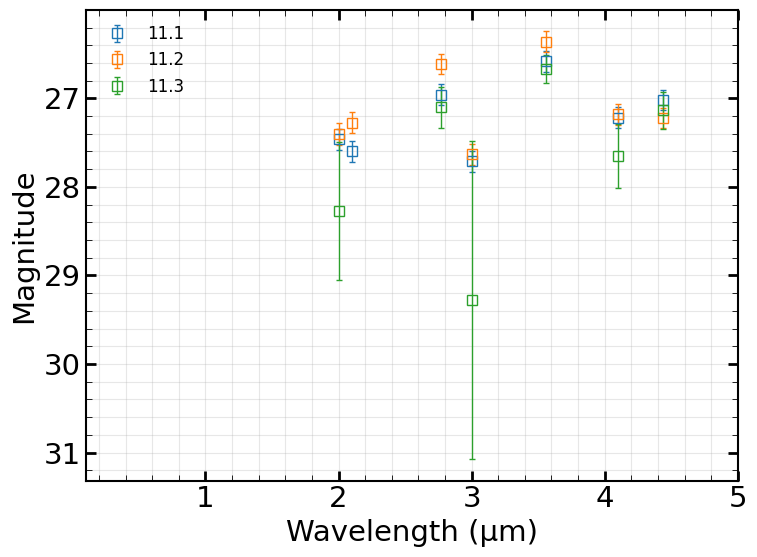

[0.44453141527736256, 1.3149301433033358, 1.618944512676026]
4


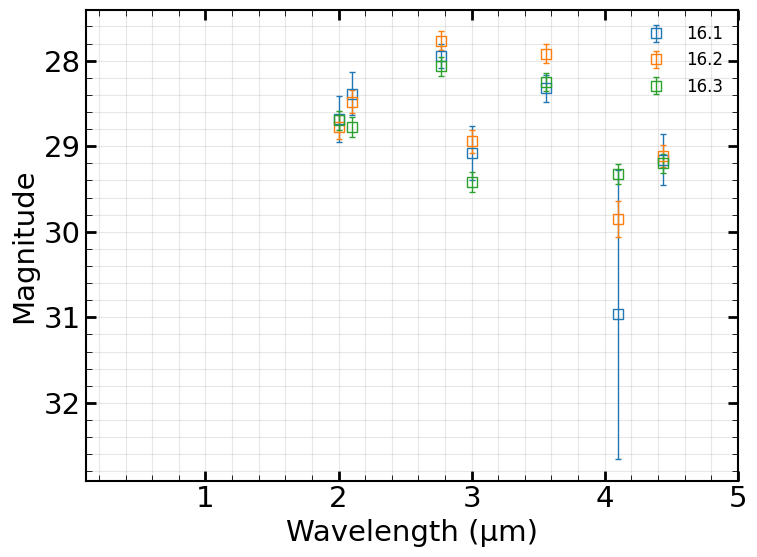

[0.3946877981549465, 0.1296620601087489, 1.6332587251282373]
5


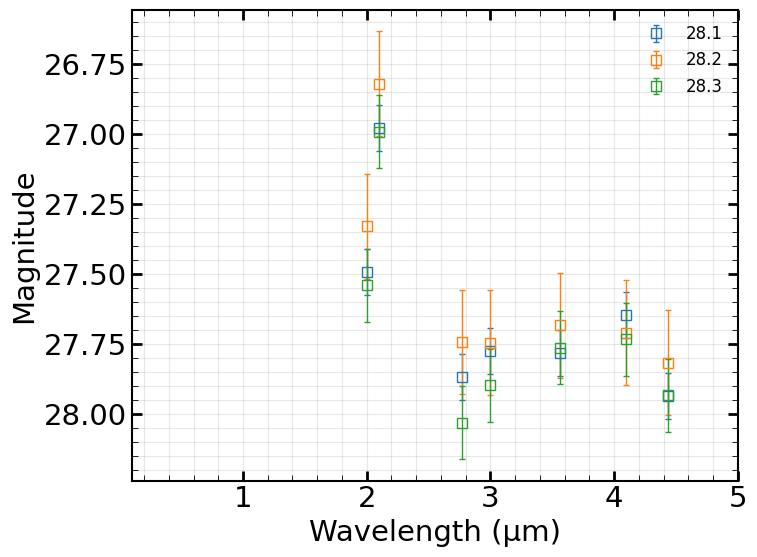

[0.564899917884767, 0.3227803260734067, 0.6460938199895384]


In [16]:
snr_all = []
deltamag_all = []
# final_ID_image = []
final_ID_image = np.array([4, 9, 10, 11, 16, 17, 21, 22, 23, 28, 35, 38, 39])
# for i, ID in enumerate(IDs_image):
goodidx = [0, 1, 9]
goodidx = [0, 1, 2, 3, 4, 9]
IDs_image = final_ID_image[goodidx]
final_ID_image = final_ID_image[goodidx]
for i, ID in enumerate(IDs_image):
    print(i)
    mask = np.array([int(i) == ID for i in sel_image['id_1']])
    sel_tab = sel_image[mask]
    # if(len(sel_tab)<2):
    #     continue
    jwstbands = ['F090W', 'F115W', 'F150W', 'F200W', 'F210M', 'F277W',  'F300M', 'F356W', 'F410M', 'F444W']
    wave_jwst = np.array([0.9, 1.15, 1.50, 2.00, 2.10, 2.77, 3.00, 3.56, 4.10, 4.44])
    jwstbands = [ 'F200W', 'F210M', 'F277W',  'F300M', 'F356W', 'F410M', 'F444W']
    wave_jwst = np.array([ 2.00, 2.10, 2.77, 3.00, 3.56, 4.10, 4.44])

    # fluxkey_jwst = [band.upper() + '_KRON'  for band in jwstbands] 
    # fluxerr_key_jwst = [ band.upper() + '_KRON_e'  for band in jwstbands] 
    if(ID != 9):
        fluxkey_jwst = [band.upper() + '_KRON'  for band in jwstbands] 
        fluxerr_key_jwst = [band.upper() + '_KRON_e'  for band in jwstbands]
    else:
        fluxkey_jwst = [band.upper() + '_CIRC2'  for band in jwstbands] 
        fluxerr_key_jwst = [band.upper() + '_CIRC2_e'  for band in jwstbands]

    # sigkey_hst = [band.lower() + '_sig_new' for band in hstbands] 

    color_cycle = cycle(plt.cm.tab10.colors)  # 给不同像用不同颜色

    # AB mag 转 nJy
    def mag_to_njy(mag):
        return 10**((31.4 - mag) / 2.5)

    color_cycle = cycle(plt.cm.tab10.colors)

    plotted_labels = set()  # 避免重复 legend
    plt.figure(figsize=(8, 6))
    color_cycle = cycle(plt.cm.tab10.colors)
    plotted_labels = set()
    
    ax = plt.gca()

    jwstflux_list = []
    jwstfluxerr_list = []
    for col in sel_tab:
        name = col['id_1']
        color = next(color_cycle)

        mu = col['mu_best']
        mu16 = col['mu_16']
        mu84 = col['mu_84']
        mu_err = np.max([mu84 - mu, mu - mu16])

        jwst_flux      = np.array([col[k] for k in fluxkey_jwst], dtype=float)
        jwst_flux_err  = np.array([col[k] for k in fluxerr_key_jwst], dtype=float)

        mu_abs = np.abs(mu)

        # jwst_mag_corr = jwst_mag + 2.5 * np.log10(mu_abs)
        jwst_flux_corr = jwst_flux / mu_abs
        jwst_flux_err = jwst_flux_err / mu_abs

        factor = 1 #245.78743366/jwst_flux[-1]

        
        # print(name)
        
        # print(jwst_flux)

        jwst_flux_err_corr = jwst_flux_corr * np.sqrt((jwst_flux_err/jwst_flux)**2 + (mu_err/mu)**2)
        jwstflux_list.append(jwst_flux_corr*factor)
        jwstfluxerr_list.append(jwst_flux_err_corr*factor)

        jwst_mag_corr, jwst_mag_corr_err = nJy_to_ABmag(jwst_flux_corr, jwst_flux_err_corr)
        # JWST
        if np.all(np.isfinite(jwst_flux_corr)):
            ax.errorbar(
                wave_jwst, jwst_mag_corr, yerr=jwst_mag_corr_err,
                fmt='s', ms=7, color=color, mfc='none', mew=1,
                elinewidth=1, capsize=2, 
                label=name  if name not in plotted_labels else None
            )
            plotted_labels.add(name)
        
    # ax.set_ylim(4, 4e2)
    ax.set_xlim(0.1, 5)
    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylabel("Magnitude")
    # ax.set_yscale("log")
    ax.grid(alpha=0.3, which='both')
    ax.legend(frameon=False, fontsize=12)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


        # ----------------------------
    # ✅ 光变信噪比统计部分
    # ----------------------------
    import itertools
    from itertools import combinations
    jwstflux_arr = np.array(jwstflux_list)        # shape: (n_epoch, n_band)
    jwstfluxerr_arr = np.array(jwstfluxerr_list)  # shape: (n_epoch, n_band)
    jwstmag_arr, jwstmagerr_arr = nJy_to_ABmag(jwstflux_arr, jwstfluxerr_arr)

    if len(jwstflux_arr) >= 2:
        snr_thisid = []
        deltamag_thisid = []
        for (i, j) in combinations(range(len(jwstflux_arr)), 2):
            delta_f = (jwstflux_arr[i] - jwstflux_arr[j])
            delta_mag = (jwstmag_arr[i] - jwstmag_arr[j])
            delta_f_err = np.sqrt(jwstfluxerr_arr[i]**2 + jwstfluxerr_arr[j]**2)
            snr = delta_f / delta_f_err
            # snr_all.extend(snr[np.isfinite(snr)])  # 只保留有效值
            # snr_thisid.append(np.abs(np.nanmedian(snr)))  # 只保留有效值
            snr_thisid.append(np.abs(np.nanmedian(snr)))  # 只保留有效值
            deltamag_thisid.append(np.abs(np.nanmedian(delta_mag)))
        print(snr_thisid)
        snr_all.append(snr_thisid)
        deltamag_all.append(deltamag_thisid)
        # final_ID_image.append(ID)
    else:
        print(f"[{ID}] Only one epoch — skipping SNR check.")


In [17]:
IDs_image

array([ 4,  9, 10, 11, 16, 28])

In [18]:
lens_dict

id,ra,dec,z_lensing,mu_best,mu_tan_best,mu_rad_best,theta_best,deflect_x_best,deflect_y_best,ra_source_best,dec_source_best,mu_50,mu_16,mu_84,mu_rad_50,mu_rad_16,mu_rad_84,mu_tan_50,mu_tan_16,mu_tan_84,theta_50,theta_16,theta_84,deflect_x_50,deflect_y_50,deflect_x_16,deflect_y_16,deflect_x_84,deflect_y_84,ra_source_50,dec_source_50,ra_source_16,dec_source_16,ra_source_84,dec_source_84
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1.1,332.9399962,-3.8241159,1.051,3.2423495548579555,-1.7747825147907372,1.8268996498651315,79.49155074921998,7.133426888614571,18.055332521230554,332.94198212916996,-3.829131270144786,3.204350323683509,3.070536972872839,3.34543064994603,1.8821257621925231,1.829849319476777,1.9932870610973148,-1.6820880100977278,-1.757345395222756,-1.609064149235015,79.2467418506333,78.76709466144065,79.7904167575347,7.50964768785324,18.414851245561195,7.254123235832441,18.118752272508694,7.725524788657912,18.65370538762448,332.9420868681504,-3.8292311364571003,332.94201573074747,-3.8292974848298953,332.94214696782456,-3.8291488867423635
1.2,332.9330212,-3.8288937,1.051,4.248419758501714,2.8859873357019317,1.4720853781807781,179.16591832125516,32.20299685663842,0.7609961920568922,332.9419864881437,-3.829105087831127,4.135055547219374,4.03433830108376,4.246936388697442,1.4365128141238412,1.4130832076140156,1.4610950756853343,2.886633254703354,2.8441906097984306,2.92343646297033,178.82976016151378,178.1116993478436,179.37611793535947,32.87035625814252,0.8359181227981015,32.40723850437224,0.6405968272342708,33.17738840416183,1.0623780576920558,332.9421722804585,-3.829125899478555,332.9420433488524,-3.8291888050160257,332.9422577579584,-3.829071643563121
1.3,332.9384753,-3.834327,1.051,2.941819174814258,-1.7966253622970445,1.6374138073243303,112.97463782736602,13.174102712351653,-18.380134850482925,332.9421429827782,-3.829221406985977,2.784767768855504,2.687101697411997,2.9165128140828136,1.616612856596592,1.5904539413951542,1.6408438341460487,-1.7265671274428778,-1.7856508677280623,-1.6804109221449517,112.8111314587957,112.47219439554478,113.12067257877807,13.711294175517203,-18.561642109894702,13.356098713242014,-18.81600938064629,14.012547558102323,-18.405950631829782,332.9422925373946,-3.829170988302807,332.94219365063867,-3.829214235935603,332.9423764066241,-3.829100330727598
1.4,332.9523254,-3.8312714,1.051,2.445915013807497,2.1815263366836515,1.1211943549238872,10.516789228495,-35.49789047213944,-6.964091176993436,332.9424427886964,-3.829336930228613,2.372811484876737,2.2860731467652715,2.4256964704370283,1.1100810786208357,1.0910513336752974,1.1294158510026073,2.1330875563710228,2.0929979663416898,2.16049962276231,10.313734827100298,9.923577724272262,10.658992430428352,-35.34135631206372,-6.932717244514059,-35.5509324455284,-7.129089153712826,-35.14227061160181,-6.711855598140519,332.94248636780037,-3.829345645209857,332.9424280218131,-3.829406995667183,332.9425417932515,-3.829291097457302
1.5,332.940796,-3.8290492,1.051,0.6626221715604734,-0.6506635434146758,-1.0183791273797804,169.8677000353598,6.260510462203693,1.0388962181381802,332.9425389213394,-3.829337782282816,0.5754045786796227,0.5138416785972746,0.6304136514162806,-0.8785716214781799,-0.9702891620972979,-0.7614813701650863,-0.6568211419306599,-0.6928954374352361,-0.6362624073916255,168.2639072382328,165.73053614751976,170.74674556584537,6.441611098881479,1.2254345461287985,6.071776743437921,0.9546807999854892,6.845053845594556,1.5856566199136846,332.9425893396186,-3.8293895984850357,332.94248637801604,-3.8294896601721984,332.9427016577717,-3.829314389111107
2.1,332.9310545,-3.836652,1.9,6.449806629622545,4.948040397944947,1.3035072697266825,143.26940841231644,38.2393072778775,-17.668665423319894,332.94170038863206,-3

In [19]:
sel_tab

id_1,ra_1,dec_1,z_lensing,mu_best,mu_tan_best,mu_rad_best,theta_best,deflect_x_best,deflect_y_best,ra_source_best,dec_source_best,mu_50,mu_16,mu_84,mu_rad_50,mu_rad_16,mu_rad_84,mu_tan_50,mu_tan_16,mu_tan_84,theta_50,theta_16,theta_84,deflect_x_50,deflect_y_50,deflect_x_16,deflect_y_16,deflect_x_84,deflect_y_84,ra_source_50,dec_source_50,ra_source_16,dec_source_16,ra_source_84,dec_source_84,ID_2,RA_2,DEC_2,X,Y,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_sigma,semiminor_sigma,orientation,eccentricity,min_value,max_value,local_background,kron_radius,Gini,det_segment_flux,det_segment_fluxerr,det_kron_flux,det_kron_fluxerr,F090W_CIRC1,F090W_CIRC1_e,F090W_CIRC1_en,F090W_CIRC2,F090W_CIRC2_e,F090W_CIRC2_en,F090W_CIRC3,F090W_CIRC3_e,F090W_CIRC3_en,F090W_CIRC4,F090W_CIRC4_e,F090W_CIRC4_en,F090W_CIRC5,F090W_CIRC5_e,F090W_CIRC5_en,F090W_CIRC6,F090W_CIRC6_e,F090W_CIRC6_en,F090W_KRON,F090W_KRON_S,F090W_KRON_S_e,F090W_KRON_S_en,F090W_KRON_e,F090W_KRON_en,F090W_local_background,F090W_segment_flux,F090W_segment_flux_err,F115W_CIRC1,F115W_CIRC1_e,F115W_CIRC1_en,F115W_CIRC2,F115W_CIRC2_e,F115W_CIRC2_en,F115W_CIRC3,F115W_CIRC3_e,F115W_CIRC3_en,F115W_CIRC4,F115W_CIRC4_e,F115W_CIRC4_en,F115W_CIRC5,F115W_CIRC5_e,F115W_CIRC5_en,F115W_CIRC6,F115W_CIRC6_e,F115W_CIRC6_en,F115W_KRON,F115W_KRON_S,F115W_KRON_S_e,F115W_KRON_S_en,F115W_KRON_e,F115W_KRON_en,F115W_local_background,F115W_segment_flux,F115W_segment_flux_err,F150W2_CIRC1,F150W2_CIRC1_e,F150W2_CIRC1_en,F150W2_CIRC2,F150W2_CIRC2_e,F150W2_CIRC2_en,F150W2_CIRC3,F150W2_CIRC3_e,F150W2_CIRC3_en,F150W2_CIRC4,F150W2_CIRC4_e,F150W2_CIRC4_en,F150W2_CIRC5,F150W2_CIRC5_e,F150W2_CIRC5_en,F150W2_CIRC6,F150W2_CIRC6_e,F150W2_CIRC6_en,F150W2_KRON,F150W2_KRON_S,F150W2_KRON_S_e,F150W2_KRON_S_en,F150W2_KRON_e,F150W2_KRON_en,F150W2_local_background,F150W2_segment_flux,F150W2_segment_flux_err,F150W_CIRC1,F150W_CIRC1_e,F150W_CIRC1_en,F150W_CIRC2,F150W_CIRC2_e,F150W_CIRC2_en,F150W_CIRC3,F150W_CIRC3_e,F150W_CIRC3_en,F150W_CIRC4,F150W_CIRC4_e,F150W_CIRC4_en,F150W_CIRC5,F150W_CIRC5_e,F150W_CIRC5_en,F150W_CIRC6,F150W_CIRC6_e,F150W_CIRC6_en,F150W_KRON,F150W_KRON_S,F150W_KRON_S_e,F150W_KRON_S_en,F150W_KRON_e,F150W_KRON_en,F150W_local_background,F150W_segment_flux,F150W_segment_flux_err,F200W_CIRC1,F200W_CIRC1_e,F200W_CIRC1_en,F200W_CIRC2,F200W_CIRC2_e,F200W_CIRC2_en,F200W_CIRC3,F200W_CIRC3_e,F200W_CIRC3_en,F200W_CIRC4,F200W_CIRC4_e,F200W_CIRC4_en,F200W_CIRC5,F200W_CIRC5_e,F200W_CIRC5_en,F200W_CIRC6,F200W_CIRC6_e,F200W_CIRC6_en,F200W_KRON,F200W_KRON_S,F200W_KRON_S_e,F200W_KRON_S_en,F200W_KRON_e,F200W_KRON_en,F200W_local_background,F200W_segment_flux,F200W_segment_flux_err,F210M_CIRC1,F210M_CIRC1_e,F210M_CIRC1_en,F210M_CIRC2,F210M_CIRC2_e,F210M_CIRC2_en,F210M_CIRC3,F210M_CIRC3_e,F210M_CIRC3_en,F210M_CIRC4,F210M_CIRC4_e,F210M_CIRC4_en,F210M_CIRC5,F210M_CIRC5_e,F210M_CIRC5_en,F210M_CIRC6,F210M_CIRC6_e,F210M_CIRC6_en,F210M_KRON,F210M_KRON_S,F210M_KRON_S_e,F210M_KRON_S_en,F210M_KRON_e,F210M_KRON_en,F210M_local_background,F210M_segment_flux,F210M_segment_flux_err,F277W_CIRC1,F277W_CIRC1_e,F277W_CIRC1_en,F277W_CIRC2,F277W_CIRC2_e,F277W_CIRC2_en,F277W_CIRC3,F277W_CIRC3_e,F277W_CIRC3_en,F277W_CIRC4,F277W_CIRC4_e,F277W_CIRC4_en,F277W_CIRC5,F277W_CIRC5_e,F277W_CIRC5_en,F277W_CIRC6,F277W_CIRC6_e,F277W_CIRC6_en,F277W_KRON,F277W_KRON_S,F277W_KRON_S_e,F277W_KRON_S_en,F277W_KRON_e,F277W_KRON_en,F277W_local_background,F277W_segment_flux,F277W_segment_flux_err,F300M_CIRC1,F300M_CIRC1_e,F300M_CIRC1_en,F300M_CIRC2,F300M_CIRC2_e,F300M_CIRC2_en,F300M_CIRC3,F300M_CIRC3_e,F300M_CIRC3_en,F300M_CIRC4,F300M_CIRC4_e,F300M_CIRC4_en,F300M_CIRC5,F300M_CIRC5_e,F300M_CIRC5_en,F300M_CIRC6,F300M_CIRC6_e,F300M_CIRC6_en,F300M_KRON,F300M_KRON_S,F300M_KRON_S_e,F300M_KRON_S_en,F300M_KRON_e,F300M_KRON_en,F300M_local_background,F300M_segment_flux,F300M_segment_flux_err,F322W2_CIRC1,F322W2_CIRC1_e,F322W2_CIRC1_en,F322W2_CIRC2,F322W2_CIRC2_e,F322W2_CIRC2_en,F322W2_CIRC3,F322W2_CIRC3_e,F322W2_CIRC3_en,F322W2_CIRC4,F322W2_CIRC4_e,F322W2_CIRC4_en,F322W2_CIRC5,F3

In [20]:
bands = {
    "blue": "F115W",
    # 'blue2': "F090W",
    "green": "F200W",
    'green2': "F277W",
    "red": "F444W",
}

# 读取 FITS 文件的函数
def read_fits_image(filepath):
    with fits.open(filepath) as hdul:
        return hdul[1].data
folder_path = '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/sfw_image/'
bluemaster = read_fits_image(os.path.join(folder_path, f"RXCJ2211-0350_{bands['blue']}_drz.fits"))
greenmaster = read_fits_image(os.path.join(folder_path, f"RXCJ2211-0350_{bands['green']}_drz.fits"))
redmaster = read_fits_image(os.path.join(folder_path, f"RXCJ2211-0350_{bands['red']}_drz.fits"))

wcs = WCS(fits.getheader(os.path.join(folder_path, f"RXCJ2211-0350_{bands['blue']}_drz.fits"), 1))
            
                
           
 
                

Set DATE-AVG to '2025-10-16T06:09:35.162' from MJD-AVG.
Set DATE-END to '2025-10-16T06:25:50.782' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    23.710721 from OBSGEO-[XYZ].
Set OBSGEO-H to 1401752912.378 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [21]:
sel_tab

id_1,ra_1,dec_1,z_lensing,mu_best,mu_tan_best,mu_rad_best,theta_best,deflect_x_best,deflect_y_best,ra_source_best,dec_source_best,mu_50,mu_16,mu_84,mu_rad_50,mu_rad_16,mu_rad_84,mu_tan_50,mu_tan_16,mu_tan_84,theta_50,theta_16,theta_84,deflect_x_50,deflect_y_50,deflect_x_16,deflect_y_16,deflect_x_84,deflect_y_84,ra_source_50,dec_source_50,ra_source_16,dec_source_16,ra_source_84,dec_source_84,ID_2,RA_2,DEC_2,X,Y,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_sigma,semiminor_sigma,orientation,eccentricity,min_value,max_value,local_background,kron_radius,Gini,det_segment_flux,det_segment_fluxerr,det_kron_flux,det_kron_fluxerr,F090W_CIRC1,F090W_CIRC1_e,F090W_CIRC1_en,F090W_CIRC2,F090W_CIRC2_e,F090W_CIRC2_en,F090W_CIRC3,F090W_CIRC3_e,F090W_CIRC3_en,F090W_CIRC4,F090W_CIRC4_e,F090W_CIRC4_en,F090W_CIRC5,F090W_CIRC5_e,F090W_CIRC5_en,F090W_CIRC6,F090W_CIRC6_e,F090W_CIRC6_en,F090W_KRON,F090W_KRON_S,F090W_KRON_S_e,F090W_KRON_S_en,F090W_KRON_e,F090W_KRON_en,F090W_local_background,F090W_segment_flux,F090W_segment_flux_err,F115W_CIRC1,F115W_CIRC1_e,F115W_CIRC1_en,F115W_CIRC2,F115W_CIRC2_e,F115W_CIRC2_en,F115W_CIRC3,F115W_CIRC3_e,F115W_CIRC3_en,F115W_CIRC4,F115W_CIRC4_e,F115W_CIRC4_en,F115W_CIRC5,F115W_CIRC5_e,F115W_CIRC5_en,F115W_CIRC6,F115W_CIRC6_e,F115W_CIRC6_en,F115W_KRON,F115W_KRON_S,F115W_KRON_S_e,F115W_KRON_S_en,F115W_KRON_e,F115W_KRON_en,F115W_local_background,F115W_segment_flux,F115W_segment_flux_err,F150W2_CIRC1,F150W2_CIRC1_e,F150W2_CIRC1_en,F150W2_CIRC2,F150W2_CIRC2_e,F150W2_CIRC2_en,F150W2_CIRC3,F150W2_CIRC3_e,F150W2_CIRC3_en,F150W2_CIRC4,F150W2_CIRC4_e,F150W2_CIRC4_en,F150W2_CIRC5,F150W2_CIRC5_e,F150W2_CIRC5_en,F150W2_CIRC6,F150W2_CIRC6_e,F150W2_CIRC6_en,F150W2_KRON,F150W2_KRON_S,F150W2_KRON_S_e,F150W2_KRON_S_en,F150W2_KRON_e,F150W2_KRON_en,F150W2_local_background,F150W2_segment_flux,F150W2_segment_flux_err,F150W_CIRC1,F150W_CIRC1_e,F150W_CIRC1_en,F150W_CIRC2,F150W_CIRC2_e,F150W_CIRC2_en,F150W_CIRC3,F150W_CIRC3_e,F150W_CIRC3_en,F150W_CIRC4,F150W_CIRC4_e,F150W_CIRC4_en,F150W_CIRC5,F150W_CIRC5_e,F150W_CIRC5_en,F150W_CIRC6,F150W_CIRC6_e,F150W_CIRC6_en,F150W_KRON,F150W_KRON_S,F150W_KRON_S_e,F150W_KRON_S_en,F150W_KRON_e,F150W_KRON_en,F150W_local_background,F150W_segment_flux,F150W_segment_flux_err,F200W_CIRC1,F200W_CIRC1_e,F200W_CIRC1_en,F200W_CIRC2,F200W_CIRC2_e,F200W_CIRC2_en,F200W_CIRC3,F200W_CIRC3_e,F200W_CIRC3_en,F200W_CIRC4,F200W_CIRC4_e,F200W_CIRC4_en,F200W_CIRC5,F200W_CIRC5_e,F200W_CIRC5_en,F200W_CIRC6,F200W_CIRC6_e,F200W_CIRC6_en,F200W_KRON,F200W_KRON_S,F200W_KRON_S_e,F200W_KRON_S_en,F200W_KRON_e,F200W_KRON_en,F200W_local_background,F200W_segment_flux,F200W_segment_flux_err,F210M_CIRC1,F210M_CIRC1_e,F210M_CIRC1_en,F210M_CIRC2,F210M_CIRC2_e,F210M_CIRC2_en,F210M_CIRC3,F210M_CIRC3_e,F210M_CIRC3_en,F210M_CIRC4,F210M_CIRC4_e,F210M_CIRC4_en,F210M_CIRC5,F210M_CIRC5_e,F210M_CIRC5_en,F210M_CIRC6,F210M_CIRC6_e,F210M_CIRC6_en,F210M_KRON,F210M_KRON_S,F210M_KRON_S_e,F210M_KRON_S_en,F210M_KRON_e,F210M_KRON_en,F210M_local_background,F210M_segment_flux,F210M_segment_flux_err,F277W_CIRC1,F277W_CIRC1_e,F277W_CIRC1_en,F277W_CIRC2,F277W_CIRC2_e,F277W_CIRC2_en,F277W_CIRC3,F277W_CIRC3_e,F277W_CIRC3_en,F277W_CIRC4,F277W_CIRC4_e,F277W_CIRC4_en,F277W_CIRC5,F277W_CIRC5_e,F277W_CIRC5_en,F277W_CIRC6,F277W_CIRC6_e,F277W_CIRC6_en,F277W_KRON,F277W_KRON_S,F277W_KRON_S_e,F277W_KRON_S_en,F277W_KRON_e,F277W_KRON_en,F277W_local_background,F277W_segment_flux,F277W_segment_flux_err,F300M_CIRC1,F300M_CIRC1_e,F300M_CIRC1_en,F300M_CIRC2,F300M_CIRC2_e,F300M_CIRC2_en,F300M_CIRC3,F300M_CIRC3_e,F300M_CIRC3_en,F300M_CIRC4,F300M_CIRC4_e,F300M_CIRC4_en,F300M_CIRC5,F300M_CIRC5_e,F300M_CIRC5_en,F300M_CIRC6,F300M_CIRC6_e,F300M_CIRC6_en,F300M_KRON,F300M_KRON_S,F300M_KRON_S_e,F300M_KRON_S_en,F300M_KRON_e,F300M_KRON_en,F300M_local_background,F300M_segment_flux,F300M_segment_flux_err,F322W2_CIRC1,F322W2_CIRC1_e,F322W2_CIRC1_en,F322W2_CIRC2,F322W2_CIRC2_e,F322W2_CIRC2_en,F322W2_CIRC3,F322W2_CIRC3_e,F322W2_CIRC3_en,F322W2_CIRC4,F322W2_CIRC4_e,F322W2_CIRC4_en,F322W2_CIRC5,F3

In [22]:
from astropy.nddata import Cutout2D
# 定义源列表

# 创建子图
fig, axes = plt.subplots(1, len(img_idxs),  figsize=(10, 6))
plt.subplots_adjust(wspace=0.01)
# for i, source in enumerate(source_ids):
i = 0
ID = 28
imgsize = 2
for img_idx in img_idxs:
# if(1):
    i = img_idx - 1
    iiid = float(str(ID) + '.' + str(img_idx))
    ra = float(sel_tab[sel_tab['id_1'] == iiid]['ra_1'])
    dec = float(sel_tab[sel_tab['id_1'] == iiid]['dec_1'])
    position = SkyCoord(ra, dec , frame='icrs', unit=u.deg)
    red = Cutout2D(redmaster, position, imgsize*u.arcsec, wcs=wcs).data
    blue = Cutout2D(bluemaster, position, imgsize*u.arcsec, wcs=wcs).data
    green = Cutout2D(greenmaster, position, imgsize*u.arcsec, wcs=wcs).data

    rgb_image = make_lupton_rgb(red, green, blue, stretch=0.1, Q=0.005)

    # 画图
    axes[i].imshow(rgb_image, origin="lower")
    # axes[i].set_title(f"Source {source}")
    axes[i].text(0.12, 0.96, f"{ID}.{img_idx}", ha="center", va="top", color='white', fontsize=20,fontweight="bold",  transform=axes[i].transAxes)
    axes[i].axis("off")

    pixel_scale = 0.031  # arcsec/pixel for JWST NIRCam F444W
    # 想画 0.5 arcsec 的比例尺
    bar_length_arcsec = 0.5
    bar_length_pix = bar_length_arcsec / pixel_scale  # 转换为像素长度

    ny, nx = red.shape
    bar_x_start = nx * 0.1
    bar_y = ny * 0.1

    # 绘制比例尺
    axes[i].plot(
        [bar_x_start, bar_x_start + bar_length_pix],
        [bar_y, bar_y],
        color='white', linewidth=3, transform=axes[i].transData
    )
    # 加上文字标签
    axes[i].text(
        bar_x_start + bar_length_pix / 2,
        bar_y + ny * 0.02,
        r"$0.5^{\prime\prime}$",
        color='white', fontsize=21, ha='center', va='bottom',
        transform=axes[i].transData
    )

plt.tight_layout()
plt.savefig('RGB_image.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'img_idxs' is not defined

In [678]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from matplotlib.gridspec import GridSpec
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.visualization import make_lupton_rgb
from matplotlib.patches import Rectangle

# ---------------------------------------------------------
# 你的函数（不改）
# ---------------------------------------------------------
def nJy_to_ABmag(flux, flux_err):
    mag = 31.4 - 2.5 * np.log10(flux)
    mag_err = 2.5 / np.log(10) * (flux_err / flux)
    return mag, mag_err

colors_bright = [
    'blue', 'royalblue', 'dodgerblue', 'deepskyblue', 
    'mediumseagreen', 'gold', 'orange', 'red', 'darkred', 'black'
]

# ---------------------------------------------------------
# 主循环
# ---------------------------------------------------------
for i, ID in enumerate([4, 11, 16, 28]):
    # if (ID != 28):
    #     continue
    mask = np.array([int(idx) == ID for idx in sel_image['id_1']])
    sel_tab = sel_image[mask]
    z = sel_tab['z_lensing'][0]
    if z > 4:
        z = 4.3
    if len(sel_tab) < 2:
        continue

    jwstbands = ['F090W', 'F115W', 'F150W', 'F200W', 'F210M',
                 'F277W', 'F300M','F356W','F410M', 'F444W']

    suffix = '_CIRC2' if ID == 9 else '_KRON'
    fluxkey_jwst = [band + suffix for band in jwstbands]
    fluxerr_key_jwst = [band + suffix + '_e' for band in jwstbands]

    n_panels = len(jwstbands)

    # ========= 关键：布局 =========
    id_1 = list(sel_tab['id_1'])
    thisid = int(id_1[0])
    img_idxs = [int(str(ii).split('.')[1]) for ii in id_1]
    n_imgs = len(img_idxs)

    # fig = plt.figure(figsize=(13, 2.0 * n_panels))
    # gs = GridSpec(n_panels, 2, width_ratios=[4, 1], wspace=0.01, hspace=0.02)

    # axes = [fig.add_subplot(gs[j, 0]) for j in range(n_panels)]

    # # 右侧cutout轴（竖着排）
    # axes_img = [fig.add_subplot(gs[j * n_panels // n_imgs, 1]) for j in range(n_imgs)]
    import math

    # --- 布局参数设置 ---
    imgs_per_row = 3 # 一行放几个图片，你可以改为 4
    n_rows_img = math.ceil(n_imgs / imgs_per_row) # 计算图片需要几行
    
    # 总行数 = 图片行数 + 波段行数
    # 我们用 GridSpec 划分，给图片预留空间
    total_gs_rows = n_rows_img + n_panels
    
    fig = plt.figure(figsize=(13, 2 * total_gs_rows)) # 动态调整高度
    
    # 创建总网格：hspace 控制图片与曲线、以及曲线之间的间距
    # 1. 增加一行作为缓冲区 
    buffer_row = 1 
    total_gs_rows = n_rows_img*2 + n_panels + buffer_row
    
    # 2. 设置全局较小的 hspace
    gs = GridSpec(total_gs_rows, imgs_per_row, figure=fig, hspace=0.05, wspace=0.1)

    # 分配图片轴 (保持不变)
    axes_img = []
    for j in range(n_imgs):
        # 这里的 row 计算的是逻辑组位置，实际占位需要 * 2
        logic_row = j // imgs_per_row
        col = j % imgs_per_row
        
        # 重点：使用 gs[start:end, col] 让图片纵向跨越 2 行
        row_start = logic_row * 2
        row_end = row_start + 2
        axes_img.append(fig.add_subplot(gs[row_start:row_end, col]))

    # 3. 分配曲线轴：起始位置跳过 buffer_row
    axes = []
    # 曲线起始行 = 所有图片行 + 缓冲区行
    curve_start_offset = (n_rows_img * 2) + buffer_row
    
    for j in range(n_panels):
        current_row = curve_start_offset + j
        
        if j == 0:
            ax_lc = fig.add_subplot(gs[current_row, :])
        else:
            # 之后的 panel 全部共享第一个 panel 的 x 轴
            ax_lc = fig.add_subplot(gs[current_row, :], sharex=axes[0])
        axes.append(ax_lc)
        
    # 隐藏除最后一个外的 x 轴刻度
    for ax in axes[:-1]:
        plt.setp(ax.get_xticklabels(), visible=False)
    # 调整下部曲线之间的间距 (紧凑排列)
    plt.subplots_adjust(hspace=0.01)
    
    contamination_mask = ~np.array([str(i) in contamination for i in sel_tab['id_1']])
    time_obs = np.arange(len(sel_tab[contamination_mask]))

    # ---------------------------------------------------------
    # 左边：光变曲线（完全不改你的逻辑）
    # ---------------------------------------------------------
    

    for b, band in enumerate(jwstbands):

        ax = axes[b]
        color = colors_bright[b % len(colors_bright)]

        f_obs = np.array(sel_tab[contamination_mask][fluxkey_jwst[b]], dtype=float)
        f_err_obs = np.array(sel_tab[contamination_mask][fluxerr_key_jwst[b]], dtype=float)
        f_err_obs = np.maximum(f_err_obs, 0.05 * f_obs)

        mu, mu_err, td, td_err = [], [], [], []

        for img_idx in img_idxs:
            
            iiid = float(str(ID) + '.' + str(img_idx))
            if str(iiid) in contamination:
                continue
            mu_, mu_err_, td_, td_err_ = getlensing_para(thisid, img_idx)
            mu_err_ = np.maximum(0.1 * mu_, mu_err_)
            mu.append(mu_)
            mu_err.append(mu_err_)
            td.append(td_)
            td_err.append(td_err_)

        mu = np.array(mu)
        mu_err = np.array(mu_err)
        td = -np.array(td) / 365

        f_corr = f_obs / mu
        f_err_corr = f_err_obs / mu

        mags, mags_err = nJy_to_ABmag(f_corr, f_err_corr)
        # mags_err = np.abs(mags_err)
        mags_err = np.sqrt((2.5/np.log(10)*f_err_obs/f_obs)**2 +
                          (2.5/np.log(10)*mu_err/np.abs(mu))**2)

        idx_sort = np.argsort(td)
        valid = np.isfinite(mags)
        if np.sum(valid) < 2:
            continue

        idx_max = np.argmax(mags[valid])
        idx_min = np.argmin(mags[valid])
        dm_max = mags[valid][idx_max] - mags[valid][idx_min]
        dm_err = np.sqrt(mags_err[valid][idx_max]**2 + mags_err[valid][idx_min]**2)

        mean_mag = np.nanmean(mags)

        ax.errorbar(
            td[idx_sort], mags[idx_sort], yerr=mags_err[idx_sort],
            fmt='o-', color=color, capsize=3, markersize=8, lw=1.5
        )

        ax.text(0.01, 0.8, band, transform=ax.transAxes,
                fontweight='bold', fontsize=21)

        ax.text(0.5, 0.78,
                r'$\Delta m_{\rm max} = %.2f \pm %.2f~(%.1f \sigma)$'
                % (dm_max, dm_err, dm_max/dm_err),
                transform=ax.transAxes, fontsize=25)

        ax.invert_yaxis()
        ax.grid(alpha=0.3)

        y_half_range = np.maximum(dm_max/2 + 0.3, 0.8)
        ax.set_ylim(mean_mag + y_half_range, mean_mag - y_half_range)

        ax.axhline(mean_mag, color='gray', ls=':', lw=1)
        ax.set_ylabel("Mag")

    axes[-1].set_xlabel(r"$t_0 + \Delta t_{\rm obs} + \Delta t_{\rm grav}$ (yr)")

    # 顶部坐标
    def obs_to_rest(t_obs): return t_obs / (1 + z)
    def rest_to_obs(t_rest): return t_rest * (1 + z)

    secax = axes[0].secondary_xaxis('top', functions=(obs_to_rest, rest_to_obs))
    secax.set_xlabel(f"Rest-frame Time (yr, z={z:.2f})")

    axes[0].text(0.14, 0.75, f"ID {ID} (z={z:.2f})",
                 transform=axes[0].transAxes, fontsize=16)

    # ---------------------------------------------------------
    # 右边：cutouts
    # ---------------------------------------------------------
    imgsize = 2

    for k, img_idx in enumerate(img_idxs):

        ax_img = axes_img[k]

        iiid = float(f"{ID}.{img_idx}")
        ra = float(sel_tab[sel_tab['id_1'] == iiid]['ra_1'])
        dec = float(sel_tab[sel_tab['id_1'] == iiid]['dec_1'])

        position = SkyCoord(ra, dec, unit=u.deg)

        red = Cutout2D(redmaster, position, imgsize*u.arcsec, wcs=wcs).data
        green = Cutout2D(greenmaster, position, imgsize*u.arcsec, wcs=wcs).data
        blue = Cutout2D(bluemaster, position, imgsize*u.arcsec, wcs=wcs).data

        rgb = make_lupton_rgb(red, green, blue, stretch=0.1, Q=0.005)
        # if str(iiid) in contamination:
        is_contam = str(iiid) not in contamination

        # 选择颜色
        edge_color = 'red' if is_contam else 'gray'
        
        # 画框（整个图像外框）
        rect = Rectangle(
            (0, 0), 1, 1,                 # 左下角 + 宽高（axes坐标）
            transform=ax_img.transAxes,   # 关键：用axes坐标
            fill=False,
            edgecolor=edge_color,
            linewidth=15
        )
        
        ax_img.add_patch(rect)
        ax_img.imshow(rgb, origin="lower")
        ax_img.axis("off")

        # 标ID
        ax_img.text(0.1, 0.8, f"{ID}.{img_idx}",
                    color='white', fontsize=22,
                    transform=ax_img.transAxes)

        # 获取 lensing 参数
        mu_, mu_err_, td_, td_err_ = getlensing_para(ID, img_idx)

        # 👉 右下角写 μ 和 td
        ax_img.text(
            0.95, 0.05,
            r'$\mu=%.1f$' % mu_ + "\n" + r'$\Delta t=%.1f\,{\rm d}$' % td_,
            color='white',
            fontsize=20,
            ha='right',
            va='bottom',
            transform=ax_img.transAxes
        )

    # plt.savefig(f'lc_ID{ID}.pdf', dpi=200, bbox_inches='tight')
    plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + f'lc_ID{ID}.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)
    plt.close()

/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_1295/3177662391.py:212: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ra = float(sel_tab[sel_tab['id_1'] == iiid]['ra_1'])
/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_1295/3177662391.py:213: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dec = float(sel_tab[sel_tab['id_1'] == iiid]['dec_1'])
/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_1295/3177662391.py:212: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (

In [48]:
final_ID_image

# 9
cluster = [4, 10, 11,16,17,22]
# 4，10 ，11，16，17，22， （18，37）
# 21，23，28，35，38，39

In [49]:
for i in range(len(final_ID_image)):
    if(final_ID_image[i] not in cluster):
        print(final_ID_image[i])
        print(snr_all[i])

9
[2.9514267365468134, 0.8992080640152774, 1.5252954898032152, 2.5043880614618, 1.8452591651939882, 0.7801058425173821]
28
[0.564899917884767, 0.3227803260734067, 0.6460938199895384]


In [50]:
len(snr_all)


6

In [51]:
compact_mask = [i in compact for i in final_ID_image]
cluster_mask_ = [i in cluster for i in final_ID_image]
indices = [idx for idx, val in enumerate(final_ID_image) if val in compact]
cluster_index = [idx for idx, val in enumerate(final_ID_image) if val in cluster]

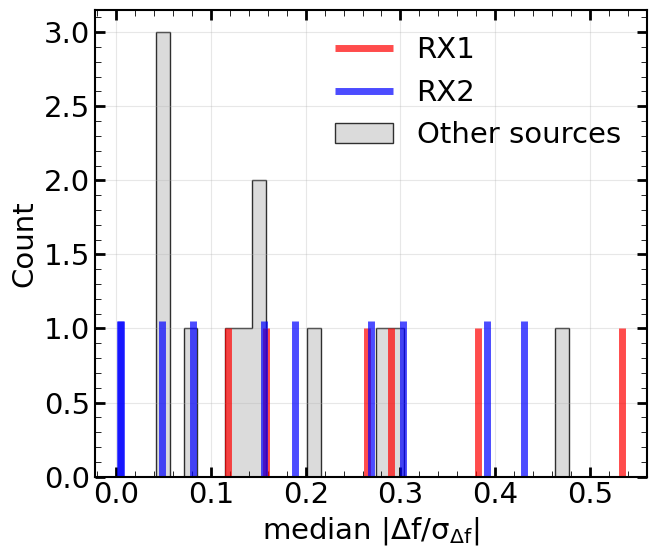

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# ✅ 只画其他源的分布 + 标出光变源
# ----------------------------

var_index = np.where(IDs_image == 9)[0][0]
var_index2 = np.where(IDs_image == 10)[0][0]
snr_other = [deltamag_all[i] for i in range(len(deltamag_all)) if i != var_index and i!=var_index2]  # 其他源
snr_flat = np.concatenate(snr_other)
snr_flat = snr_flat[np.isfinite(snr_flat)]  # 去掉 NaN/inf

snr_var1 = np.array(deltamag_all[var_index])
snr_var1 = snr_var1[np.isfinite(snr_var1)]
snr_var2 = np.array(deltamag_all[var_index2])
snr_var2 = snr_var2[np.isfinite(snr_var2)]
plt.figure(figsize=(7, 6))

# 其他源分布（灰色）

plt.vlines(np.abs(snr_var1), ymin=0, ymax=plt.ylim()[1], color='red', lw=5, alpha=0.7, label='RX1')
plt.vlines(np.abs(snr_var2), ymin=0, ymax=plt.ylim()[1], color='blue', lw=5, alpha=0.7, label='RX2')
plt.hist(np.abs(snr_flat), bins=30, histtype='stepfilled', color='lightgray', edgecolor='k', alpha=0.8, label='Other sources')


# 光变源均值虚线
# plt.axvline(np.abs(np.median(snr_var)), color='red', ls='--', lw=2)

plt.xlabel(r'$\rm median ~ |\Delta f / \sigma_{\Delta f}|$')
plt.ylabel('Count')
# plt.title('Variability S/N distribution (excluding variable image)')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'magnifi_check.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)
# plt.show()

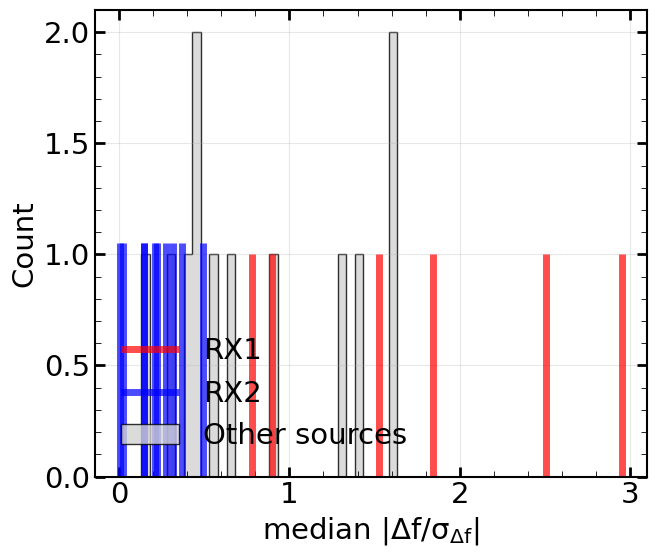

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# ✅ 只画其他源的分布 + 标出光变源
# ----------------------------

# var_index = np.where(IDs_image == 9)[0][0]
# snr_other = [snr_all[i] for i in range(len(snr_all)) if i != var_index]  # 其他源
# snr_flat = np.concatenate(snr_other)
# snr_flat = snr_flat[np.isfinite(snr_flat)]  # 去掉 NaN/inf

# snr_var = np.array(snr_all[var_index])
# snr_var = snr_var[np.isfinite(snr_var)]
var_index = np.where(IDs_image == 9)[0][0]
var_index2 = np.where(IDs_image == 10)[0][0]
snr_other = [snr_all[i] for i in range(len(snr_all)) if i != var_index and i!=var_index2]  # 其他源
snr_flat = np.concatenate(snr_other)
snr_flat = snr_flat[np.isfinite(snr_flat)]  # 去掉 NaN/inf

snr_var1 = np.array(snr_all[var_index])
snr_var1 = snr_var1[np.isfinite(snr_var1)]
snr_var2 = np.array(snr_all[var_index2])
snr_var2 = snr_var2[np.isfinite(snr_var2)]

plt.figure(figsize=(7, 6))

# 其他源分布（灰色）

plt.vlines(np.abs(snr_var1), ymin=0, ymax=plt.ylim()[1], color='red', lw=5, alpha=0.7, label='RX1')
plt.vlines(np.abs(snr_var2), ymin=0, ymax=plt.ylim()[1], color='blue', lw=5, alpha=0.7, label='RX2')
plt.hist(np.abs(snr_flat), bins=30, histtype='stepfilled', color='lightgray', edgecolor='k', alpha=0.8, label='Other sources')


# 光变源均值虚线
# plt.axvline(np.abs(np.median(snr_var)), color='red', ls='--', lw=2)

plt.xlabel(r'$\rm median ~ |\Delta f / \sigma_{\Delta f}|$')
plt.ylabel('Count')
# plt.title('Variability S/N distribution (excluding variable image)')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'magnifi_check.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)
# plt.show()

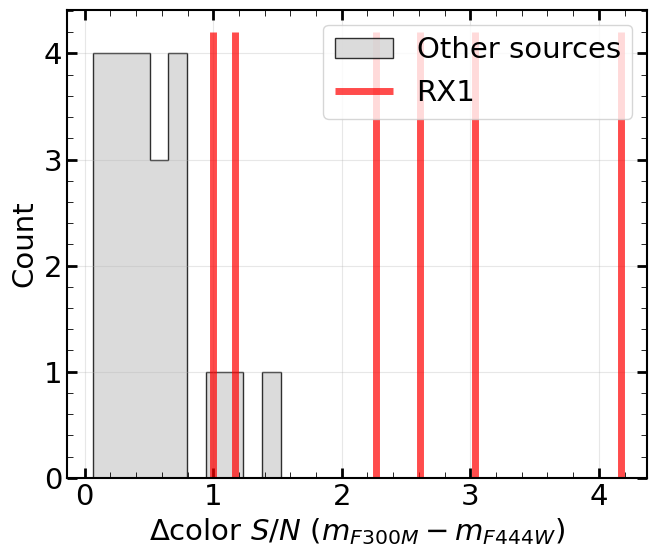

In [63]:
# 你要的颜色组合，例如：
color_pairs = [
    # ('F210M', 'F300M'),
    ('F300M', 'F444W'), 
    # ('F277W', 'F356W'),
]

# ----------------------------------------
# 存储每个 ID 的 Δcolor
# dcolor_all_id[id_index] = list of Δcolor values
# ----------------------------------------
# IDs_image = [9]
dcolor_all_id = [ [] for _ in range(len(final_ID_image)) ]
dcolor_snr_all_id = [ [] for _ in range(len(final_ID_image)) ]
dcolor_all_id = [ [] for _ in range(len(final_ID_image)) ]
dcolor_err_all_id = [ [] for _ in range(len(final_ID_image)) ]
jwstbands = ['F090W', 'F150W', 'F150W2','F200W', 'F210M', 'F277W', 'F300M', 'F356W', 'F410M', 'F444W']
band_to_idx = {b:i for i,b in enumerate(jwstbands)}

for idx_id, ID in enumerate(final_ID_image):
    # if(ID != 35):
    #     continue
    mask = np.array([int(i) == ID for i in sel_image['id_1']])
    sel_tab = sel_image[mask]
    if(ID != 9):
        fluxkey_jwst = [band.upper() + '_KRON'  for band in jwstbands] 
        fluxerr_key_jwst = [band.upper() + '_KRON_e'  for band in jwstbands]
    else:
        fluxkey_jwst = [band.upper() + '_CIRC1'  for band in jwstbands] 
        fluxerr_key_jwst = [band.upper() + '_CIRC1_e'  for band in jwstbands]

    jwstflux_list = []
    jwstfluxerr_list = []

    for col in sel_tab:
        mu = col['mu_best']
        mu16, mu84 = col['mu_16'], col['mu_84']
        mu_err = np.max([mu84 - mu, mu - mu16])

        flux = np.array([col[k] for k in fluxkey_jwst], dtype=float)
        fluxerr = np.array([col[k] for k in fluxerr_key_jwst], dtype=float)

        flux_corr = flux / np.abs(mu)
        fluxerr_corr = fluxerr / np.abs(mu)

        # fluxerr_corr = flux_corr * np.sqrt(
        #     (fluxerr_corr / flux_corr)**2 #+ (mu_err / mu)**2
        # )

        jwstflux_list.append(flux_corr)
        jwstfluxerr_list.append(fluxerr_corr)
    # print(jwstflux_list)
    # print(jwstfluxerr_list)
    jwstflux_arr = np.array(jwstflux_list)
    jwstflux_err = np.array(jwstfluxerr_list)
    
    if len(jwstflux_arr) < 2:
        continue

    # mag
    # mag_arr = -2.5 * np.log10(jwstflux_arr) + 31.4
    # magerr_arr = (2.5/np.log(10)) * (jwstflux_arr / jwstflux_err)
    mag_arr, magerr_arr = nJy_to_ABmag(jwstflux_arr, jwstflux_err)
    # print(mag_arr)
    # print(magerr_arr)
    # Δcolor for each combination of epochs
    for (i, j) in combinations(range(len(mag_arr)), 2):
        mi, mj = mag_arr[i], mag_arr[j]
        mei, mej = magerr_arr[i], magerr_arr[j]
        
        for (b1, b2) in color_pairs:
            idx1, idx2 = band_to_idx[b1], band_to_idx[b2]
            color_i = mi[idx1] - mi[idx2]
            color_j = mj[idx1] - mj[idx2]
            err_i = np.sqrt(mei[idx1]**2 + mei[idx2]**2)
            err_j = np.sqrt(mej[idx1]**2 + mej[idx2]**2)

            dcolor = color_i - color_j
            dcolor_err = np.sqrt(err_i**2 + err_j**2)
            
            # if np.isfinite(dcolor):
            # dcolor_all_id[idx_id].append(dcolor)
            
            # if(ID == 9):
            #     print(dcolor, dcolor_err)

            # if dcolor_err > 0 and np.isfinite(dcolor) and np.isfinite(dcolor_err):
            
            snr = np.array(dcolor / dcolor_err)
            # mask = np.abs(dcolor_err) < 0.3
            mask = (np.abs(dcolor_err) < 0.3)   #(np.abs(snr) > 1) & 
            # print(dcolor)
            if (np.abs(dcolor_err) > 0.3):
                dcolor = 0.02
                # snr = 1
            # dcolor_all_id[idx_id].append(list(np.abs(dcolor[mask])))
            # dcolor_err_all_id[idx_id].append(list(np.abs(dcolor_err[mask])))
            # dcolor_snr_all_id[idx_id].append(list(np.abs(snr[mask])))
            dcolor_all_id[idx_id].append(np.abs(dcolor))
            dcolor_err_all_id[idx_id].append(np.abs(dcolor_err))
            dcolor_snr_all_id[idx_id].append(np.abs(snr))
# =====================================================
# 🌟 出图：光变源作为 outlier（和 SNR 图一样的风格）
# =====================================================

dcolor_var = np.array(dcolor_snr_all_id[var_index])
dcolor_var = dcolor_var[np.isfinite(dcolor_var)]

dcolor_other = [dcolor_snr_all_id[i] for i in range(len(dcolor_snr_all_id)) if i != var_index]
dcolor_flat = np.concatenate(dcolor_other)
# dcolor_flat = np.concatenate([
#     x for sublist in dcolor_other for x in sublist if len(x) > 0
# ])
dcolor_flat = dcolor_flat[np.isfinite(dcolor_flat)]

plt.figure(figsize=(7, 6))
# 其他源（灰色直方图）
# plt.hist(dcolor_all_id, bins=30, histtype='stepfilled',
#          color='lightgray', edgecolor='k', alpha=0.8,
#          label='Other sources')
plt.hist(dcolor_flat, bins=10,
         histtype='stepfilled', color='lightgray',
         edgecolor='k', alpha=0.8, label='Other sources')


# plt.hist(dcolor_snr_all_id, bins=30, histtype='stepfilled',
#          color='lightgray', edgecolor='k', alpha=0.8,
#          label='Other sources')

# 光变源 Δcolor （红线标）
plt.vlines(dcolor_var, ymin=0, ymax=plt.ylim()[1],
           color='red', lw=5, alpha=0.7, label='RX1')

# plt.xlabel(rf'$\Delta{\rm color} = (m_{b1}-m_{b2})_i - (m_{b1}-m_{b2})_j $')
plt.xlabel(
    rf'$\Delta{{\rm color}}~S/N ~(m_{{{b1}}}-m_{{{b2}}})$'
)
plt.ylabel('Count')
plt.legend(frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
band_to_idx

{'F090W': 0,
 'F150W': 1,
 'F150W2': 2,
 'F200W': 3,
 'F210M': 4,
 'F277W': 5,
 'F300M': 6,
 'F356W': 7,
 'F410M': 8,
 'F444W': 9}

In [65]:
# for i in range(len(dcolor_all_id)):
#     print(i, dcolor_all_id[i])
#     print(i, dcolor_err_all_id[i])
for i in range(len(deltamag_all)):
    print(i, IDs_image[i], deltamag_all[i])
    print(i,  IDs_image[i], dcolor_all_id[i])

0 4 [0.20801795141336044, 0.04872254804308085, 0.14574745349375462]
0 4 [0.08418232117847779, 0.07261143967572536, 0.011570881502752428]
1 9 [0.5337714400863511, 0.15850489900688558, 0.2648767328541908, 0.38220028707348774, 0.2899394982819068, 0.1178172229235841]
1 9 [0.20916293957064624, 0.03720499387901555, 0.08667530757465158, 0.1719579456916307, 0.12248763199599466, 0.04947031369563604]
2 10 [0.43044752945829146, 0.26877272307469013, 0.0038762818705890822, 0.15602127121266562, 0.18921591891124478, 0.39114079707125526, 0.30274125657316553, 0.005427721154489973, 0.04804310618358443, 0.08128408830918232]
2 10 [0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.14417248289534967]
3 11 [0.07610015630000788, 0.28704109040769765, 0.47744221955803745]
3 11 [0.2796768869903268, 0.02, 0.02]
4 16 [0.13029960840789911, 0.042253470584320496, 0.3006214064130681]
4 16 [0.02, 0.02, 0.02]
5 28 [0.12011832001156719, 0.0494417792652051, 0.15184972220496817]
5 28 [0.09083805032662084, 0.125729341

In [66]:
var_index

1

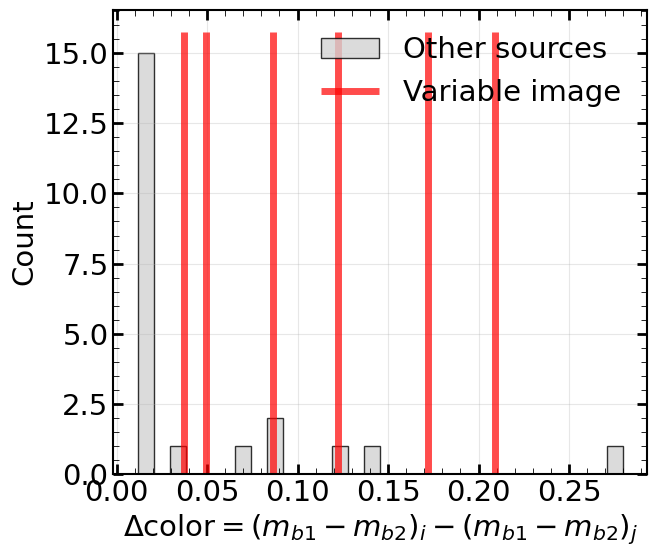

In [67]:

dcolor_var = np.array(dcolor_all_id[var_index])
dcolor_var = dcolor_var[np.isfinite(dcolor_var)]

dcolor_other = [dcolor_all_id[i] for i in range(len(dcolor_all_id)) if i != var_index]

dcolor_flat = np.concatenate(dcolor_other)
# dcolor_flat = np.concatenate([
#     x for sublist in dcolor_other for x in sublist if len(x) > 0
# ])
dcolor_flat = dcolor_flat[np.isfinite(dcolor_flat)]

plt.figure(figsize=(7, 6))
# 其他源（灰色直方图）
# plt.hist(dcolor_all_id, bins=30, histtype='stepfilled',
#          color='lightgray', edgecolor='k', alpha=0.8,
#          label='Other sources')
plt.hist(dcolor_flat, bins=30,
         histtype='stepfilled', color='lightgray',
         edgecolor='k', alpha=0.8, label='Other sources')

# plt.hist(dcolor_snr_all_id, bins=30, histtype='stepfilled',
#          color='lightgray', edgecolor='k', alpha=0.8,
#          label='Other sources')

# 光变源 Δcolor （红线标）
plt.vlines(dcolor_var, ymin=0, ymax=plt.ylim()[1],
           color='red', lw=5, alpha=0.7, label='Variable image')

plt.xlabel(r'$\Delta{\rm color} = (m_{b1}-m_{b2})_i - (m_{b1}-m_{b2})_j $')
plt.ylabel('Count')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
len(snr_all), len(dcolor_snr_all_id), len(IDs_image)

(6, 6, 6)

In [69]:
mag_snr_all_points[mask_var]
# 1 3 ; 3 4

array([2.95142674, 0.89920806, 1.52529549, 2.50438806, 1.84525917,
       0.78010584])

In [70]:
ID = 9
mask = np.array([int(i) == ID for i in sel_image['id_1']])
sel_tab = sel_image[mask]
print(sel_tab)
for (i, j) in combinations(range(4), 2):
    print(i,j)

id_1     ra_1      dec_1    ... N_band_3sig N_band_data      Separation     
                            ...                                arcsec       
---- ----------- ---------- ... ----------- ----------- --------------------
 9.1 332.9538599 -3.8320701 ...          10          10 0.027211102318577284
 9.2   332.92441 -3.8276801 ...          10          10 0.013167197897757001
 9.3   332.94059 -3.8406701 ...          10          10 0.019422671749057287
 9.4 332.9443601 -3.8191101 ...          10          10 0.002290631063068485
0 1
0 2
0 3
1 2
1 3
2 3


0 3 3 3
1 6 6 6
2 10 10 10
3 3 3 3
4 3 3 3
5 3 3 3


/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_20812/3337535204.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


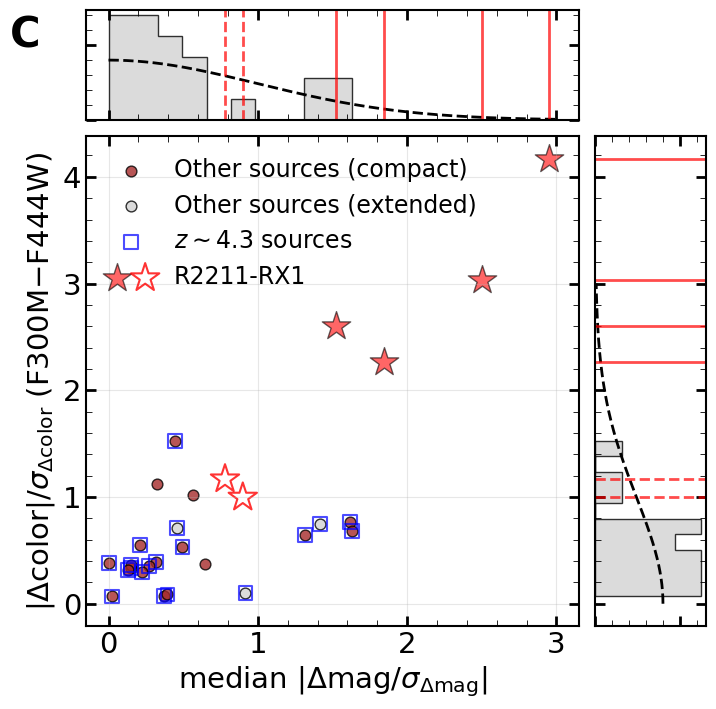

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from matplotlib.legend_handler import HandlerTuple
# ======================================================
# 汇总所有 pair 的 Δmag SNR 与 Δcolor SNR
# ======================================================

mag_snr_all_points = []
color_snr_all_points = []
is_var_flag = []  # True/False per point
cluster_mask = []
is_compact_flag = []
short_t_mask = np.array([False, True, False, False, False, True])
n_ids = min(len(snr_all), len(dcolor_snr_all_id), len(IDs_image))

for i in range(n_ids):
    if(len(snr_all[i]) == 0):
        continue
    snr_mag_i = np.array(snr_all[i], dtype=float)
    snr_color_i = np.array(dcolor_snr_all_id[i], dtype=float)

    snr_mag_i = snr_mag_i#[np.isfinite(snr_mag_i)]
    snr_color_i = snr_color_i#[np.isfinite(snr_color_i)]

    n_pair = min(len(snr_mag_i), len(snr_color_i))
    print(i, n_pair,len(snr_mag_i), len(snr_color_i))

    for k in range(n_pair):
        mag_snr_all_points.append(np.abs(snr_mag_i[k]))
        color_snr_all_points.append(np.abs(snr_color_i[k]))
        is_var_flag.append(i == var_index)
        is_compact_flag.append(i in indices)
        cluster_mask.append(i in cluster_index)

mag_snr_all_points = np.array(mag_snr_all_points)
color_snr_all_points = np.array(color_snr_all_points)
is_var_flag = np.array(is_var_flag)
is_compact_flag = np.array(is_compact_flag)
mask_var = is_var_flag
mask_other = ~is_var_flag
cluster_mask = np.array(cluster_mask)
# ======================================================
# 🎨 图布局：主图 + 上方 hist + 右边 hist
# ======================================================
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(5, 5, figure=fig, hspace=0.15, wspace=0.15)

ax_scatter = fig.add_subplot(gs[1:, :4])   # 中心 scatter
ax_histx   = fig.add_subplot(gs[0, :4], sharex=ax_scatter)  # 顶部 histogram
ax_histy   = fig.add_subplot(gs[1:, 4], sharey=ax_scatter)  # 右侧 histogram

# ======================================================
# 🟦 主散点图
# ======================================================
compact = ax_scatter.scatter(
    mag_snr_all_points[mask_other * is_compact_flag],
    color_snr_all_points[mask_other * is_compact_flag],
    s=60, alpha=0.8, facecolor='brown', edgecolor='k',
    label="Other sources (compact)"
)

extended = ax_scatter.scatter(
    mag_snr_all_points[mask_other * ~is_compact_flag],
    color_snr_all_points[mask_other * ~is_compact_flag],
    s=60, alpha=0.8, facecolor='lightgray', edgecolor='k',
    label="Other sources (extended)"
)

RX1_1 = ax_scatter.scatter(
    mag_snr_all_points[mask_var][~short_t_mask],
    color_snr_all_points[mask_var][~short_t_mask], marker = '*',
    s = 460, alpha=0.6, color='red', edgecolor='k',
    label="R2211-RX1"
)
RX1_2 = ax_scatter.scatter(
    mag_snr_all_points[mask_var][short_t_mask],
    color_snr_all_points[mask_var][short_t_mask],
    marker='*',
    s = 460, alpha=0.8, facecolors='none', edgecolor='red',lw = 1.5
   # label=r"$z\sim 4.3$ sources"
)



z43 = ax_scatter.scatter(
    mag_snr_all_points[mask_other *cluster_mask],
    color_snr_all_points[mask_other *cluster_mask],
    marker='s',
    s=100, alpha=0.7,
    facecolors='none',      # ✅ 变空心
    edgecolor='blue',       # ✅ 方框边框颜色
    linewidth=1.5,          # 可选: 轮廓粗细
    label=r"$z\sim 4.3$ sources"
)
b2 = color_pairs[0][1]

# 从 color_pairs 获取颜色组合名

ax_scatter.grid(alpha=0.3)
# ax_scatter.legend(fontsize = 17, frameon = False)
ax_scatter.legend(
    [  compact, extended,  z43 , (RX1_1, RX1_2)],
    [ "Other sources (compact)","Other sources (extended)",r"$z\sim 4.3$ sources","R2211-RX1"],
    handler_map={tuple: HandlerTuple(ndivide=None)},  # 关键一步：组合对象共享 legend
    fontsize=17,
    frameon=False
)

# ======================================================
# 🔼 顶部直方图（x 分布）
# ======================================================
bins_x = 10

# 其他源 histogram
_ = ax_histx.hist(
    mag_snr_all_points[mask_other],
    bins=bins_x,
    histtype='stepfilled',
    color='lightgray',
    edgecolor='k',
    alpha=0.8,
    density = True
)
x = np.linspace(0, 3, 200)
ax_histx.plot(x, norm.pdf(x, 0, 1)*2,  'k--', lw=2)

# 光变源 — 竖线
for v in mag_snr_all_points[mask_var][~short_t_mask]:
    ax_histx.axvline(v, color='red', lw=2, alpha=0.7)
for v in mag_snr_all_points[mask_var][short_t_mask]:
    ax_histx.axvline(v, color='red', lw=2, alpha=0.7,linestyle = '--')


# ax_histx.set_ylabel("Count")
ax_histx.tick_params(labelbottom=False)


# ======================================================
# ▶️ 右侧直方图（y 分布）
# ======================================================
bins_y = 10

# 其他源 histogram
ax_histy.hist(
    color_snr_all_points[mask_other],
    bins=bins_y,
    orientation='horizontal',
    histtype='stepfilled',
    color='lightgray',
    edgecolor='k',
    alpha=0.8,
    density = True
)

x = np.linspace(0, 3, 200)
ax_histy.plot( norm.pdf(x, 0, 1)*2, x, 'k--', lw=2)

# 光变源竖线（但横向）
for v in color_snr_all_points[mask_var][~short_t_mask]:
    ax_histy.axhline(v, color='red', lw=2, alpha=0.7)
for v in color_snr_all_points[mask_var][short_t_mask]:
    ax_histy.axhline(v, color='red', lw=2, alpha=0.7,linestyle = '--')

ax_scatter.set_xlabel("median " + r"$|\Delta {\rm mag} / \sigma_{\Delta {\rm mag}}|$")
ax_scatter.set_ylabel(r"$|\Delta{\rm color}| / \sigma_{\Delta{\rm color}}$ "  + fr"({b1}$-${b2})")
# ax_histy.set_xlabel("Count")
ax_histy.tick_params(labelleft=False)
# x = np.linspace(0, 5, 200)
# ax_histy.plot(x, norm.pdf(x, 0, 1), lw=2)
# 隐藏顶部轴 ticks & labels
ax_histx.tick_params(axis='y', which='both',  labelleft=False)
ax_histy.tick_params(axis='x', which='both', labelbottom=False)
ax_histx.text(-0.66, 1.4, 'C', color='k', fontsize=30, ha='left', va='top', weight='bold')

plt.tight_layout()
# plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'magnifi_check2.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)
# plt.show()

0 3 3 3
1 6 6 6
2 10 10 10
3 3 3 3
4 3 3 3
5 3 3 3


/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_20812/3911049850.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


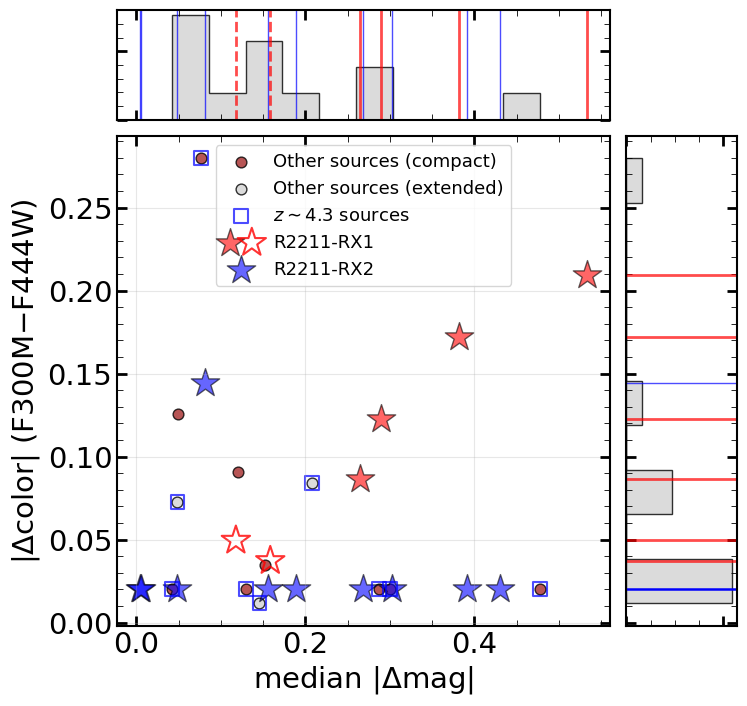

In [72]:

mag_snr_all_points = []
color_snr_all_points = []
is_var_flag = []  # True/False per point
is_var_flag2 = []  # True/False per point
cluster_mask = []
is_compact_flag = []
short_t_mask = np.array([False, True, False, False, False, True])
n_ids = min(len(snr_all), len(dcolor_snr_all_id), len(IDs_image))

for i in range(n_ids):
    if(len(snr_all[i]) == 0):
        continue
    snr_mag_i = np.array(deltamag_all[i], dtype=float)
    snr_color_i = np.array(dcolor_all_id[i], dtype=float)

    snr_mag_i = snr_mag_i#[np.isfinite(snr_mag_i)]
    snr_color_i = snr_color_i#[np.isfinite(snr_color_i)]

    n_pair = min(len(snr_mag_i), len(snr_color_i))
    print(i, n_pair,len(snr_mag_i), len(snr_color_i))

    for k in range(n_pair):
        mag_snr_all_points.append(np.abs(snr_mag_i[k]))
        color_snr_all_points.append(np.abs(snr_color_i[k]))
        is_var_flag.append(i == var_index)
        is_var_flag2.append(i == var_index2)
        is_compact_flag.append(i in indices)
        cluster_mask.append(i in cluster_index)

mag_snr_all_points = np.array(mag_snr_all_points)
color_snr_all_points = np.array(color_snr_all_points)
is_var_flag = np.array(is_var_flag)
is_var_flag2 = np.array(is_var_flag2)
is_compact_flag = np.array(is_compact_flag)
mask_var = is_var_flag
mask_var2 = is_var_flag2
mask_other = (~is_var_flag)*(~is_var_flag2)
cluster_mask = np.array(cluster_mask)
# ======================================================
# 🎨 图布局：主图 + 上方 hist + 右边 hist
# ======================================================
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(5, 5, figure=fig, hspace=0.15, wspace=0.15)

ax_scatter = fig.add_subplot(gs[1:, :4])   # 中心 scatter
ax_histx   = fig.add_subplot(gs[0, :4], sharex=ax_scatter)  # 顶部 histogram
ax_histy   = fig.add_subplot(gs[1:, 4], sharey=ax_scatter)  # 右侧 histogram

# ======================================================
# 🟦 主散点图
# ======================================================
compact = ax_scatter.scatter(
    mag_snr_all_points[mask_other * is_compact_flag],
    color_snr_all_points[mask_other * is_compact_flag],
    s=60, alpha=0.8, facecolor='brown', edgecolor='k',
    label="Other sources (compact)"
)

extended = ax_scatter.scatter(
    mag_snr_all_points[mask_other * ~is_compact_flag],
    color_snr_all_points[mask_other * ~is_compact_flag],
    s=60, alpha=0.8, facecolor='lightgray', edgecolor='k',
    label="Other sources (extended)"
)

RX1_1 = ax_scatter.scatter(
    mag_snr_all_points[mask_var][~short_t_mask],
    color_snr_all_points[mask_var][~short_t_mask], marker = '*',
    s = 460, alpha=0.6, color='red', edgecolor='k',
    label="R2211-RX1"
)
RX1_2 = ax_scatter.scatter(
    mag_snr_all_points[mask_var][short_t_mask],
    color_snr_all_points[mask_var][short_t_mask],
    marker='*',
    s = 460, alpha=0.8, facecolors='none', edgecolor='red',lw = 1.5
   # label=r"$z\sim 4.3$ sources"
)
RX2_1 = ax_scatter.scatter(
    mag_snr_all_points[mask_var2],
    color_snr_all_points[mask_var2],
    marker='*',
    s=460, alpha=0.6, color='blue', edgecolor='k',
    label="R2211-RX2"
)



z43 = ax_scatter.scatter(
    mag_snr_all_points[mask_other *cluster_mask],
    color_snr_all_points[mask_other *cluster_mask],
    marker='s',
    s=100, alpha=0.7,
    facecolors='none',      # ✅ 变空心
    edgecolor='blue',       # ✅ 方框边框颜色
    linewidth=1.5,          # 可选: 轮廓粗细
    label=r"$z\sim 4.3$ sources"
)
b2 = color_pairs[0][1]
ax_scatter.set_xlabel("median " + r"$|\Delta {\rm mag}|$")
ax_scatter.set_ylabel(r"$|\Delta{\rm color}|$ "  + fr"({b1}$-${b2})")
# 从 color_pairs 获取颜色组合名

ax_scatter.grid(alpha=0.3)
# ax_scatter.legend(fontsize = 17, frameon = False)
# ax_scatter.legend(
#     [  compact, extended,  z43 , (RX1_1, RX1_2)],
#     [ "Other sources (compact)","Other sources (extended)",r"$z\sim 4.3$ sources","R2211-RX1"],
#     handler_map={tuple: HandlerTuple(ndivide=None)},  # 关键一步：组合对象共享 legend
#     fontsize=17,
#     frameon=False
# )
ax_scatter.legend(
    [compact, extended, z43, (RX1_1, RX1_2), (RX2_1)],
    ["Other sources (compact)", "Other sources (extended)",
     r"$z\sim 4.3$ sources", "R2211-RX1", "R2211-RX2"],
    handler_map={tuple: HandlerTuple(ndivide=None)},
    fontsize=13,
    frameon=True
)

# ======================================================
# 🔼 顶部直方图（x 分布）
# ======================================================
bins_x = 10

# 其他源 histogram
_ = ax_histx.hist(
    mag_snr_all_points[mask_other],
    bins=bins_x,
    histtype='stepfilled',
    color='lightgray',
    edgecolor='k',
    alpha=0.8,
    density = True
)
# x = np.linspace(0, 3, 200)
# ax_histx.plot(x, norm.pdf(x, 0, 1)*2,  'k--', lw=2)

# RX2
for v in mag_snr_all_points[mask_var2]:
    ax_histx.axvline(v, color='blue', lw=1, alpha=0.7)
# 光变源 — 竖线
for v in mag_snr_all_points[mask_var][~short_t_mask]:
    ax_histx.axvline(v, color='red', lw=2, alpha=0.7)
for v in mag_snr_all_points[mask_var][short_t_mask]:
    ax_histx.axvline(v, color='red', lw=2, alpha=0.7,linestyle = '--')


# ax_histx.set_ylabel("Count")
ax_histx.tick_params(labelbottom=False)


# ======================================================
# ▶️ 右侧直方图（y 分布）
# ======================================================
bins_y = 10

# 其他源 histogram
ax_histy.hist(
    color_snr_all_points[mask_other],
    bins=bins_y,
    orientation='horizontal',
    histtype='stepfilled',
    color='lightgray',
    edgecolor='k',
    alpha=0.8,
    density = True
)

# x = np.linspace(0, 3, 200)
# ax_histy.plot( norm.pdf(x, 0, 1)*2, x, 'k--', lw=2)

# 光变源竖线（但横向）
for v in color_snr_all_points[mask_var]:
    ax_histy.axhline(v, color='red', lw=2, alpha=0.7)
# for v in color_snr_all_points[mask_var][short_t_mask]:
#     ax_histy.axhline(v, color='red', lw=2, alpha=0.7,linestyle = '--')
# RX2
for v in color_snr_all_points[mask_var2]:
    ax_histy.axhline(v, color='blue', lw=1, alpha=0.7)
# for v in color_snr_all_points[mask_var2][short_t_mask]:
#     ax_histy.axhline(v, color='blue', lw=2, alpha=0.7, linestyle='--')

# ax_histy.set_xlabel("Count")
ax_histy.tick_params(labelleft=False)
# x = np.linspace(0, 5, 200)
# ax_histy.plot(x, norm.pdf(x, 0, 1), lw=2)
# 隐藏顶部轴 ticks & labels
ax_histx.tick_params(axis='y', which='both',  labelleft=False)
ax_histy.tick_params(axis='x', which='both', labelbottom=False)
# ax_histx.text(-0.66, 1.4, 'C', color='k', fontsize=30, ha='left', va='top', weight='bold')

plt.tight_layout()
# plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'magnifi_check2.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)
# plt.show()


/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_20812/1135667432.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


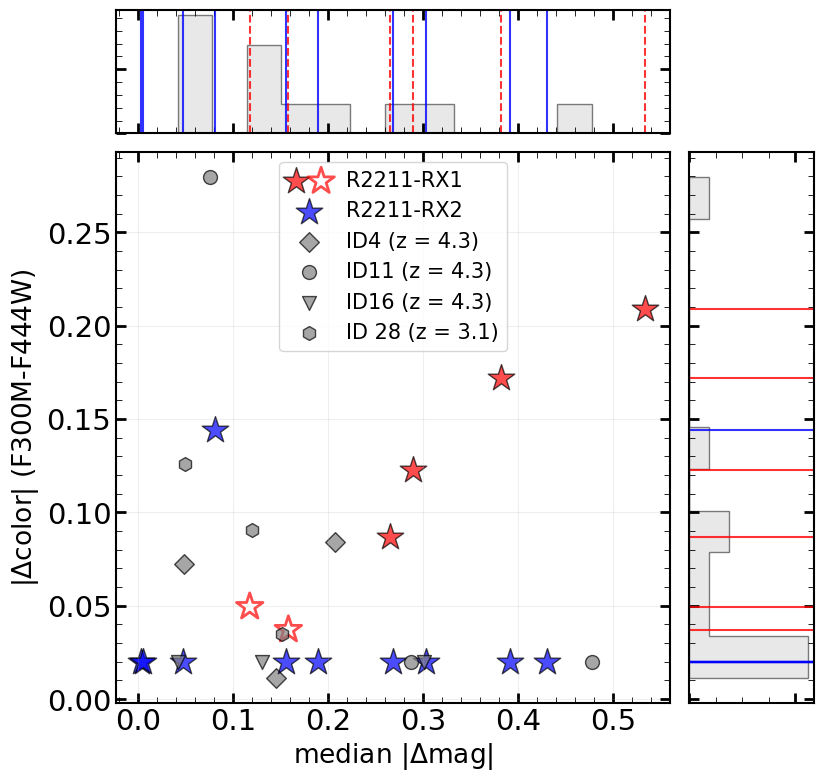

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.legend_handler import HandlerTuple

# ======================================================
# 核心设置：定义那6个特殊的源
# ======================================================
# 索引列表: [4, 9, 10, 11, 16, 28]
# 9=RX1, 10=RX2
special_ids = [4, 9, 10,  11, 16, 28]
# 为每个ID分配颜色和形状 (RX1=red, RX2=blue, 其他自定义)
id_configs = {
    9:  {'color': 'red',     'marker': '*', 'label': 'R2211-RX1'}, 
    10: {'color': 'blue',    'marker': '*', 'label': 'R2211-RX2'},
    4:  {'color': 'gray',   'marker': 'D', 'label': 'ID4 (z = 4.3)'},   # 五角形
    11: {'color': 'gray',  'marker': 'o', 'label': 'ID11 (z = 4.3)'},  # 菱形
    16: {'color': 'gray', 'marker': 'v', 'label': 'ID16 (z = 4.3)'},  # 倒三角
    28: {'color': 'gray',    'marker': 'h', 'label': 'ID 28 (z = 3.1)'}   # 六角形
}

# 预处理 mask
mag_snr_all_points = np.array(mag_snr_all_points)
color_snr_all_points = np.array(color_snr_all_points)
is_compact_flag = np.array(is_compact_flag)
cluster_mask = np.array(cluster_mask)

# 背景源的 mask：不在那6个特殊ID里的点
mask_special_all = np.zeros(len(mag_snr_all_points), dtype=bool)
# 这里需要注意：之前的逻辑里 is_var_flag 是基于循环中的 i 判定的
# 我们直接构建一个 boolean mask 来排除这 6 个源
# 假设 mag_snr_all_points 的生成顺序与原始循环 i 一致
source_id_per_point = []
for i in range(n_ids):
    if(len(snr_all[i]) == 0): continue
    n_pair = min(len(np.array(deltamag_all[i])), len(np.array(dcolor_all_id[i])))
    for k in range(n_pair):
        source_id_per_point.append(special_ids[i])
source_id_per_point = np.array(source_id_per_point)

mask_background = ~np.isin(source_id_per_point, [9, 10])

# ======================================================
# 🎨 图布局
# ======================================================
fig = plt.figure(figsize=(9, 9))
gs = GridSpec(5, 5, figure=fig, hspace=0.15, wspace=0.15)

ax_scatter = fig.add_subplot(gs[1:, :4]) 
ax_histx   = fig.add_subplot(gs[0, :4], sharex=ax_scatter)
ax_histy   = fig.add_subplot(gs[1:, 4], sharey=ax_scatter)

# ======================================================
# 🟦 背景散点图 (Other sources)
# ======================================================
# compact = ax_scatter.scatter(
#     mag_snr_all_points[mask_background * is_compact_flag],
#     color_snr_all_points[mask_background * is_compact_flag],
#     s=50, alpha=0.5, facecolor='brown', edgecolor='none',
#     label="Other sources (compact)"
# )

# extended = ax_scatter.scatter(
#     mag_snr_all_points[mask_background * ~is_compact_flag],
#     color_snr_all_points[mask_background * ~is_compact_flag],
#     s=50, alpha=0.3, facecolor='lightgray', edgecolor='none',
#     label="Other sources (extended)"
# )

# z43 = ax_scatter.scatter(
#     mag_snr_all_points[mask_background * cluster_mask],
#     color_snr_all_points[mask_background * cluster_mask],
#     marker='s', s=180, alpha=0.6, facecolors='none', edgecolor='blue', 
#     linewidth=1.2, label=r"$z\sim 4.3$ sources"
# )

# ======================================================
# ⭐ 绘制 6 个特殊源
# ======================================================
special_handles = []
special_labels = []

for sid in special_ids:
    mask_sid = (source_id_per_point == sid)
    cfg = id_configs[sid]
    if(sid in [9, 10]):
        size = 400
    else:
        size = 100
    if sid == 9: # RX1 特殊处理 short_t_mask
        h1 = ax_scatter.scatter(
            mag_snr_all_points[mask_sid][~short_t_mask],
            color_snr_all_points[mask_sid][~short_t_mask],
            marker=cfg['marker'], s=size, alpha=0.7, color=cfg['color'], edgecolor='k'
        )
        h2 = ax_scatter.scatter(
            mag_snr_all_points[mask_sid][short_t_mask],
            color_snr_all_points[mask_sid][short_t_mask],
            marker=cfg['marker'], s=size, alpha=0.7, facecolors='none', 
            edgecolor=cfg['color'], lw=2
        )
        special_handles.append((h1, h2))
        special_labels.append(cfg['label'])
    else:
        h = ax_scatter.scatter(
            mag_snr_all_points[mask_sid],
            color_snr_all_points[mask_sid],
            marker=cfg['marker'], s=size, alpha=0.7, color=cfg['color'], 
            edgecolor='k', label=cfg['label']
        )
        special_handles.append(h)
        special_labels.append(cfg['label'])

# ======================================================
# 🔼 顶部 & 右侧直方图 (保持现状)
# ======================================================
bins_x = 12
ax_histx.hist(mag_snr_all_points[mask_background], bins=bins_x, histtype='stepfilled',
              color='lightgray', edgecolor='k', alpha=0.5, density=True)

ax_histy.hist(color_snr_all_points[mask_background], bins=12, orientation='horizontal',
              histtype='stepfilled', color='lightgray', edgecolor='k', alpha=0.5, density=True)

# 在直方图里画那6个源的指示线
for sid in [9, 10]:
    mask_sid = (source_id_per_point == sid)
    color = id_configs[sid]['color']
    # X轴线
    for v in mag_snr_all_points[mask_sid]:
        ls = '--' if (sid == 9 and short_t_mask[np.where(mask_sid)[0].tolist().index(np.where(mag_snr_all_points==v)[0][0]) if v in mag_snr_all_points[mask_sid] else 0]) else '-'
        # 简化处理：RX1用虚线区分，其他实线
        ax_histx.axvline(v, color=color, lw=1.5, alpha=0.8, linestyle='--' if sid==9 else '-')
    # Y轴线
    for v in color_snr_all_points[mask_sid]:
        ax_histy.axhline(v, color=color, lw=1.5, alpha=0.8)

# ======================================================
# 装饰与图例
# ======================================================

ax_scatter.grid(alpha=0.2)

special_handles.insert(2, special_handles.pop(0))
special_labels.insert(2, special_labels.pop(0))
# 合并图例
# all_handles = [compact, extended, z43] + special_handles
# all_labels = ["Other (compact)", "Other (extended)", r"$z\sim 4.3$ sources"] + special_labels
all_handles = special_handles
all_labels =  special_labels

ax_scatter.legend(
    all_handles, all_labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    fontsize=15, frameon=True, loc=0, ncols = 1
)
ax_scatter.set_xlabel("median " + r"$|\Delta {\rm mag}|$", fontsize=19)
ax_scatter.set_ylabel(r"$|\Delta{\rm color}|$ " + f"({b1}-{b2})", fontsize=19)
ax_histx.tick_params(labelbottom=False, labelleft=False)
ax_histy.tick_params(labelleft=False, labelbottom=False)

plt.tight_layout()
plt.show()

0 3 3 3
1 6 6 6
2 10 10 10
3 3 3 3
4 3 3 3
5 3 3 3


/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_20812/2605964519.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


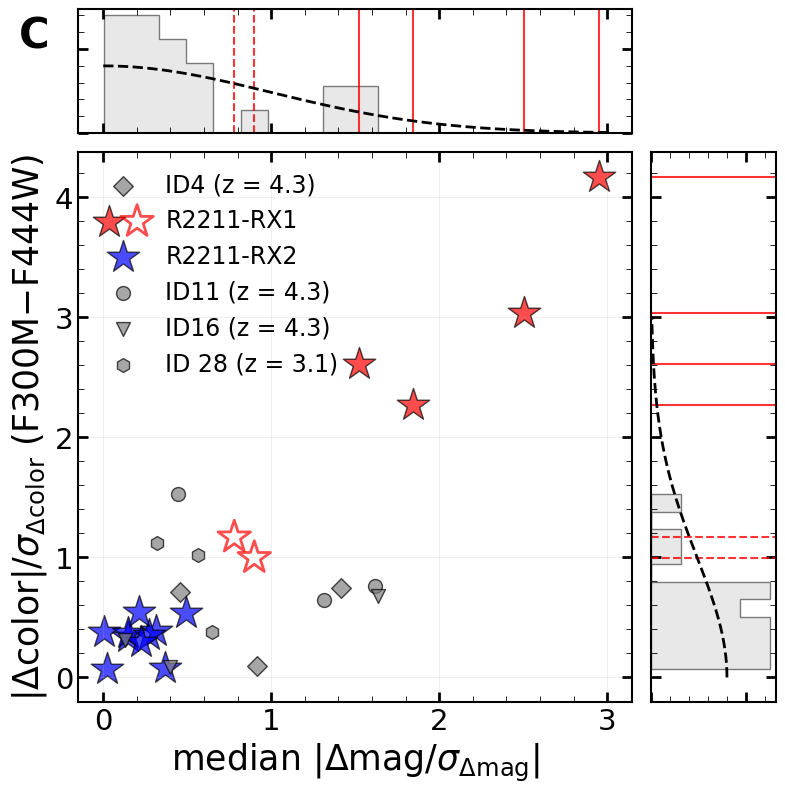

In [104]:



mag_snr_all_points = []
color_snr_all_points = []
for i in range(n_ids):
    if(len(snr_all[i]) == 0):
        continue
    snr_mag_i = np.array(snr_all[i], dtype=float)
    snr_color_i = np.array(dcolor_snr_all_id[i], dtype=float)

    snr_mag_i = snr_mag_i#[np.isfinite(snr_mag_i)]
    snr_color_i = snr_color_i#[np.isfinite(snr_color_i)]

    n_pair = min(len(snr_mag_i), len(snr_color_i))
    print(i, n_pair,len(snr_mag_i), len(snr_color_i))

    for k in range(n_pair):
        mag_snr_all_points.append(np.abs(snr_mag_i[k]))
        color_snr_all_points.append(np.abs(snr_color_i[k]))
        # is_var_flag.append(i == var_index)
        # is_compact_flag.append(i in indices)
        # cluster_mask.append(i in cluster_index)

mag_snr_all_points = np.array(mag_snr_all_points)
color_snr_all_points = np.array(color_snr_all_points)
mask_background = ~np.isin(source_id_per_point, [9, 10])
mask_background2 = ~np.isin(source_id_per_point, [9])
# ======================================================
# 🎨 图布局
# ======================================================
fig = plt.figure(figsize=(9, 9))
gs = GridSpec(5, 5, figure=fig, hspace=0.15, wspace=0.15)

ax_scatter = fig.add_subplot(gs[1:, :4]) 
ax_histx   = fig.add_subplot(gs[0, :4], sharex=ax_scatter)
ax_histy   = fig.add_subplot(gs[1:, 4], sharey=ax_scatter)

# ======================================================
# ⭐ 绘制 6 个特殊源
# ======================================================
special_handles = []
special_labels = []
size = 5
for sid in special_ids:
    mask_sid = (source_id_per_point == sid)
    cfg = id_configs[sid]
    if(sid in [9, 10]):
        size = 600
    else:
        size = 100
    if sid == 9: # RX1 特殊处理 short_t_mask
        h1 = ax_scatter.scatter(
            mag_snr_all_points[mask_sid][~short_t_mask],
            color_snr_all_points[mask_sid][~short_t_mask],
            marker=cfg['marker'], s=size, alpha=0.7, color=cfg['color'], edgecolor='k'
        )
        h2 = ax_scatter.scatter(
            mag_snr_all_points[mask_sid][short_t_mask],
            color_snr_all_points[mask_sid][short_t_mask],
            marker=cfg['marker'], s=size, alpha=0.7, facecolors='none', 
            edgecolor=cfg['color'], lw=2
        )
        special_handles.append((h1, h2))
        special_labels.append(cfg['label'])
    else:
        h = ax_scatter.scatter(
            mag_snr_all_points[mask_sid],
            color_snr_all_points[mask_sid],
            marker=cfg['marker'], s=size, alpha=0.7, color=cfg['color'], 
            edgecolor='k', label=cfg['label']
        )
        special_handles.append(h)
        special_labels.append(cfg['label'])

# ======================================================
# 🔼 顶部 & 右侧直方图 (保持现状)
# ======================================================
bins_x = 10
ax_histx.hist(mag_snr_all_points[mask_background2], bins=bins_x, histtype='stepfilled',
              color='lightgray', edgecolor='k', alpha=0.5, density=True)

ax_histy.hist(color_snr_all_points[mask_background2], bins=bins_x, orientation='horizontal',
              histtype='stepfilled', color='lightgray', edgecolor='k', alpha=0.5, density=True)

# 在直方图里画那6个源的指示线
for sid in [9]:
    mask_sid = (source_id_per_point == sid)
    color = id_configs[sid]['color']
    # X轴线
    for v in mag_snr_all_points[mask_sid][~short_t_mask]:
        ax_histx.axvline(v, color=color, lw=1.5, alpha=0.8, linestyle='-')
    for v in color_snr_all_points[mask_sid][~short_t_mask]:
        ax_histy.axhline(v, color=color, lw=1.5, alpha=0.8, linestyle='-')
    # Y轴线
    for v in mag_snr_all_points[mask_sid][short_t_mask]:
        ax_histx.axvline(v, color=color, lw=1.5, alpha=0.8, linestyle='--')
    for v in color_snr_all_points[mask_sid][short_t_mask]:    
        ax_histy.axhline(v, color=color, lw=1.5, alpha=0.8, linestyle='--')

# ======================================================
# 装饰与图例
# ======================================================


ax_scatter.set_xlabel("median " + r"$|\Delta {\rm mag} / \sigma_{\Delta {\rm mag}}|$", fontsize=19)
ax_scatter.set_ylabel(r"$|\Delta{\rm color}| / \sigma_{\Delta{\rm color}}$ " + f"({b1}-{b2})", fontsize=19)
ax_scatter.grid(alpha=0.2)

# 合并图例
# all_handles = [compact, extended, z43] + special_handles
# all_labels = ["Other (compact)", "Other (extended)", r"$z\sim 4.3$ sources"] + special_labels
all_handles = special_handles
all_labels =  special_labels

ax_scatter.legend(
    all_handles, all_labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    fontsize=17,  frameon=False, loc=0, ncols = 1
)

ax_histx.tick_params(labelbottom=False, labelleft=False)
ax_histy.tick_params(labelleft=False, labelbottom=False)
x = np.linspace(0, 3, 200)
ax_histx.plot(x,  norm.pdf(x, 0, 1)*2, 'k--', lw=2)
x = np.linspace(0, 3, 200)
ax_histy.plot( norm.pdf(x, 0, 1)*2, x, 'k--', lw=2)

ax_scatter.set_xlabel("median " + r"$|\Delta {\rm mag} / \sigma_{\Delta {\rm mag}}|$", fontsize = 25)
ax_scatter.set_ylabel(r"$|\Delta{\rm color}| / \sigma_{\Delta{\rm color}}$ "  + fr"({b1}$-${b2})", fontsize = 25)
# ax_histy.set_xlabel("Count")
ax_histy.tick_params(labelleft=False)
# x = np.linspace(0, 5, 200)
# ax_histy.plot(x, norm.pdf(x, 0, 1), lw=2)
# 隐藏顶部轴 ticks & labels
ax_histx.tick_params(axis='y', which='both',  labelleft=False)
ax_histy.tick_params(axis='x', which='both', labelbottom=False)
ax_histx.text(-0.5, 1.4, 'C', color='k', fontsize=30, ha='left', va='top', weight='bold')

plt.tight_layout()
plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'magnifi_check_260418.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)
# plt.show()

/Users/zijianzhang/miniconda3/envs/msaexp39/lib/python3.9/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


(array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]),
 array([0.        , 0.08333333, 0.16666667, 0.25      , 0.33333333,
        0.41666667, 0.5       , 0.58333333, 0.66666667, 0.75      ,
        0.83333333, 0.91666667, 1.        ]),
 [<matplotlib.patches.Polygon at 0x3a5b34d30>])

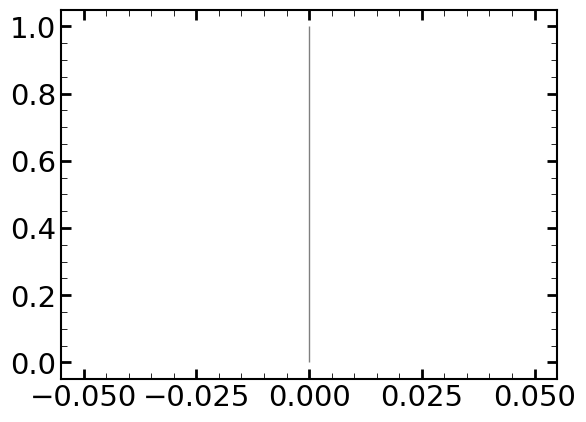

In [385]:
plt.hist(color_snr_all_points[mask_background], bins=12, orientation='horizontal',
              histtype='stepfilled', color='lightgray', edgecolor='k', alpha=0.5, density=True)

In [382]:
mask_sid

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False])

In [375]:
mag_snr_all_points[mask_rx1]

array([], dtype=float64)

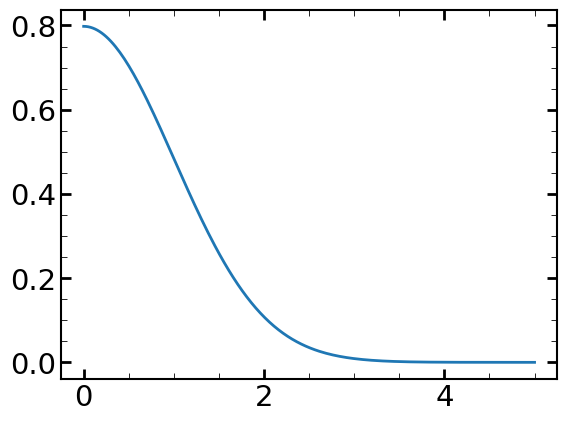

In [173]:
plt.plot(x, norm.pdf(x, 0, 1)*2, lw=2)

In [175]:
np.sum(norm.pdf(x, 0, 1)*2*(x[1] - x[0]))

1.010023138656635

In [176]:
np.sum(_[0]*(_[1][1] - _[1][0])) 

1.0000000000000002

In [42]:
max(_[0])

2.2935796816413063

In [22]:
dmag_snr_per_id

NameError: name 'dmag_snr_per_id' is not defined

0.7076346933639464 0.38289496621280095
0.6468213984624711 0.3771582922323636
0.07572495096587772 0.3769994318724107
-0.060813294901475246 0.38783192514836917
-0.6319097423980686 0.38767743859654474
-0.5710964474965934 0.382012589642421


/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_1295/2870592249.py:62: RuntimeWarning: invalid value encountered in log10
  mag_arr = -2.5 * np.log10(flux_arr) + 31.4


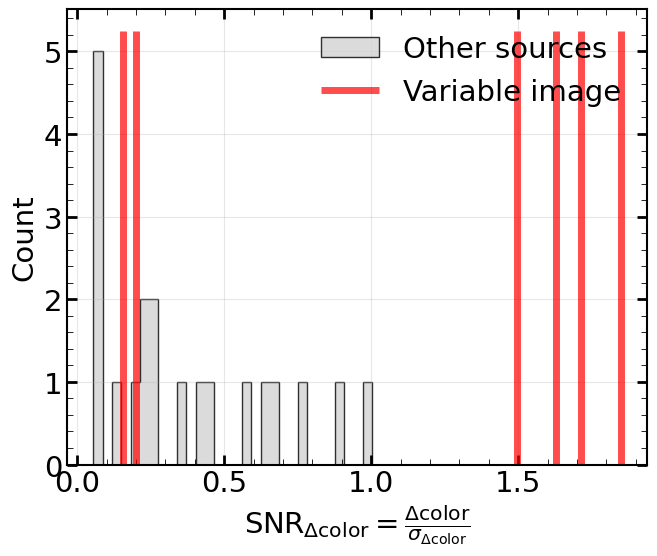

In [719]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# 你想检查的 color
color_pairs = [
    ('F210M', 'F300M'),
]

jwstbands = ['F090W','F150W', 'F200W', 'F210M', 'F277W', 'F300M', 'F356W', 'F410M', 'F444W']
band_to_idx = {b:i for i,b in enumerate(jwstbands)}

# ===========================================================
# 🌟 存储每个 ID 的 color variability SNR
#   dcolor_snr_all_id[id_index] = list of SNR for every epoch pair
# ===========================================================
dcolor_snr_all_id = [ [] for _ in range(len(IDs_image)) ]


# ===========================================================
# 🌟 主循环：计算每个 ID 的 Δcolor SNR
# ===========================================================
for idx_id, ID in enumerate(IDs_image):

    mask = np.array([int(i) == ID for i in sel_image['id_1']])
    sel_tab = sel_image[mask]

    fluxkey_jwst = [b + '_KRON' for b in jwstbands]
    fluxerr_key_jwst = [b + '_KRON_e' for b in jwstbands]

    flux_list = []
    fluxerr_list = []

    # 获取每个 epoch 的 flux 和误差
    for col in sel_tab:

        mu = col['mu_best']
        mu16, mu84 = col['mu_16'], col['mu_84']
        mu_err = np.max([mu84 - mu, mu - mu16])

        f  = np.array([col[k] for k in fluxkey_jwst], dtype=float)
        fe = np.array([col[k] for k in fluxerr_key_jwst], dtype=float)

        # μ correction
        f_corr = f / np.abs(mu)
        fe_corr = fe / np.abs(mu)

        fe_corr = f_corr * np.sqrt(
            (fe_corr / f_corr)**2 + (mu_err/mu)**2
        )

        flux_list.append(f_corr)
        fluxerr_list.append(fe_corr)

    flux_arr = np.array(flux_list)
    fluxerr_arr = np.array(fluxerr_list)

    if len(flux_arr) < 2:
        continue

    # 把 flux → mag
    mag_arr = -2.5 * np.log10(flux_arr) + 31.4
    magerr_arr = (2.5/np.log(10)) * (fluxerr_arr / flux_arr)

    # =======================================================
    # 计算 Δcolor SNR
    # =======================================================
    for (i, j) in combinations(range(len(mag_arr)), 2):
        mi, mj = mag_arr[i], mag_arr[j]
        mei, mej = magerr_arr[i], magerr_arr[j]

        for (b1, b2) in color_pairs:
            k1, k2 = band_to_idx[b1], band_to_idx[b2]

            color_i = mi[k1] - mi[k2]
            color_j = mj[k1] - mj[k2]
            # 颜色误差
            err_i = np.sqrt(mei[k1]**2 + mei[k2]**2)
            err_j = np.sqrt(mej[k1]**2 + mej[k2]**2)

            # Δcolor
            dcolor = color_i - color_j
            # Δcolor 误差
            dcolor_err = np.sqrt(err_i**2 + err_j**2)
            if(ID == 9):
                print(dcolor, dcolor_err)

            if dcolor_err > 0 and np.isfinite(dcolor) and np.isfinite(dcolor_err):
                snr = dcolor / dcolor_err
                dcolor_snr_all_id[idx_id].append(snr)



# ===========================================================
# 🌟 出图（完全 mimic 你 SNR 那张图）
# ===========================================================
var_index = 1  # 光变源

snr_var = np.array(dcolor_snr_all_id[var_index])
snr_var = snr_var[np.isfinite(snr_var)]

snr_other = [dcolor_snr_all_id[i] for i in range(len(dcolor_snr_all_id)) if i != var_index]
snr_flat = np.concatenate(snr_other)
snr_flat = snr_flat[np.isfinite(snr_flat)]

plt.figure(figsize=(7,6))

# Other sources: gray histogram
plt.hist(np.abs(snr_flat), bins=30,
         histtype='stepfilled', color='lightgray',
         edgecolor='k', alpha=0.8, label='Other sources')

# Variable source: red vertical lines
plt.vlines(np.abs(snr_var), ymin=0, ymax=plt.ylim()[1],
           color='red', lw=5, alpha=0.7, label='Variable image')

plt.xlabel(r'$\mathrm{SNR}_{\Delta\mathrm{color}} = \frac{\Delta \mathrm{color}}{\sigma_{\Delta \mathrm{color}}}$')
plt.ylabel('Count')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# ----------------------------
# 打印每个 ID 的原始 Δcolor list
# ----------------------------

for idx_id, ID in enumerate(IDs_image):
    dcolor_list = np.array(dcolor_all_id[idx_id])
    dcolor_list = dcolor_list[np.isfinite(dcolor_list)]

    print(f"\n==============================")
    print(f"ID = {ID}")
    print(f"Number of pairs = {len(dcolor_list)}")
    print(f"Δcolor values:")
    print(dcolor_list)


ID = 4
Number of pairs = 0
Δcolor values:
[]

ID = 9
Number of pairs = 6
Δcolor values:
[-0.20916294 -0.03720499 -0.08667531  0.17195795  0.12248763 -0.04947031]

ID = 10
Number of pairs = 6
Δcolor values:
[ 1.18750094  1.16290555  1.01873306 -0.0245954  -0.16876788 -0.14417248]

ID = 11
Number of pairs = 1
Δcolor values:
[0.27967689]

ID = 16
Number of pairs = 3
Δcolor values:
[ 0.0882442  -0.30006882 -0.38831302]

ID = 22
Number of pairs = 0
Δcolor values:
[]

ID = 28
Number of pairs = 3
Δcolor values:
[-0.09083805 -0.12572934 -0.03489129]

ID = 38
Number of pairs = 0
Δcolor values:
[]


In [25]:
# ----------------------------
# 🔵 画 Delta_color 分布（所有源）
# ----------------------------

delta_color_flat = np.concatenate([dc for dc in delta_color_all if len(dc) > 0])
delta_color_flat = delta_color_flat[np.isfinite(delta_color_flat)]

plt.figure(figsize=(7, 6))
plt.hist(delta_color_flat, bins=30, color='lightgray',
         histtype='stepfilled', edgecolor='k', alpha=0.8)

plt.axvline(0, color='red', lw=2, ls='--')
plt.xlabel(r'$\Delta\,\mathrm{color} = (m_{b1}-m_{b2})_i - (m_{b1}-m_{b2})_j$')
plt.ylabel('Count')
plt.title(f'Delta_color distribution: {band1}-{band2}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'delta_color_all' is not defined

In [12]:
# ----------------------------
# 🔵 Delta_color vs Delta_mag
# ----------------------------

delta_mag_thisid = []

for (i, j) in combinations(range(len(mag_arr)), 2):
    dmag = mag_arr[i, i2] - mag_arr[j, i2]   # 使用 F444W
    delta_mag_thisid.append(dmag)

delta_mag_all.append(delta_mag_thisid)

# ----------------------------

plt.figure(figsize=(7, 6))

all_color = np.concatenate(delta_color_all)
all_dmag = np.concatenate(delta_mag_all)

plt.scatter(all_color, all_dmag, s=20, alpha=0.6, color='gray')

plt.axvline(0, color='black', ls='--', lw=1)
plt.axhline(0, color='black', ls='--', lw=1)

plt.xlabel(r'$\Delta\mathrm{color}$')
plt.ylabel(r'$\Delta m$')
plt.title('Delta_color vs Delta_mag')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'delta_mag_all' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import extinction
from scipy.optimize import curve_fit, least_squares
from scipy.stats import linregress
import astropy.units as u
from astropy import constants as const


# 固定参数（来自你给定的拟合结果）
A_PL_fixed = 8.607
alpha_fixed = 0.183
A_V_fixed = 0.50
blue_cut = 1.0
redshift = 4.3
colors = ['green','orange','red','blue']
bands_fit = ['F277W','F300M','F356W','F410M','F444W']  # 拟合band

# =============================================================
# 函数：对某个时间点的 SED 做单帧拟合（T, norm per image）
# =============================================================
def fit_SED_single_phase(wave_list, flux_list, fluxerr_list, A_PL, alpha, A_V, z):
    """
    对一帧 (不同像的SED) 进行 T, norm 独立拟合。
    固定 A_PL, alpha, A_V。
    """
    # 准备数据
    wavelengths_all = [w for w in wave_list]
    fluxes_all = np.concatenate(flux_list)
    fluxerrs_all = np.concatenate(fluxerr_list)

    def model_allbands_fixedPL(wavelengths_all, *params):
        flux_model_all = []
        for i, wl in enumerate(wavelengths_all):
            wl_AA = wl * 1e4
            T = params[2*i]
            norm = params[2*i+1]
            A_lambda = extinction.calzetti00(wl_AA/(1+z), A_V, r_v=4.05)
            flux_bb = blackbody_Fnu(wl, T, norm, z=z)
            flux_pl = A_PL * (wl/blue_cut)**alpha
            flux_int = flux_bb * 10**(-0.4 * A_lambda) + flux_pl
            flux_model_all.append(flux_int)
        return np.concatenate(flux_model_all)

    params0 = []
    for _ in range(4):
        params0 += [4700, 44.5]
    lower_bounds = [3500, 43]*4
    upper_bounds = [6500, 50]*4

    popt, pcov = curve_fit(
        model_allbands_fixedPL, wavelengths_all, fluxes_all,
        p0=params0, sigma=fluxerrs_all,
        bounds=(lower_bounds, upper_bounds)
    )

    fit_res = []
    for i in range(4):
        T = popt[2*i]
        norm = popt[2*i+1]
        fit_res.append((T, norm))
    return fit_res

# =============================================================
# 函数：从光变模型生成预测 fluxes
# =============================================================
def model_mag_single(params, t, fit_M=False):
    """
    单模式正弦模型 (m0固定为中位数)
      params = [A, phi]
    """
    A, phi = params
    m0 = np.mean(mag_obs)  # 固定为中位数
    T = 1.0  # 假设单位周期即可
    return m0 + A * np.sin(2*np.pi * t / T + phi)

# =============================================================
# 从拟合结果生成一系列时刻的预测 SED
# =============================================================
# 假设我们已有各 band 的振幅与相位参数 (这里请换成你的拟合结果)
params = np.array([popt[0::2], popt[1::2]]).T
fit_params_per_band = {
    'F277W': params[0],
    'F300M': params[1],
    'F356W': params[2],
    'F410M': params[3],
    'F444W': params[4],
}
mag_mean = {
    'F277W': 100, 'F300M': 110, 'F356W': 120, 'F410M': 130, 'F444W': 140
}  # 这里替换为实际mean flux

# 时间相位
n_phase = 40
phase_grid = np.linspace(0, 1, n_phase)
fit_T_all, fit_L_all = [], []

for phase in phase_grid:
    flux_now = []
    fluxerr_now = []
    wave_list = []
    # 每个 image 模拟观测 flux（根据band模型值）
    for band in bands_fit:
        A, phi = fit_params_per_band[band]
        flux_model_val = mag_mean[band] + A * np.sin(2*np.pi*phase + phi)
        flux_now.append(np.array([flux_model_val]))  # 每个像相同结构
        fluxerr_now.append(np.array([flux_model_val*0.05]))
        wave_list.append(wave_jwst[2:].value)

    # 每个时间点拟合
    fit_phase_res = fit_SED_single_phase(
        wave_list, flux_now, fluxerr_now,
        A_PL_fixed, alpha_fixed, A_V_fixed, redshift
    )

    # 平均四个像的 T, L
    T_vals = np.array([r[0] for r in fit_phase_res])
    L_vals = np.array([10**r[1] for r in fit_phase_res])
    fit_T_all.append(np.mean(T_vals))
    fit_L_all.append(np.mean(L_vals))

fit_T_all = np.array(fit_T_all)
fit_L_all = np.array(fit_L_all)

# =============================================================
# 绘图部分
# =============================================================
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))

# (a) SED 拟合演化 (示意)
fit_wave = np.linspace(0.8, 5.0, 300)
for i, phase in enumerate([0.0, 0.25, 0.5, 0.75]):
    T, Lnorm = np.mean(fit_T_all), np.log10(np.mean(fit_L_all))
    flux_bb = blackbody_Fnu(fit_wave, T, Lnorm, z=redshift)
    A_lambda = extinction.calzetti00(fit_wave/(1+redshift)*1e4, A_V_fixed, r_v=4.05)
    flux_pl = A_PL_fixed * (fit_wave/blue_cut)**alpha_fixed
    flux_int = flux_bb * 10**(-0.4*A_lambda) + flux_pl
    ax1.plot(fit_wave, flux_int, lw=2, label=f'phase={phase:.2f}')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(0.8,5)
ax1.set_xlabel("Observed Wavelength (µm)")
ax1.set_ylabel(r"$f_{\nu}$ (nJy)")
ax1.legend()
ax1.grid(alpha=0.3)
ax1.text(0.05,0.93,'(a)', transform=ax1.transAxes, fontsize=16, weight='bold')

# (b) L-T 轨迹
ax2.plot(fit_L_all/1e44, fit_T_all, 'o-', color='black', lw=2)
ax2.set_xscale('log')
ax2.set_xlabel(r"$L_{\rm BB}$ ($10^{44}$ erg/s)")
ax2.set_ylabel("Temperature (K)")
ax2.grid(alpha=0.3)
ax2.text(0.05,0.93,'(b)', transform=ax2.transAxes, fontsize=16, weight='bold')

# 半径参考线
sigma = const.sigma_sb.cgs.value
t_fit = np.linspace(4000,4800,100)
for R_AU in [2000, 2200, 2400]:
    R_cm = (R_AU * u.AU).to(u.cm).value
    L_theory = 4*np.pi*sigma*R_cm**2 * t_fit**4
    ax2.plot(L_theory/1e44, t_fit, '--', color='gray', lw=1)
    ax2.text(L_theory[50]/1e44, t_fit[50], f"R={R_AU} AU", fontsize=9, color='gray')

plt.tight_layout()
plt.show()

IndexError: index 1 is out of bounds for axis 0 with size 1

In [341]:
# band = 'f814w'
# flux_keys = ['ID_2'] + [band + i for i in ['_mag', '_magerr_1', '_fluxnJy', '_fluxnJyerr', '_sig', '_magerr_2', '_fluxerr_njy', f'_sig_new']]
# tab_hst_jwst_combined[flux_keys]

/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/2552254659.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('coolwarm')  # cool → warm 是蓝→红


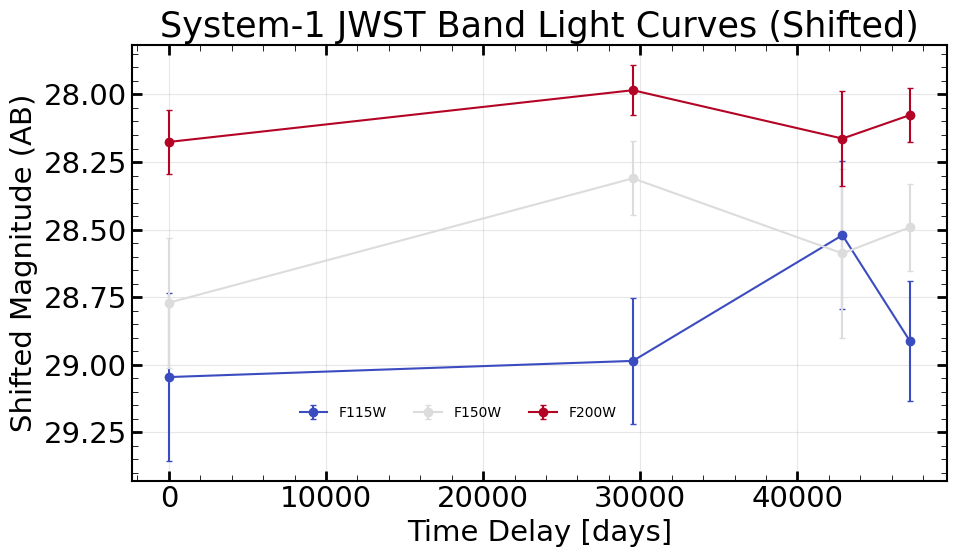

In [343]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# JWST bands
jwstbands = [
    # 'F090W', 
    'F115W', 'F150W','F200W'
    #, 'F210M', 
    # 'F277W', 'F300M', 'F356W', 'F410M', 'F444W'
    ]
fluxkey_jwst = ['f_' + band.upper()  for band in jwstbands] 
fluxerr_key_jwst = ['e_' + band.upper()  for band in jwstbands] 

mu_errs = [0.14, 0.07, 0.12, 0.09]  # system-1 images

plt.figure(figsize=(10,6))
ax = plt.gca()

# 蓝到红渐变色
cmap = get_cmap('coolwarm')  # cool → warm 是蓝→红
n_band = len(jwstbands)
colors = [cmap(i/(n_band-1)) for i in range(n_band)]

# 先计算每个 band 的平均 mag
band_means = []
for b, band in enumerate(jwstbands):
    flux_band = []
    for i, col in enumerate(sel_tab):
        img_idx = int(col['ID_2'].split('.')[1]) - 1
        mu = systems_data["system-1 (z=6.07)"]["images"][img_idx]["mu"]
        f_obs = float(col[fluxkey_jwst[b]])
        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5*np.log10(f_corr)
        flux_band.append(mag_corr)
    band_means.append(np.mean(flux_band))

ref_mean = band_means[0]

# 绘制光变曲线
for b, band in enumerate(jwstbands):
    flux_band = []
    flux_err_band = []
    tdelay_band = []

    for i, col in enumerate(sel_tab):
        img_idx = int(col['ID_2'].split('.')[1]) - 1
        mu = systems_data["system-1 (z=6.07)"]["images"][img_idx]["mu"]
        mu_err = mu_errs[img_idx]
        td = systems_data["system-1 (z=6.07)"]["images"][img_idx]["tdelay"]

        f_obs = float(col[fluxkey_jwst[b]])
        f_err_obs = float(col[fluxerr_key_jwst[b]])

        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5*np.log10(f_corr)
        mag_err = (2.5/np.log(10)) * f_err_obs / f_obs
        mag_err = np.sqrt(mag_err**2 + (2.5/np.log(10)*mu_err/np.abs(mu))**2)

        flux_band.append(mag_corr)
        flux_err_band.append(mag_err)
        tdelay_band.append(td)

    flux_band = np.array(flux_band)
    flux_err_band = np.array(flux_err_band)
    tdelay_band = np.array(tdelay_band)

    # shift 到参考 band
    shift = ref_mean - band_means[b]
    flux_band_shift = flux_band #+ shift

    idx_sort = np.argsort(tdelay_band)
    ax.errorbar(tdelay_band[idx_sort], flux_band_shift[idx_sort],
                yerr=flux_err_band[idx_sort],
                fmt='o-', color=colors[b], label=band, capsize=2)

ax.set_xlabel("Time Delay [days]")
ax.set_ylabel("Shifted Magnitude (AB)")
ax.invert_yaxis()
ax.set_title("System-1 JWST Band Light Curves (Shifted)")
ax.grid(alpha=0.3)

# 横向 legend
ax.legend(frameon=False, fontsize=10, ncol=5, loc='upper center', bbox_to_anchor=(0.4, 0.2))
# ax.set_ylim(30, 28.8)

plt.tight_layout()
plt.show()

/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/1420330317.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('coolwarm')


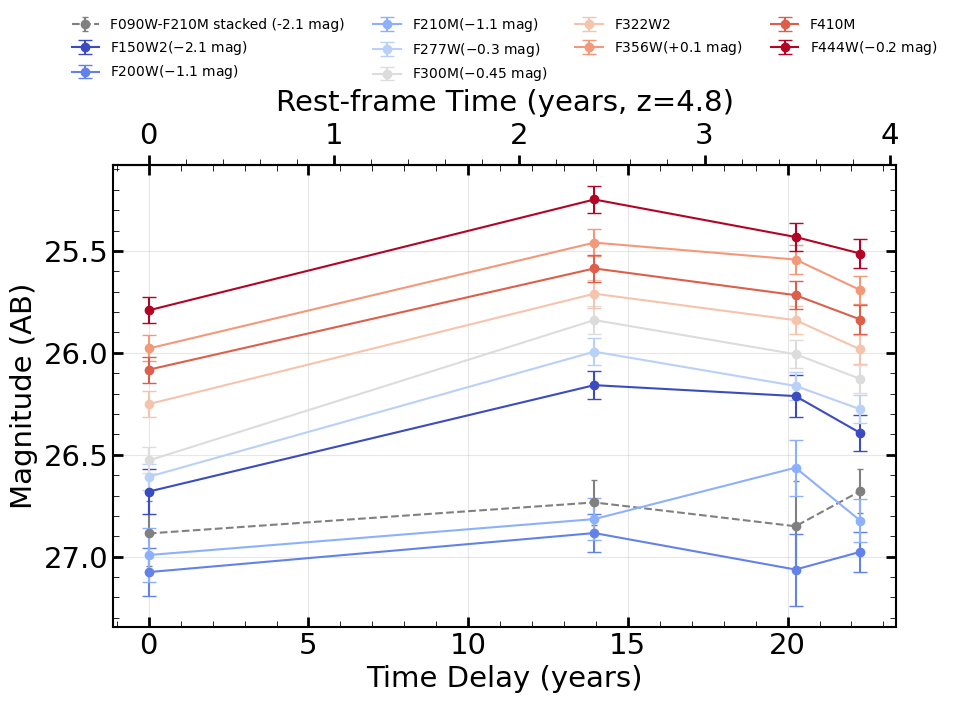

Band            N    chi2       chi2_red   p-value   
SW stack        4    1.418      0.473      0.701     
F150W2          4    17.783     5.928      0.000     
F200W           4    1.939      0.646      0.585     
F210M           4    5.088      1.696      0.165     
F277W           4    46.872     15.624     0.000     
F300M           4    60.230     20.077     0.000     
F322W2          4    37.480     12.493     0.000     
F356W           4    36.337     12.112     0.000     
F410M           4    31.011     10.337     0.000     
F444W           4    35.592     11.864     0.000     

Maximum variability amplitude (Δmag ± err):
F150W2          Δmag = 0.522 ± 0.131
F200W           Δmag = 0.191 ± 0.150
F210M           Δmag = 0.428 ± 0.191
F277W           Δmag = 0.614 ± 0.093
F300M           Δmag = 0.689 ± 0.093
F322W2          Δmag = 0.542 ± 0.093
F356W           Δmag = 0.519 ± 0.093
F410M           Δmag = 0.497 ± 0.093
F444W           Δmag = 0.544 ± 0.093


In [390]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import scipy.stats as stats

chi2_results = {}
z = 4.8
# 分组
bright_bands = ['F150W2','F200W', 'F210M',  'F277W', 'F300M', 'F322W2', 'F356W', 'F410M', 'F444W']
# faint_bands = ['F090W', 'F115W', 'F150W', 'F200W', 'F210M']
# faint_bands = ['F150W', 'F200W', 'F210M']
faint_bands = ['F090W', 'F115W', 'F150W']
bright_bands_shift = [2.1, 1.1,1.1, 0.3, 0.45,0,-0.1,0,0.2]
bright_flux_keys = ['f_' + b for b in bright_bands]
bright_err_keys = ['e_' + b for b in bright_bands]

faint_flux_keys = ['f_' + b for b in faint_bands]
faint_err_keys = ['e_' + b for b in faint_bands]

mu_errs = [0.14, 0.07, 0.12, 0.09]  # system-1 images

plt.figure(figsize=(10,8))
ax = plt.gca()

# 渐变色蓝->红
cmap = get_cmap('coolwarm')
colors_bright = [cmap(i/(len(bright_bands)-1)) for i in range(len(bright_bands))]

# ---- stack 暗 band ----
stack_flux = []
stack_err = []
stack_tdelay = []

for i, col in enumerate(sel_tab):
    img_idx = int(col['ID_2'].split('.')[1]) - 1
    td = systems_data["system-1 (z=6.07)"]["images"][img_idx]["tdelay"]

    flux_list = []
    flux_err_list = []
    mu_list = []
    mu_err_list = []

    for b in range(len(faint_bands)):
        f_obs = float(col[faint_flux_keys[b]])
        f_err_obs = float(col[faint_err_keys[b]])
        mu = systems_data["system-1 (z=6.07)"]["images"][img_idx]["mu"]
        mu_err = mu_errs[img_idx]

        flux_list.append(f_obs)
        flux_err_list.append(f_err_obs)
        mu_list.append(mu)
        mu_err_list.append(mu_err)

    flux_list = np.array(flux_list)
    flux_err_list = np.array(flux_err_list)
    mu_list = np.array(mu_list)
    mu_err_list = np.array(mu_err_list)

    # 先在 flux 空间做加权平均
    weights = 1.0 / flux_err_list**2
    flux_stack_obs = np.sum(flux_list * weights) / np.sum(weights)
    flux_stack_obs_err = np.sqrt(1.0 / np.sum(weights))

    # 平均 mu
    mu_stack = np.mean(np.abs(mu_list))  # 取绝对值
    # 修正 flux
    flux_stack_corr = flux_stack_obs / mu_stack
    # 误差传播，只考虑 flux 叠加的不确定性，不放大 mu_err
    flux_stack_corr_err = flux_stack_obs_err / mu_stack

    # 转回 mag
    mag_stack = 31.4 - 2.5 * np.log10(flux_stack_corr)
    mag_stack_err = (2.5 / np.log(10)) * flux_stack_corr_err / flux_stack_corr

    stack_flux.append(mag_stack)
    stack_err.append(mag_stack_err)
    stack_tdelay.append(td)

shift = bright_bands_shift[0]
stack_flux = np.array(stack_flux) - shift
stack_err = np.array(stack_err)
stack_tdelay = np.array(stack_tdelay)/365/(1+z)
idx_sort = np.argsort(stack_tdelay)
ax.errorbar(stack_tdelay[idx_sort], stack_flux[idx_sort], yerr=stack_err[idx_sort],
            fmt='o--', color='gray', label = f'F090W-F210M stacked (-{shift} mag)', capsize=2)

# ---- stack faint bands ----
weights = 1 / stack_err**2
mean_mag = np.sum(stack_flux * weights) / np.sum(weights)
chi2 = np.sum(((stack_flux - mean_mag)**2) / stack_err**2)
dof = len(stack_flux) - 1
chi2_red = chi2 / dof
p_value = 1 - stats.chi2.cdf(chi2, dof)
chi2_results['SW stack'] = dict(
    N=len(stack_flux),
    chi2=chi2,
    chi2_red=chi2_red,
    p_value=p_value
)

# ---- 先画亮的 band ----
for b, band in enumerate(bright_bands):
    flux_band = []
    flux_err_band = []
    tdelay_band = []
    shift = bright_bands_shift[b]
    for i, col in enumerate(sel_tab):
        img_idx = int(col['ID_2'].split('.')[1]) - 1
        mu = systems_data["system-1 (z=6.07)"]["images"][img_idx]["mu"]
        mu_err = mu_errs[img_idx]
        td = systems_data["system-1 (z=6.07)"]["images"][img_idx]["tdelay"]

        f_obs = float(col[bright_flux_keys[b]])
        f_err_obs = float(col[bright_err_keys[b]])

        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5*np.log10(f_corr)
        mag_err = np.sqrt((2.5/np.log(10)*f_err_obs/f_obs)**2 + (2.5/np.log(10)*mu_err/np.abs(mu))**2)

        flux_band.append(mag_corr)
        flux_err_band.append(mag_err)
        tdelay_band.append(td)

    flux_band = np.array(flux_band)
    flux_err_band = np.array(flux_err_band)
    tdelay_band = np.array(tdelay_band)/365/(1+z)

    idx_sort = np.argsort(tdelay_band)
    if(shift != 0):
        if(shift > 0):
            text = band + (r'($-$' + f'{np.abs(shift)} mag)')
        else:
            text = band + (r'($+$' + f'{np.abs(shift)} mag)')
        ax.errorbar(tdelay_band[idx_sort], flux_band[idx_sort] - shift,
                    yerr=flux_err_band[idx_sort],
                    fmt='o-', color=colors_bright[b], label=text, capsize=5)
    else:
        ax.errorbar(tdelay_band[idx_sort], flux_band[idx_sort],
                    yerr=flux_err_band[idx_sort],
                    fmt='o-', color=colors_bright[b], label=band, capsize=5)

    # 加权平均作为恒定模型
    weights = 1 / flux_err_band**2
    mean_mag = np.sum(flux_band * weights) / np.sum(weights)

    chi2 = np.sum(((flux_band - mean_mag)**2) / flux_err_band**2)
    dof = len(flux_band) - 1
    chi2_red = chi2 / dof
    p_value = 1 - stats.chi2.cdf(chi2, dof)

    chi2_results[band] = dict(
        N=len(flux_band),
        chi2=chi2,
        chi2_red=chi2_red,
        p_value=p_value
    )


# ---- 画图美化 ----
ax.set_xlabel("Time Delay (years)")
ax.set_ylabel("Magnitude (AB)")
ax.invert_yaxis()
# ax.set_title("System-1 JWST Light Curves (Bright bands + stacked faint bands)")
ax.grid(alpha=0.3)

# 横向 legend
ax.legend(frameon=False, fontsize=10, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.35))

# ---- 添加rest-frame时间轴 ----
z = 4.8
def obs_to_rest(t_obs):
    return t_obs / (1 + z)

def rest_to_obs(t_rest):
    return t_rest * (1 + z)

secax = ax.secondary_xaxis('top', functions=(obs_to_rest, rest_to_obs))
secax.set_xlabel(f"Rest-frame Time (years, z={z})")
secax.xaxis.labelpad = 8  # 轴标签与图的间距
# ---- 去掉上轴多余的刻度 ----
secax.tick_params(which='both', direction='out', top=True, labeltop=True)
# secax.set_ticks_position('top')  # 确保只在上方显示
# secax.xaxis.set_tick_params(bottom=False)  # 不在下方重复显示
# # 若想让刻度更稀疏（只显示几个）
# secax.set_xticks(np.linspace(*ax.get_xlim(), 5))  # 5个主刻度，可调整数量

plt.tight_layout()
plt.show()

# ---- 输出结果 ----
print(f"{'Band':<15} {'N':<4} {'chi2':<10} {'chi2_red':<10} {'p-value':<10}")
for band, res in chi2_results.items():
    print(f"{band:<15} {res['N']:<4d} {res['chi2']:<10.3f} {res['chi2_red']:<10.3f} {res['p_value']:<10.3f}")

# ---- 计算每个band的最大光变幅度（含误差） ----
print("\nMaximum variability amplitude (Δmag ± err):")
for band, res in chi2_results.items():
    if band == 'SW stack':
        continue  # 跳过stack结果
    flux_band = []
    flux_err_band = []
    for col in sel_tab:
        img_idx = int(col['ID_2'].split('.')[1]) - 1
        mu = systems_data["system-1 (z=6.07)"]["images"][img_idx]["mu"]
        mu_err = mu_errs[img_idx]

        f_obs = float(col['f_' + band])
        f_err_obs = float(col['e_' + band])
        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5 * np.log10(f_corr)
        mag_err = np.sqrt(
            (2.5 / np.log(10) * f_err_obs / f_obs) ** 2 +
            (2.5 / np.log(10) * mu_err / np.abs(mu)) ** 2
        )

        flux_band.append(mag_corr)
        flux_err_band.append(mag_err)

    flux_band = np.array(flux_band)
    flux_err_band = np.array(flux_err_band)

    idx_max = np.argmax(flux_band)
    idx_min = np.argmin(flux_band)
    delta_mag = flux_band[idx_max] - flux_band[idx_min]
    delta_mag_err = np.sqrt(flux_err_band[idx_max] ** 2 + flux_err_band[idx_min] ** 2)

    print(f"{band:<15} Δmag = {delta_mag:.3f} ± {delta_mag_err:.3f}")

In [371]:
mu_err/np.abs(mu)

0.04072398190045249

In [365]:
sel_tab

ID_2,RA_1_1,DEC_1_1,id_2_1,RA_2_1,DEC_2_1,f_F090W,e_F090W,f_F115W,e_F115W,f_F150W2,e_F150W2,f_F150W,e_F150W,f_F200W,e_F200W,f_F210M,e_F210M,f_F277W,e_F277W,f_F300M,e_F300M,f_F322W2,e_F322W2,f_F356W,e_F356W,f_F410M,e_F410M,f_F444W,e_F444W,Separation_1,id_1_2,ra_1_2,dec_1_2,f435w_mag,f435w_magerr_1,f435w_flux,f435w_fluxerr,f435w_fluxnJy,f435w_fluxnJyerr,f435w_sig,f606w_mag,f606w_magerr_1,f606w_flux,f606w_fluxerr,f606w_fluxnJy,f606w_fluxnJyerr,f606w_sig,f814w_mag,f814w_magerr_1,f814w_flux,f814w_fluxerr,f814w_fluxnJy,f814w_fluxnJyerr,f814w_sig,f105w_mag,f105w_magerr_1,f105w_flux,f105w_fluxerr,f105w_fluxnJy,f105w_fluxnJyerr,f105w_sig,f125w_mag,f125w_magerr_1,f125w_flux,f125w_fluxerr,f125w_fluxnJy,f125w_fluxnJyerr,f125w_sig,f140w_mag,f140w_magerr_1,f140w_flux,f140w_fluxerr,f140w_fluxnJy,f140w_fluxnJyerr,f140w_sig,f160w_mag,f160w_magerr_1,f160w_flux,f160w_fluxerr,f160w_fluxnJy,f160w_fluxnJyerr,f160w_sig,ra_2_2,dec_2_2,f125w_fluxerr_njy,f125w_magerr_2,f140w_fluxerr_njy,f140w_magerr_2,f105w_fluxerr_njy,f105w_magerr_2,f606w_fluxerr_njy,f606w_magerr_2,f435w_fluxerr_njy,f435w_magerr_2,f814w_fluxerr_njy,f814w_magerr_2,f160w_fluxerr_njy,f160w_magerr_2,ID_2_2,Separation_2,Separation_1a,f125w_sig_new,f140w_sig_new,f105w_sig_new,f606w_sig_new,f435w_sig_new,f814w_sig_new,f160w_sig_new,F435W_CIRC1,F435W_CIRC1_e,F606W_CIRC1,F606W_CIRC1_e,F814W_CIRC1,F814W_CIRC1_e,ID,RA,DEC,X,Y,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_sigma,semiminor_sigma,orientation,eccentricity,min_value,max_value,local_background,kron_radius,Gini,det_segment_flux,det_segment_fluxerr,det_kron_flux,det_kron_fluxerr,F090W_CIRC1,F090W_CIRC1_e,F090W_CIRC1_en,F090W_CIRC2,F090W_CIRC2_e,F090W_CIRC2_en,F090W_CIRC3,F090W_CIRC3_e,F090W_CIRC3_en,F090W_CIRC4,F090W_CIRC4_e,F090W_CIRC4_en,F090W_CIRC5,F090W_CIRC5_e,F090W_CIRC5_en,F090W_CIRC6,F090W_CIRC6_e,F090W_CIRC6_en,F090W_KRON,F090W_KRON_S,F090W_KRON_S_e,F090W_KRON_S_en,F090W_KRON_e,F090W_KRON_en,F090W_local_background,F090W_segment_flux,F090W_segment_flux_err,F115W_CIRC1,F115W_CIRC1_e,F115W_CIRC1_en,F115W_CIRC2,F115W_CIRC2_e,F115W_CIRC2_en,F115W_CIRC3,F115W_CIRC3_e,F115W_CIRC3_en,F115W_CIRC4,F115W_CIRC4_e,F115W_CIRC4_en,F115W_CIRC5,F115W_CIRC5_e,F115W_CIRC5_en,F115W_CIRC6,F115W_CIRC6_e,F115W_CIRC6_en,F115W_KRON,F115W_KRON_S,F115W_KRON_S_e,F115W_KRON_S_en,F115W_KRON_e,F115W_KRON_en,F115W_local_background,F115W_segment_flux,F115W_segment_flux_err,F150W2_CIRC1,F150W2_CIRC1_e,F150W2_CIRC1_en,F150W2_CIRC2,F150W2_CIRC2_e,F150W2_CIRC2_en,F150W2_CIRC3,F150W2_CIRC3_e,F150W2_CIRC3_en,F150W2_CIRC4,F150W2_CIRC4_e,F150W2_CIRC4_en,F150W2_CIRC5,F150W2_CIRC5_e,F150W2_CIRC5_en,F150W2_CIRC6,F150W2_CIRC6_e,F150W2_CIRC6_en,F150W2_KRON,F150W2_KRON_S,F150W2_KRON_S_e,F150W2_KRON_S_en,F150W2_KRON_e,F150W2_KRON_en,F150W2_local_background,F150W2_segment_flux,F150W2_segment_flux_err,F150W_CIRC1,F150W_CIRC1_e,F150W_CIRC1_en,F150W_CIRC2,F150W_CIRC2_e,F150W_CIRC2_en,F150W_CIRC3,F150W_CIRC3_e,F150W_CIRC3_en,F150W_CIRC4,F150W_CIRC4_e,F150W_CIRC4_en,F150W_CIRC5,F150W_CIRC5_e,F150W_CIRC5_en,F150W_CIRC6,F150W_CIRC6_e,F150W_CIRC6_en,F150W_KRON,F150W_KRON_S,F150W_KRON_S_e,F150W_KRON_S_en,F150W_KRON_e,F150W_KRON_en,F150W_local_background,F150W_segment_flux,F150W_segment_flux_err,F200W_CIRC1,F200W_CIRC1_e,F200W_CIRC1_en,F200W_CIRC2,F200W_CIRC2_e,F200W_CIRC2_en,F200W_CIRC3,F200W_CIRC3_e,F200W_CIRC3_en,F200W_CIRC4,F200W_CIRC4_e,F200W_CIRC4_en,F200W_CIRC5,F200W_CIRC5_e,F200W_CIRC5_en,F200W_CIRC6,F200W_CIRC6_e,F200W_CIRC6_en,F200W_KRON,F200W_KRON_S,F200W_KRON_S_e,F200W_KRON_S_en,F200W_KRON_e,F200W_KRON_en,F200W_local_background,F200W_segment_flux,F200W_segment_flux_err,F210M_CIRC1,F210M_CIRC1_e,F210M_CIRC1_en,F210M_CIRC2,F210M_CIRC2_e,F210M_CIRC2_en,F210M_CIRC3,F210M_CIRC3_e,F210M_CIRC3_en,F210M_CIRC4,F210M_CIRC4_e,F210M_CIRC4_en,F210M_CIRC5,F210M_CIRC5_e,F210M_CIRC5_en,F210M_CIRC6,F210M_CIRC6_e,F210M_CIRC6_en,F210M_KRON,F210M_KRON_S,F210M_KRON_S_e,F210M_KRON_S_en,F210M_KRON_e,F210M_KRON_en,F210M_local_background,F210M_segment_flux,F210M_segment_flux_err,F277W_CIRC1

In [368]:
-2.5*np.log10((578.0670710403181 - 28.903353552015904)/578.0670710403181)	

0.05569098677788063

In [369]:
2.5/np.log(10)*28.903353552015904/578.0670710403181

0.05428681023790647

In [370]:
np.sqrt(0.05428681023790647**2 * 2)

0.07677314329642192

2.3
[29.07223011 19.12271934 39.05092345 23.28589644 27.89020919 46.90546286
 43.70897327 88.34665891 61.13119574 54.67253338]
2.4
[ 6.29095318  4.05447287 28.26887095 25.08116017 31.1105848  51.82512094
 27.61095212 86.06509863 54.30139965 48.64947941]
2.5
[ 35.61721605  28.34021193  37.02259599  51.93613992  57.75530858
 129.51167516  87.38989464 204.19200208 146.58744185 147.88339978]


/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/1488378062.py:63: UserWarning: Warning: converting a masked element to nan.
  hst_mag      = np.array([col[k] for k in magkey_hst], dtype=float)
/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/1488378062.py:65: UserWarning: Warning: converting a masked element to nan.
  hst_sig      = np.array([col[k] for k in sigkey_hst], dtype=float)


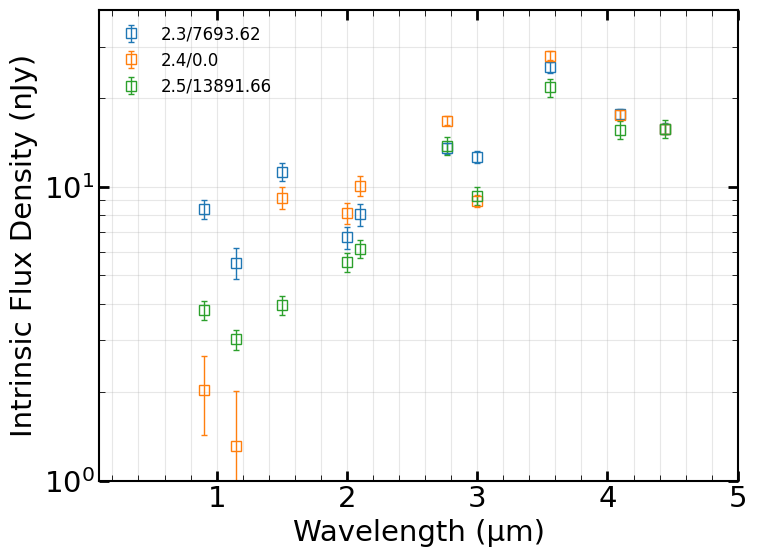

In [427]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

mask = np.array(['.' in i for i in tab_hst_jwst_combined['ID_2']])
sel_tab = tab_hst_jwst_combined[mask]





mu_errs = [0.05, 0.07, 0.15, 0.12, 0.57]  # 依次对应 1.1,1.2,1.3,1.4
# 筛选 system-1
mask = np.array(['2.3' in i or '2.4' in i  or '2.5' in i for i in tab_hst_jwst_combined['ID_2']])
sel_tab = tab_hst_jwst_combined[mask]

hstbands = ['F435W', 'F606W', 'F814W']
jwstbands = ['F090W', 'F115W', 'F150W', 'F200W', 'F210M', 'F277W',  'F300M', 'F356W', 'F410M', 'F444W']
# wave_hst = np.array([1.25, 1.4, 1.05, 0.606, 0.435, 0.814, 1.60])  # micron
wave_hst = np.array([ 0.435, 0.606, 0.814])  # micron
wave_jwst = np.array([0.9, 1.15, 1.50, 2.00, 2.10, 2.77, 3.00, 3.56, 4.10, 4.44])

magkey_hst = [band.lower() + '_mag' for band in hstbands] 
magerr_key_hst = [band.lower() + '_magerr_2' for band in hstbands] 
# magkey_jwst = ['MAG_KRON_' + band.upper()  for band in jwstbands] 
# magerr_key_jwst = ['MAGERR_KRON_' + band.upper()  for band in jwstbands] 
# fluxkey_jwst = ['f_' + band.upper()  for band in jwstbands] 
# fluxerr_key_jwst = ['e_' + band.upper()  for band in jwstbands] 
fluxkey_jwst = [band.upper() + '_CIRC3' for band in jwstbands] 
fluxerr_key_jwst = [band.upper() + '_CIRC3_en' for band in jwstbands] 
sigkey_hst = [band.lower() + '_sig_new' for band in hstbands] 


color_cycle = cycle(plt.cm.tab10.colors)  # 给不同像用不同颜色
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# AB mag 转 nJy
def mag_to_njy(mag):
    return 10**((31.4 - mag) / 2.5)

color_cycle = cycle(plt.cm.tab10.colors)

plotted_labels = set()  # 避免重复 legend
plt.figure(figsize=(8, 6))
color_cycle = cycle(plt.cm.tab10.colors)
plotted_labels = set()

ax = plt.gca()

jwstflux_list = []
jwstfluxerr_list = []
for col in sel_tab:
    name = col['ID_2']
    color = next(color_cycle)

    img_idx = int(name.split('.')[1]) - 1
    mu = systems_data["system-2 (z=4.31)"]["images"][img_idx]["mu"]
    mu_err = mu_errs[img_idx]  # 放大率误差
    td = systems_data["system-2 (z=4.31)"]["images"][img_idx]["tdelay"]

    hst_mag      = np.array([col[k] for k in magkey_hst], dtype=float)
    hst_mag_err  = np.array([col[k] for k in magerr_key_hst], dtype=float)
    hst_sig      = np.array([col[k] for k in sigkey_hst], dtype=float)
    # jwst_mag     = np.array([systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F150W2'], systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F322W2']])#np.array([col[k] for k in magkey_jwst], dtype=float)
    # jwst_mag_err = np.array([systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F150W2_err'], systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F322W2_err']])#np.array([col[k] for k in magerr_key_jwst], dtype=float)
    # jwst_mag      = np.array([col[k] for k in magkey_jwst], dtype=float)
    # jwst_mag_err  = np.array([col[k] for k in magerr_key_jwst], dtype=float)
    jwst_flux      = np.array([col[k] for k in fluxkey_jwst], dtype=float)
    jwst_flux_err  = np.array([col[k] for k in fluxerr_key_jwst], dtype=float)

    mu_abs = np.abs(mu)
    hst_mag_corr = hst_mag + 2.5 * np.log10(mu_abs)
    
    # jwst_mag_corr = jwst_mag + 2.5 * np.log10(mu_abs)
    jwst_flux_corr = jwst_flux / mu_abs
    jwst_flux_err = jwst_flux_err / mu_abs

    # HST flux 误差：原始 + mu 传播
    

    factor = 15.78743366/jwst_flux_corr[-1]
    
    jwstflux_list.append(jwst_flux_corr*factor)
    jwstfluxerr_list.append(jwst_flux_err*factor)
    print(name)
    print(jwst_flux)
    hst_flux_corr = mag_to_njy(hst_mag_corr)
    # jwst_flux = mag_to_njy(jwst_mag_corr)

    hst_flux_err = mag_to_njy(hst_mag_err)# hst_flux * (np.log(10)/2.5) * hst_mag_err

    hst_flux_err_corr = hst_flux_corr * np.sqrt((hst_flux_err/hst_flux)**2 + (mu_err/mu)**2)
    jwst_flux_err_corr = jwst_flux_corr * np.sqrt((jwst_flux_err/jwst_flux)**2 + (mu_err/mu)**2)

    # jwst_flux_err = jwst_flux * (np.log(10)/2.5) * jwst_mag_err

    det_mask = (hst_sig >= 2) & np.isfinite(hst_flux_corr)
    uplim_mask = (~det_mask) & np.isfinite(hst_flux_err)

    # jwst_mask = (jwst_mag_err > 0)*(jwst_mag < 40)*(jwst_mag > 20)
    # 检测点
    if np.any(det_mask):
        ax.errorbar(
            wave_hst[det_mask], hst_flux_corr[det_mask]*factor,
            yerr=hst_flux_err[det_mask]*factor,
            fmt='o', ms=5, color=color, mfc='white', mew=1,
            elinewidth=1, capsize=2,
            
        )
        

    # # 上限：横杠+箭头
    # if np.any(uplim_mask):
    #     x_uplim = wave_hst[uplim_mask]
    #     y_uplim = hst_flux_err[uplim_mask]
    #     ax.scatter(x_uplim, y_uplim, marker='_', color=color, s=40, linewidths=1.5)

    #     # 画箭头：短竖线+箭头头部
    #     for x, y in zip(x_uplim, y_uplim):
    #         ax.annotate(
    #             '', xy=(x, y*0.7), xytext=(x, y),  # 竖向移动 30%
    #             arrowprops=dict(arrowstyle='-|>', color=color, lw=1.2, shrinkA=0, shrinkB=0)
    #         )

    # JWST
    if np.all(np.isfinite(jwst_flux_corr)):
        ax.errorbar(
            wave_jwst, jwst_flux_corr*factor, yerr=jwst_flux_err_corr*factor,
            fmt='s', ms=7, color=color, mfc='none', mew=1,
            elinewidth=1, capsize=2, 
            label=name + '/' + str(td) if name not in plotted_labels else None
        )
        plotted_labels.add(name)
ax.set_ylim(1, 4e1)
ax.set_xlim(0.1, 5)
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Intrinsic Flux Density (nJy)")
ax.set_yscale("log")
ax.grid(alpha=0.3, which='both')
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/2668929629.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('coolwarm')


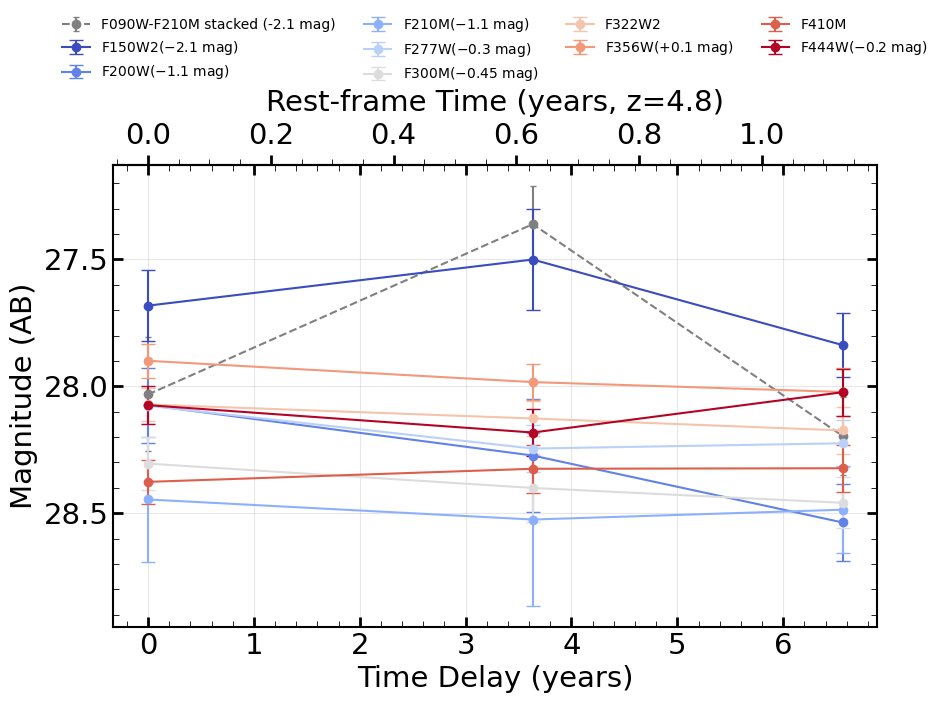

Band            N    chi2       chi2_red   p-value   
SW stack        3    16.058     8.029      0.000     
F150W2          3    2.160      1.080      0.340     
F200W           3    4.854      2.427      0.088     
F210M           3    0.038      0.019      0.981     
F277W           3    2.667      1.333      0.264     
F300M           3    1.128      0.564      0.569     
F322W2          3    0.866      0.433      0.649     
F356W           3    1.395      0.698      0.498     
F410M           3    0.230      0.115      0.891     
F444W           3    1.585      0.793      0.453     

Maximum variability amplitude (Δmag ± err):
F150W2          Δmag = 0.337 ± 0.235
F200W           Δmag = 0.463 ± 0.210
F210M           Δmag = 0.079 ± 0.420
F277W           Δmag = 0.169 ± 0.118
F300M           Δmag = 0.155 ± 0.146
F322W2          Δmag = 0.103 ± 0.114
F356W           Δmag = 0.123 ± 0.114
F410M           Δmag = 0.054 ± 0.128
F444W           Δmag = 0.159 ± 0.130


In [428]:
chi2_results = {}
z = 4.8
# 分组
bright_bands = ['F150W2','F200W', 'F210M',  'F277W', 'F300M', 'F322W2', 'F356W', 'F410M', 'F444W']
# faint_bands = ['F090W', 'F115W', 'F150W', 'F200W', 'F210M']
# faint_bands = ['F150W', 'F200W', 'F210M']
faint_bands = ['F090W', 'F115W', 'F150W']
bright_bands_shift = [2.1, 1.1,1.1, 0.3, 0.45,0,-0.1,0,0.2]
bright_flux_keys = ['f_' + b for b in bright_bands]
bright_err_keys = ['e_' + b for b in bright_bands]

faint_flux_keys = ['f_' + b for b in faint_bands]
faint_err_keys = ['e_' + b for b in faint_bands]

mu_errs = [0.06, 0.07, 0.15, 0.12, 0.57 ]  # system-2 images

plt.figure(figsize=(10,8))
ax = plt.gca()

# 渐变色蓝->红
cmap = get_cmap('coolwarm')
colors_bright = [cmap(i/(len(bright_bands)-1)) for i in range(len(bright_bands))]

# ---- stack 暗 band ----
stack_flux = []
stack_err = []
stack_tdelay = []

for i, col in enumerate(sel_tab):
    img_idx = int(col['ID_2'].split('.')[1]) - 1
    td = systems_data["system-2 (z=4.31)"]["images"][img_idx]["tdelay"]

    flux_list = []
    flux_err_list = []
    mu_list = []
    mu_err_list = []

    for b in range(len(faint_bands)):
        f_obs = float(col[faint_flux_keys[b]])
        f_err_obs = float(col[faint_err_keys[b]])
        mu = systems_data["system-2 (z=4.31)"]["images"][img_idx]["mu"]
        mu_err = mu_errs[img_idx]

        flux_list.append(f_obs)
        flux_err_list.append(f_err_obs)
        mu_list.append(mu)
        mu_err_list.append(mu_err)

    flux_list = np.array(flux_list)
    flux_err_list = np.array(flux_err_list)
    mu_list = np.array(mu_list)
    mu_err_list = np.array(mu_err_list)

    # 先在 flux 空间做加权平均
    weights = 1.0 / flux_err_list**2
    flux_stack_obs = np.sum(flux_list * weights) / np.sum(weights)
    flux_stack_obs_err = np.sqrt(1.0 / np.sum(weights))

    # 平均 mu
    mu_stack = np.mean(np.abs(mu_list))  # 取绝对值
    # 修正 flux
    flux_stack_corr = flux_stack_obs / mu_stack
    # 误差传播，只考虑 flux 叠加的不确定性，不放大 mu_err
    flux_stack_corr_err = flux_stack_obs_err / mu_stack

    # 转回 mag
    mag_stack = 31.4 - 2.5 * np.log10(flux_stack_corr)
    mag_stack_err = (2.5 / np.log(10)) * flux_stack_corr_err / flux_stack_corr

    stack_flux.append(mag_stack)
    stack_err.append(mag_stack_err)
    stack_tdelay.append(td)

shift = bright_bands_shift[0]
stack_flux = np.array(stack_flux) - shift
stack_err = np.array(stack_err)
stack_tdelay = np.array(stack_tdelay)/365/(1+z)
idx_sort = np.argsort(stack_tdelay)
ax.errorbar(stack_tdelay[idx_sort], stack_flux[idx_sort], yerr=stack_err[idx_sort],
            fmt='o--', color='gray', label = f'F090W-F210M stacked (-{shift} mag)', capsize=2)

# ---- stack faint bands ----
weights = 1 / stack_err**2
mean_mag = np.sum(stack_flux * weights) / np.sum(weights)
chi2 = np.sum(((stack_flux - mean_mag)**2) / stack_err**2)
dof = len(stack_flux) - 1
chi2_red = chi2 / dof
p_value = 1 - stats.chi2.cdf(chi2, dof)
chi2_results['SW stack'] = dict(N=len(stack_flux),chi2=chi2,chi2_red=chi2_red,p_value=p_value)

# ---- 先画亮的 band ----
for b, band in enumerate(bright_bands):
    flux_band = []
    flux_err_band = []
    tdelay_band = []
    shift = bright_bands_shift[b]
    for i, col in enumerate(sel_tab):
        img_idx = int(col['ID_2'].split('.')[1]) - 1
        mu = systems_data["system-2 (z=4.31)"]["images"][img_idx]["mu"]
        mu_err = mu_errs[img_idx]
        td = systems_data["system-2 (z=4.31)"]["images"][img_idx]["tdelay"]

        f_obs = float(col[bright_flux_keys[b]])
        f_err_obs = float(col[bright_err_keys[b]])

        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5*np.log10(f_corr)
        mag_err = np.sqrt((2.5/np.log(10)*f_err_obs/f_obs)**2 + (2.5/np.log(10)*mu_err/np.abs(mu))**2)

        flux_band.append(mag_corr)
        flux_err_band.append(mag_err)
        tdelay_band.append(td)

    flux_band = np.array(flux_band)
    flux_err_band = np.array(flux_err_band)
    tdelay_band = np.array(tdelay_band)/365/(1+z)

    idx_sort = np.argsort(tdelay_band)
    if(shift != 0):
        if(shift > 0):
            text = band + (r'($-$' + f'{np.abs(shift)} mag)')
        else:
            text = band + (r'($+$' + f'{np.abs(shift)} mag)')
        ax.errorbar(tdelay_band[idx_sort], flux_band[idx_sort] - shift,
                    yerr=flux_err_band[idx_sort],
                    fmt='o-', color=colors_bright[b], label=text, capsize=5)
    else:
        ax.errorbar(tdelay_band[idx_sort], flux_band[idx_sort],
                    yerr=flux_err_band[idx_sort],
                    fmt='o-', color=colors_bright[b], label=band, capsize=5)

    # 加权平均作为恒定模型
    weights = 1 / flux_err_band**2
    mean_mag = np.sum(flux_band * weights) / np.sum(weights)

    chi2 = np.sum(((flux_band - mean_mag)**2) / flux_err_band**2)
    dof = len(flux_band) - 1
    chi2_red = chi2 / dof
    p_value = 1 - stats.chi2.cdf(chi2, dof)

    chi2_results[band] = dict(N=len(flux_band),chi2=chi2,chi2_red=chi2_red,p_value=p_value)


# ---- 画图美化 ----
ax.set_xlabel("Time Delay (years)")
ax.set_ylabel("Magnitude (AB)")
ax.invert_yaxis()
# ax.set_title("System-1 JWST Light Curves (Bright bands + stacked faint bands)")
ax.grid(alpha=0.3)

# 横向 legend
ax.legend(frameon=False, fontsize=10, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.35))

# ---- 添加rest-frame时间轴 ----
z = 4.8
def obs_to_rest(t_obs):
    return t_obs / (1 + z)

def rest_to_obs(t_rest):
    return t_rest * (1 + z)

secax = ax.secondary_xaxis('top', functions=(obs_to_rest, rest_to_obs))
secax.set_xlabel(f"Rest-frame Time (years, z={z})")
secax.xaxis.labelpad = 8  # 轴标签与图的间距
# ---- 去掉上轴多余的刻度 ----
secax.tick_params(which='both', direction='out', top=True, labeltop=True)
# secax.set_ticks_position('top')  # 确保只在上方显示
# secax.xaxis.set_tick_params(bottom=False)  # 不在下方重复显示
# # 若想让刻度更稀疏（只显示几个）
# secax.set_xticks(np.linspace(*ax.get_xlim(), 5))  # 5个主刻度，可调整数量

plt.tight_layout()
plt.show()

# ---- 输出结果 ----
print(f"{'Band':<15} {'N':<4} {'chi2':<10} {'chi2_red':<10} {'p-value':<10}")
for band, res in chi2_results.items():
    print(f"{band:<15} {res['N']:<4d} {res['chi2']:<10.3f} {res['chi2_red']:<10.3f} {res['p_value']:<10.3f}")

# ---- 计算每个band的最大光变幅度（含误差） ----
print("\nMaximum variability amplitude (Δmag ± err):")
for band, res in chi2_results.items():
    if band == 'SW stack':
        continue  # 跳过stack结果
    flux_band = []
    flux_err_band = []
    for col in sel_tab:
        img_idx = int(col['ID_2'].split('.')[1]) - 1
        mu = systems_data["system-2 (z=4.31)"]["images"][img_idx]["mu"]
        mu_err = mu_errs[img_idx]

        f_obs = float(col['f_' + band])
        f_err_obs = float(col['e_' + band])
        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5 * np.log10(f_corr)
        mag_err = np.sqrt(
            (2.5 / np.log(10) * f_err_obs / f_obs) ** 2 +
            (2.5 / np.log(10) * mu_err / np.abs(mu)) ** 2)

        flux_band.append(mag_corr)
        flux_err_band.append(mag_err)

    flux_band = np.array(flux_band)
    flux_err_band = np.array(flux_err_band)

    idx_max = np.argmax(flux_band)
    idx_min = np.argmin(flux_band)
    delta_mag = flux_band[idx_max] - flux_band[idx_min]
    delta_mag_err = np.sqrt(flux_err_band[idx_max] ** 2 + flux_err_band[idx_min] ** 2)

    print(f"{band:<15} Δmag = {delta_mag:.3f} ± {delta_mag_err:.3f}")

3.1
[ 92.00960635  79.5089315  100.81926785 126.01306722 128.59752875
 207.57144484 106.40869241 284.71348457 162.44263498 195.94714651]
3.2
[ 74.5298095   80.72921632  93.44883333 119.93028054 136.79151078
 208.25324917  85.37263902 272.59375693 135.18782653 134.33455897]
3.3
[ 33.87356331   4.82269806  34.36201254  41.48792839  39.69881604
  83.71233384  33.07966849 103.99621996  41.00420367  68.39742105]


/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/2546283941.py:61: UserWarning: Warning: converting a masked element to nan.
  hst_mag      = np.array([col[k] for k in magkey_hst], dtype=float)
/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/2546283941.py:63: UserWarning: Warning: converting a masked element to nan.
  hst_sig      = np.array([col[k] for k in sigkey_hst], dtype=float)


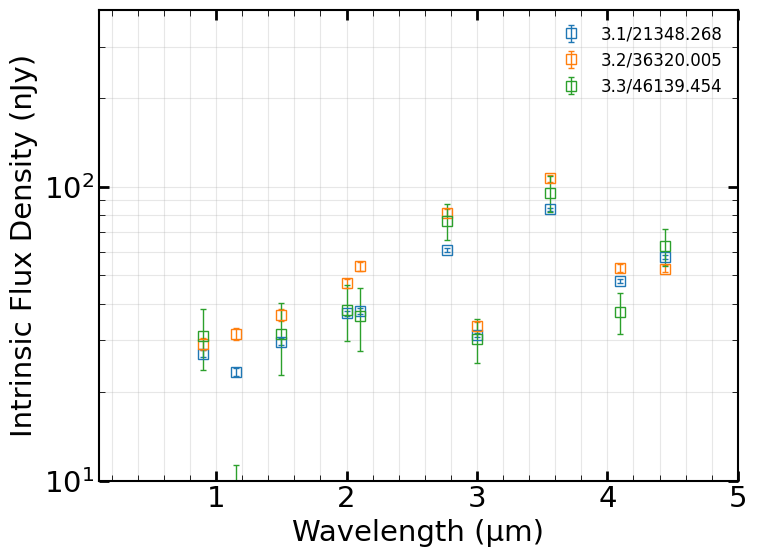

In [429]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

mask = np.array(['.' in i for i in tab_hst_jwst_combined['ID_2']])
sel_tab = tab_hst_jwst_combined[mask]



mu_errs = [0.05, 0.07, 0.15, 0.12, 0.57]  # 依次对应 1.1,1.2,1.3,1.4
# 筛选 system-1
mask = np.array(['3.1' in i or '3.2' in i  or '3.3' in i for i in tab_hst_jwst_combined['ID_2']])
sel_tab = tab_hst_jwst_combined[mask]

hstbands = ['F435W', 'F606W', 'F814W']
jwstbands = ['F090W', 'F115W', 'F150W', 'F200W', 'F210M', 'F277W',  'F300M', 'F356W', 'F410M', 'F444W']
# wave_hst = np.array([1.25, 1.4, 1.05, 0.606, 0.435, 0.814, 1.60])  # micron
wave_hst = np.array([ 0.435, 0.606, 0.814])  # micron
wave_jwst = np.array([0.9, 1.15, 1.50, 2.00, 2.10, 2.77, 3.00, 3.56, 4.10, 4.44])

magkey_hst = [band.lower() + '_mag' for band in hstbands] 
magerr_key_hst = [band.lower() + '_magerr_2' for band in hstbands] 
# magkey_jwst = ['MAG_KRON_' + band.upper()  for band in jwstbands] 
# magerr_key_jwst = ['MAGERR_KRON_' + band.upper()  for band in jwstbands] 
# fluxkey_jwst = ['f_' + band.upper()  for band in jwstbands] 
# fluxerr_key_jwst = ['e_' + band.upper()  for band in jwstbands] 
fluxkey_jwst = [band.upper() + '_CIRC3' for band in jwstbands] 
fluxerr_key_jwst = [band.upper() + '_CIRC3_en' for band in jwstbands] 
sigkey_hst = [band.lower() + '_sig_new' for band in hstbands] 


color_cycle = cycle(plt.cm.tab10.colors)  # 给不同像用不同颜色
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# AB mag 转 nJy
def mag_to_njy(mag):
    return 10**((31.4 - mag) / 2.5)

color_cycle = cycle(plt.cm.tab10.colors)

plotted_labels = set()  # 避免重复 legend
plt.figure(figsize=(8, 6))
color_cycle = cycle(plt.cm.tab10.colors)
plotted_labels = set()

ax = plt.gca()

jwstflux_list = []
jwstfluxerr_list = []
for col in sel_tab:
    name = col['ID_2']
    color = next(color_cycle)

    img_idx = int(name.split('.')[1]) - 1
    mu = systems_data["system-3 (z=4.63)"]["images"][img_idx]["mu"]
    mu_err = mu_errs[img_idx]  # 放大率误差
    td = systems_data["system-3 (z=4.63)"]["images"][img_idx]["tdelay"]

    hst_mag      = np.array([col[k] for k in magkey_hst], dtype=float)
    hst_mag_err  = np.array([col[k] for k in magerr_key_hst], dtype=float)
    hst_sig      = np.array([col[k] for k in sigkey_hst], dtype=float)
    # jwst_mag     = np.array([systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F150W2'], systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F322W2']])#np.array([col[k] for k in magkey_jwst], dtype=float)
    # jwst_mag_err = np.array([systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F150W2_err'], systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F322W2_err']])#np.array([col[k] for k in magerr_key_jwst], dtype=float)
    # jwst_mag      = np.array([col[k] for k in magkey_jwst], dtype=float)
    # jwst_mag_err  = np.array([col[k] for k in magerr_key_jwst], dtype=float)
    jwst_flux      = np.array([col[k] for k in fluxkey_jwst], dtype=float)
    jwst_flux_err  = np.array([col[k] for k in fluxerr_key_jwst], dtype=float)

    mu_abs = np.abs(mu)
    hst_mag_corr = hst_mag + 2.5 * np.log10(mu_abs)
    
    # jwst_mag_corr = jwst_mag + 2.5 * np.log10(mu_abs)
    jwst_flux_corr = jwst_flux / mu_abs
    jwst_flux_err = jwst_flux_err / mu_abs

    # HST flux 误差：原始 + mu 传播
    

    factor = 1#15.78743366/jwst_flux_corr[-1]
    
    jwstflux_list.append(jwst_flux_corr*factor)
    jwstfluxerr_list.append(jwst_flux_err*factor)
    print(name)
    print(jwst_flux)
    hst_flux_corr = mag_to_njy(hst_mag_corr)
    # jwst_flux = mag_to_njy(jwst_mag_corr)

    hst_flux_err = mag_to_njy(hst_mag_err)# hst_flux * (np.log(10)/2.5) * hst_mag_err

    hst_flux_err_corr = hst_flux_corr * np.sqrt((hst_flux_err/hst_flux)**2 + (mu_err/mu)**2)
    jwst_flux_err_corr = jwst_flux_corr * np.sqrt((jwst_flux_err/jwst_flux)**2 + (mu_err/mu)**2)

    # jwst_flux_err = jwst_flux * (np.log(10)/2.5) * jwst_mag_err

    det_mask = (hst_sig >= 2) & np.isfinite(hst_flux_corr)
    uplim_mask = (~det_mask) & np.isfinite(hst_flux_err)

    # jwst_mask = (jwst_mag_err > 0)*(jwst_mag < 40)*(jwst_mag > 20)
    # 检测点
    if np.any(det_mask):
        ax.errorbar(
            wave_hst[det_mask], hst_flux_corr[det_mask]*factor,
            yerr=hst_flux_err[det_mask]*factor,
            fmt='o', ms=5, color=color, mfc='white', mew=1,
            elinewidth=1, capsize=2,
            
        )
    # # 上限：横杠+箭头
    # if np.any(uplim_mask):
    #     x_uplim = wave_hst[uplim_mask]
    #     y_uplim = hst_flux_err[uplim_mask]
    #     ax.scatter(x_uplim, y_uplim, marker='_', color=color, s=40, linewidths=1.5)

    #     # 画箭头：短竖线+箭头头部
    #     for x, y in zip(x_uplim, y_uplim):
    #         ax.annotate(
    #             '', xy=(x, y*0.7), xytext=(x, y),  # 竖向移动 30%
    #             arrowprops=dict(arrowstyle='-|>', color=color, lw=1.2, shrinkA=0, shrinkB=0)
    #         )

    # JWST
    if np.all(np.isfinite(jwst_flux_corr)):
        ax.errorbar(
            wave_jwst, jwst_flux_corr*factor, yerr=jwst_flux_err_corr*factor,
            fmt='s', ms=7, color=color, mfc='none', mew=1,
            elinewidth=1, capsize=2, 
            label=name + '/' + str(td) if name not in plotted_labels else None
        )
        plotted_labels.add(name)
ax.set_ylim(1e1, 4e2)
ax.set_xlim(0.1, 5)
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Intrinsic Flux Density (nJy)")
ax.set_yscale("log")
ax.grid(alpha=0.3, which='both')
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/3180396840.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('coolwarm')


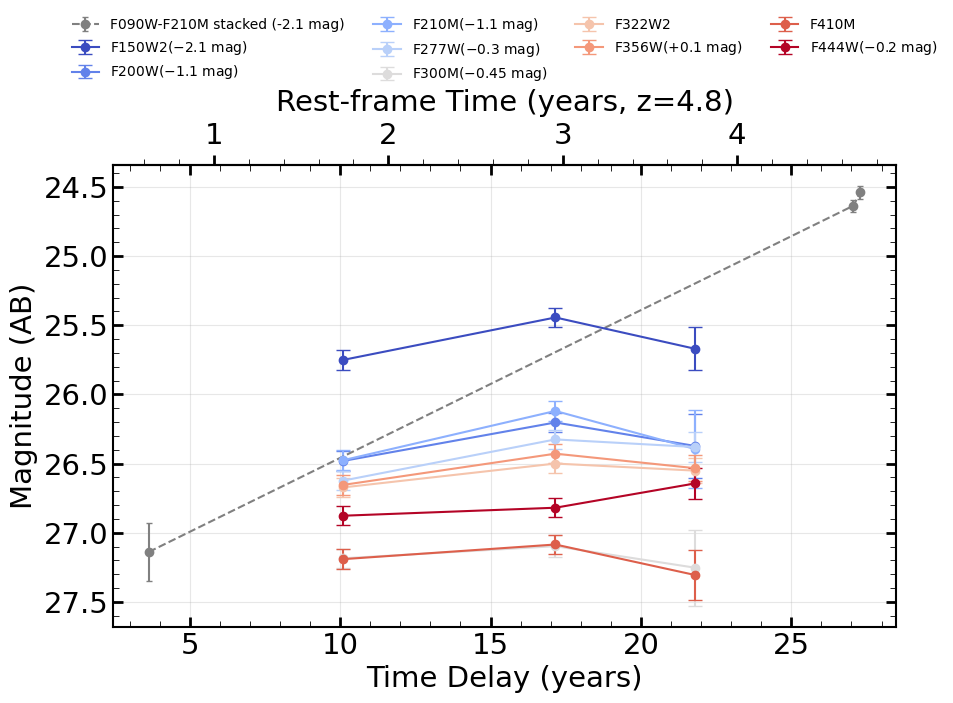

Band            N    chi2       chi2_red   p-value   
SW stack        3    146.145    73.072     0.000     
F150W2          3    9.948      4.974      0.007     
F200W           3    8.025      4.012      0.018     
F210M           3    11.958     5.979      0.003     
F277W           3    9.731      4.866      0.008     
F300M           3    0.852      0.426      0.653     
F322W2          3    3.193      1.596      0.203     
F356W           3    5.280      2.640      0.071     
F410M           3    1.958      0.979      0.376     
F444W           3    3.016      1.508      0.221     

Maximum variability amplitude (Δmag ± err):
F150W2          Δmag = 0.307 ± 0.099
F200W           Δmag = 0.279 ± 0.099
F210M           Δmag = 0.357 ± 0.104
F277W           Δmag = 0.298 ± 0.099
F300M           Δmag = 0.155 ± 0.285
F322W2          Δmag = 0.173 ± 0.099
F356W           Δmag = 0.226 ± 0.099
F410M           Δmag = 0.220 ± 0.195
F444W           Δmag = 0.233 ± 0.134


In [430]:
chi2_results = {}
z = 4.8
# 分组
bright_bands = ['F150W2','F200W', 'F210M',  'F277W', 'F300M', 'F322W2', 'F356W', 'F410M', 'F444W']
# faint_bands = ['F090W', 'F115W', 'F150W', 'F200W', 'F210M']
# faint_bands = ['F150W', 'F200W', 'F210M']
faint_bands = ['F090W', 'F115W', 'F150W']
bright_bands_shift = [2.1, 1.1,1.1, 0.3, 0.45,0,-0.1,0,0.2]
bright_flux_keys = ['f_' + b for b in bright_bands]
bright_err_keys = ['e_' + b for b in bright_bands]

faint_flux_keys = ['f_' + b for b in faint_bands]
faint_err_keys = ['e_' + b for b in faint_bands]

mu_errs = [0.14, 0.10, 0.07, 0.25, 0.16, 0.38 ]  # system-2 images

plt.figure(figsize=(10,8))
ax = plt.gca()

# 渐变色蓝->红
cmap = get_cmap('coolwarm')
colors_bright = [cmap(i/(len(bright_bands)-1)) for i in range(len(bright_bands))]

# ---- stack 暗 band ----
stack_flux = []
stack_err = []
stack_tdelay = []

for i, col in enumerate(sel_tab):
    img_idx = int(col['ID_2'].split('.')[1]) - 1
    td = systems_data["system-2 (z=4.31)"]["images"][img_idx]["tdelay"]

    flux_list = []
    flux_err_list = []
    mu_list = []
    mu_err_list = []

    for b in range(len(faint_bands)):
        f_obs = float(col[faint_flux_keys[b]])
        f_err_obs = float(col[faint_err_keys[b]])
        mu = systems_data["system-2 (z=4.31)"]["images"][img_idx]["mu"]
        mu_err = mu_errs[img_idx]

        flux_list.append(f_obs)
        flux_err_list.append(f_err_obs)
        mu_list.append(mu)
        mu_err_list.append(mu_err)

    flux_list = np.array(flux_list)
    flux_err_list = np.array(flux_err_list)
    mu_list = np.array(mu_list)
    mu_err_list = np.array(mu_err_list)

    # 先在 flux 空间做加权平均
    weights = 1.0 / flux_err_list**2
    flux_stack_obs = np.sum(flux_list * weights) / np.sum(weights)
    flux_stack_obs_err = np.sqrt(1.0 / np.sum(weights))

    # 平均 mu
    mu_stack = np.mean(np.abs(mu_list))  # 取绝对值
    # 修正 flux
    flux_stack_corr = flux_stack_obs / mu_stack
    # 误差传播，只考虑 flux 叠加的不确定性，不放大 mu_err
    flux_stack_corr_err = flux_stack_obs_err / mu_stack

    # 转回 mag
    mag_stack = 31.4 - 2.5 * np.log10(flux_stack_corr)
    mag_stack_err = (2.5 / np.log(10)) * flux_stack_corr_err / flux_stack_corr

    stack_flux.append(mag_stack)
    stack_err.append(mag_stack_err)
    stack_tdelay.append(td)

shift = bright_bands_shift[0]
stack_flux = np.array(stack_flux) - shift
stack_err = np.array(stack_err)
stack_tdelay = np.array(stack_tdelay)/365/(1+z)
idx_sort = np.argsort(stack_tdelay)
ax.errorbar(stack_tdelay[idx_sort], stack_flux[idx_sort], yerr=stack_err[idx_sort],
            fmt='o--', color='gray', label = f'F090W-F210M stacked (-{shift} mag)', capsize=2)

# ---- stack faint bands ----
weights = 1 / stack_err**2
mean_mag = np.sum(stack_flux * weights) / np.sum(weights)
chi2 = np.sum(((stack_flux - mean_mag)**2) / stack_err**2)
dof = len(stack_flux) - 1
chi2_red = chi2 / dof
p_value = 1 - stats.chi2.cdf(chi2, dof)
chi2_results['SW stack'] = dict(N=len(stack_flux),chi2=chi2,chi2_red=chi2_red,p_value=p_value)

# ---- 先画亮的 band ----
for b, band in enumerate(bright_bands):
    flux_band = []
    flux_err_band = []
    tdelay_band = []
    shift = bright_bands_shift[b]
    for i, col in enumerate(sel_tab):
        img_idx = int(col['ID_2'].split('.')[1]) - 1
        mu = systems_data["system-3 (z=4.63)"]["images"][img_idx]["mu"]
        mu_err = mu_errs[img_idx]
        td = systems_data["system-3 (z=4.63)"]["images"][img_idx]["tdelay"]

        f_obs = float(col[bright_flux_keys[b]])
        f_err_obs = float(col[bright_err_keys[b]])

        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5*np.log10(f_corr)
        mag_err = np.sqrt((2.5/np.log(10)*f_err_obs/f_obs)**2 + (2.5/np.log(10)*mu_err/np.abs(mu))**2)

        flux_band.append(mag_corr)
        flux_err_band.append(mag_err)
        tdelay_band.append(td)

    flux_band = np.array(flux_band)
    flux_err_band = np.array(flux_err_band)
    tdelay_band = np.array(tdelay_band)/365/(1+z)

    idx_sort = np.argsort(tdelay_band)
    if(shift != 0):
        if(shift > 0):
            text = band + (r'($-$' + f'{np.abs(shift)} mag)')
        else:
            text = band + (r'($+$' + f'{np.abs(shift)} mag)')
        ax.errorbar(tdelay_band[idx_sort], flux_band[idx_sort] - shift,
                    yerr=flux_err_band[idx_sort],
                    fmt='o-', color=colors_bright[b], label=text, capsize=5)
    else:
        ax.errorbar(tdelay_band[idx_sort], flux_band[idx_sort],
                    yerr=flux_err_band[idx_sort],
                    fmt='o-', color=colors_bright[b], label=band, capsize=5)

    # 加权平均作为恒定模型
    weights = 1 / flux_err_band**2
    mean_mag = np.sum(flux_band * weights) / np.sum(weights)

    chi2 = np.sum(((flux_band - mean_mag)**2) / flux_err_band**2)
    dof = len(flux_band) - 1
    chi2_red = chi2 / dof
    p_value = 1 - stats.chi2.cdf(chi2, dof)

    chi2_results[band] = dict(N=len(flux_band),chi2=chi2,chi2_red=chi2_red,p_value=p_value)


# ---- 画图美化 ----
ax.set_xlabel("Time Delay (years)")
ax.set_ylabel("Magnitude (AB)")
ax.invert_yaxis()
# ax.set_title("System-1 JWST Light Curves (Bright bands + stacked faint bands)")
ax.grid(alpha=0.3)

# 横向 legend
ax.legend(frameon=False, fontsize=10, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.35))

# ---- 添加rest-frame时间轴 ----
z = 4.8
def obs_to_rest(t_obs):
    return t_obs / (1 + z)

def rest_to_obs(t_rest):
    return t_rest * (1 + z)

secax = ax.secondary_xaxis('top', functions=(obs_to_rest, rest_to_obs))
secax.set_xlabel(f"Rest-frame Time (years, z={z})")
secax.xaxis.labelpad = 8  # 轴标签与图的间距
# ---- 去掉上轴多余的刻度 ----
secax.tick_params(which='both', direction='out', top=True, labeltop=True)
# secax.set_ticks_position('top')  # 确保只在上方显示
# secax.xaxis.set_tick_params(bottom=False)  # 不在下方重复显示
# # 若想让刻度更稀疏（只显示几个）
# secax.set_xticks(np.linspace(*ax.get_xlim(), 5))  # 5个主刻度，可调整数量

plt.tight_layout()
plt.show()

# ---- 输出结果 ----
print(f"{'Band':<15} {'N':<4} {'chi2':<10} {'chi2_red':<10} {'p-value':<10}")
for band, res in chi2_results.items():
    print(f"{band:<15} {res['N']:<4d} {res['chi2']:<10.3f} {res['chi2_red']:<10.3f} {res['p_value']:<10.3f}")

# ---- 计算每个band的最大光变幅度（含误差） ----
print("\nMaximum variability amplitude (Δmag ± err):")
for band, res in chi2_results.items():
    if band == 'SW stack':
        continue  # 跳过stack结果
    flux_band = []
    flux_err_band = []
    for col in sel_tab:
        img_idx = int(col['ID_2'].split('.')[1]) - 1
        mu = systems_data["system-3 (z=4.63)"]["images"][img_idx]["mu"]
        mu_err = mu_errs[img_idx]

        f_obs = float(col['f_' + band])
        f_err_obs = float(col['e_' + band])
        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5 * np.log10(f_corr)
        mag_err = np.sqrt(
            (2.5 / np.log(10) * f_err_obs / f_obs) ** 2 +
            (2.5 / np.log(10) * mu_err / np.abs(mu)) ** 2)

        flux_band.append(mag_corr)
        flux_err_band.append(mag_err)

    flux_band = np.array(flux_band)
    flux_err_band = np.array(flux_err_band)

    idx_max = np.argmax(flux_band)
    idx_min = np.argmin(flux_band)
    delta_mag = flux_band[idx_max] - flux_band[idx_min]
    delta_mag_err = np.sqrt(flux_err_band[idx_max] ** 2 + flux_err_band[idx_min] ** 2)

    print(f"{band:<15} Δmag = {delta_mag:.3f} ± {delta_mag_err:.3f}")

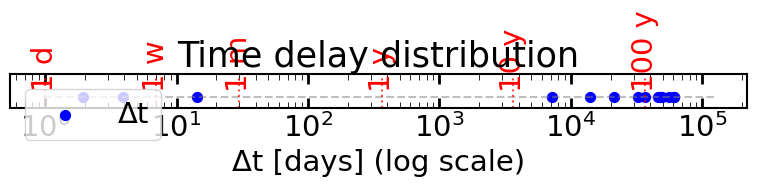

In [161]:
import numpy as np
import matplotlib.pyplot as plt

# 给定时间延迟数据
delays = np.array([
    32168.291, 0.000, 49357.614, 47298.660, 60693.964, 60746.907,
    7131.528, 0.000, 14081.725, 21348.268, 36320.005, 46139.454,
    1.944, 0.000, 3.907, 14.327, 55528.014
])

# 去掉0和负数
delays = delays[delays > 0]

# 单位转换
day = 1
week = 7
month = 30
year = 365
ten_years = 10 * year
hundred_years = 100 * year

scale_points = {
    "1 d": day,
    "1 w": week,
    "1 m": month,
    "1 y": year,
    "10 y": ten_years,
    "100 y": hundred_years,
}

# 作图
plt.figure(figsize=(8, 2))
plt.hlines(1, delays.min()/2, delays.max()*2, color="gray", linestyle="--", alpha=0.5)

plt.scatter(delays, np.ones_like(delays), color="blue", s=50, label="Δt")

# log x 轴
plt.xscale("log")

# 标注时间尺度
for label, t in scale_points.items():
    plt.axvline(t, color="red", linestyle=":", alpha=0.7)
    plt.text(t, 1.05, label, ha="center", va="bottom", rotation=90, color="red")

plt.ylim(0.9, 1.2)
plt.xlabel("Δt [days] (log scale)")
plt.yticks([])
plt.title("Time delay distribution")
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

system-1 (z=6.24): 4 images -> 6 baselines (C(4,2))
system-2 (z=7.59): 5 images -> 10 baselines (C(5,2))
system-3 (z=4.63): 8 images -> 28 baselines (C(8,2))
Total baselines (sum over systems): 44


/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/1424799862.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


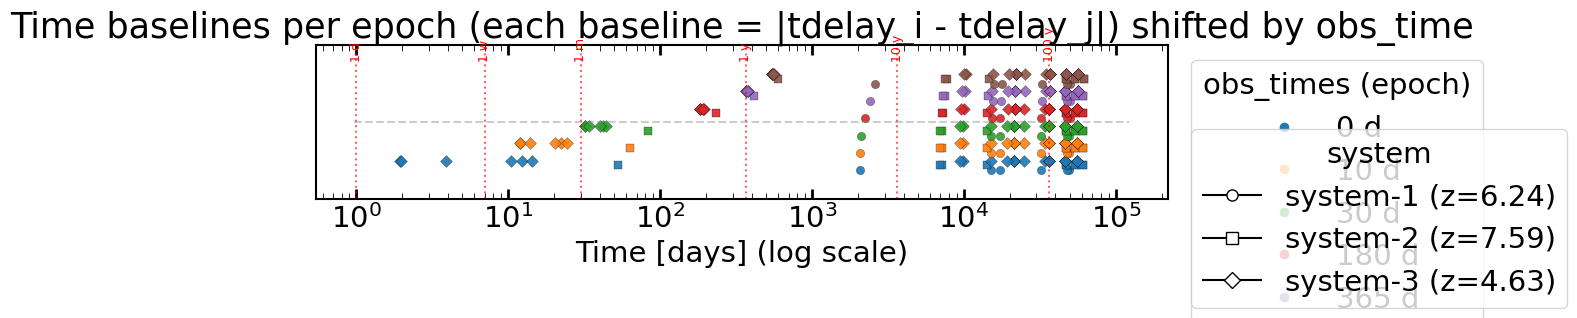

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# --- 输入数据（直接用你给的 structures） ---
# systems_data = {
#     "system-1 (z=6.24)": {
#         "images": [
#             {"RA": 332.9538177, "Dec": -3.8318434, "mu":  3.6479, "tdelay": 32168.291, "mag_F150W2": 26.84, "mag_F150W2_err": 0.00, "mag_F322W2": 24.33, "mag_F322W2_err":0.00},
#             {"RA": 332.9242470, "Dec": -3.8279424, "mu":  2.0554, "tdelay":     0.000, "mag_F150W2": 27.82, "mag_F150W2_err": 0.01, "mag_F322W2": 25.41, "mag_F322W2_err":0.01},
#             {"RA": 332.9442257, "Dec": -3.8191045, "mu": -2.5328, "tdelay": 49357.614, "mag_F150W2": 27.24, "mag_F150W2_err": 0.01, "mag_F322W2": 24.81, "mag_F322W2_err":0.01},
#             {"RA": 332.9406087, "Dec": -3.8406770, "mu": -1.9228, "tdelay": 47298.660, "mag_F150W2": 27.51, "mag_F150W2_err": 0.01, "mag_F322W2": 25.04, "mag_F322W2_err":0.01},
#         ]
#     },
#     "system-2 (z=7.59)": {
#         "images": [
#             {"RA": 332.9404294, "Dec": -3.8343229, "mu": -2.2035, "tdelay": 60693.964},
#             {"RA": 332.9405472, "Dec": -3.8327841, "mu":  1.9793, "tdelay": 60746.907},
#             {"RA": 332.9547679, "Dec": -3.8223497, "mu":  3.1392, "tdelay":  7131.528, "mag_F150W2": 28.51, "mag_F150W2_err": 0.03, "mag_F322W2":26.80, "mag_F322W2_err":0.03},
#             {"RA": 332.9274980, "Dec": -3.8199385, "mu":  3.5452, "tdelay":     0.000, "mag_F150W2": 28.53, "mag_F150W2_err": 0.02, "mag_F322W2":26.75, "mag_F322W2_err":0.02},
#             {"RA": 332.9443550, "Dec": -3.8142570, "mu": -6.3368, "tdelay": 14081.725, "mag_F150W2": 27.71, "mag_F150W2_err": 0.01, "mag_F322W2":25.99, "mag_F322W2_err":0.01},
#         ]
#     },
#     "system-3 (z=4.63)": {
#         "images": [
#             {"RA": 332.9273451, "Dec": -3.8266329, "mu":  3.2094, "tdelay": 21348.268, "mag_F150W2": 26.63, "mag_F150W2_err":0.01, "mag_F322W2":25.40, "mag_F322W2_err":0.01},
#             {"RA": 332.9406675, "Dec": -3.8178557, "mu": -2.2062, "tdelay": 36320.005, "mag_F150W2": 26.83, "mag_F150W2_err":0.01, "mag_F322W2":25.53, "mag_F322W2_err":0.01},
#             {"RA": 332.9384440, "Dec": -3.8382952, "mu": -1.0952, "tdelay": 46139.454, "mag_F150W2": 27.47, "mag_F150W2_err":0.02, "mag_F322W2":26.45, "mag_F322W2_err":0.02},
#             {"RA": 332.9564625, "Dec": -3.8302853, "mu":  4.8202, "tdelay":     1.944, "mag_F150W2": 25.01, "mag_F150W2_err":0.00, "mag_F322W2":24.41, "mag_F322W2_err":0.00},
#             {"RA": 332.9565174, "Dec": -3.8297634, "mu":  4.1950, "tdelay":     0.000, "mag_F150W2": 26.21, "mag_F150W2_err":0.01, "mag_F322W2":25.09, "mag_F322W2_err":0.01},
#             {"RA": 332.9564167, "Dec": -3.8300519, "mu": -3.8745, "tdelay":     3.907, "mag_F150W2": 25.75, "mag_F150W2_err":0.01, "mag_F322W2":24.90, "mag_F322W2_err":0.01},
#             {"RA": 332.9566469, "Dec": -3.8300617, "mu": -0.5077, "tdelay":    14.327},
#             {"RA": 332.9407372, "Dec": -3.8293355, "mu":  0.0764, "tdelay": 55528.014},
#         ]
#     }
# }

# --- 观测 epochs ---
obs_times = np.array([0, 10, 30, 180, 365, 545])  # days

# --- 计算每个 system 的 pairwise baseline (abs difference of tdelay) ---
system_baselines = {}   # system_name -> list of baselines (days)
total_pairs = 0
for sysname, info in systems_data.items():
    tdelays = np.array([img['tdelay'] for img in info['images']])
    # 生成组合并取绝对差
    pairs = []
    for i, j in combinations(range(len(tdelays)), 2):
        baseline = abs(tdelays[i] - tdelays[j])
        pairs.append(baseline)
    system_baselines[sysname] = np.array(pairs)
    total_pairs += len(pairs)
    print(f"{sysname}: {len(info['images'])} images -> {len(pairs)} baselines (C({len(info['images'])},2))")

print(f"Total baselines (sum over systems): {total_pairs}")

# --- 准备绘图参数 ---
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']  # 6 colors for 6 epochs
markers = ['o', 's', 'D']  # marker per system
system_names = list(system_baselines.keys())

# y base and offsets
y_base = 1.0
epoch_y_offsets = np.linspace(-0.18, 0.18, len(obs_times))   # 每个 obs_time 的主要偏移
sys_small_offsets = np.linspace(-0.02, 0.02, len(system_names))  # 同一 epoch 下不同系统的小偏移

# 参考时间尺度
scale_points = {
    "1 d": 1,
    "1 w": 7,
    "1 m": 30,
    "1 y": 365,
    "10 y": 365*10,
    "100 y": 365*100,
}

# 合并所有点以便设定 xlim
all_points = []
for t in obs_times:
    for sys in system_names:
        all_points.append(system_baselines[sys] + t)
all_points = np.concatenate(all_points)

# --- 绘图 ---
plt.figure(figsize=(11, 2))
plt.hlines(y_base, all_points.min()/2, all_points.max()*2, color='gray', linestyle='--', alpha=0.4)

# 对每个 obs_time (epoch) 画出该 epoch 下的所有 system baselines
for ei, t in enumerate(obs_times):
    for si, sys in enumerate(system_names):
        baselines = system_baselines[sys]
        x = baselines + t   # baseline 平移到 epoch 上
        y = np.ones_like(x) * (y_base + epoch_y_offsets[ei] + sys_small_offsets[si])
        plt.scatter(x, y, color=colors[ei], marker=markers[si], s=36,
                    label=f"{t} d" if si == 0 else None, alpha=0.9, edgecolor='k', linewidth=0.2)

# 标注参考时间尺度线
for label, t in scale_points.items():
    plt.axvline(t, color="red", linestyle=":", alpha=0.6)
    plt.text(t, y_base + 0.25, label, ha="center", va="bottom", rotation=90, color="red", fontsize=9)

# log x 轴
plt.xscale("log")
plt.ylim(y_base - 0.32, y_base + 0.32)
plt.yticks([])

plt.xlabel("Time [days] (log scale)")
plt.title("Time baselines per epoch (each baseline = |tdelay_i - tdelay_j|) shifted by obs_time")

# 构建图例：只显示一次每个 obs_time 的颜色和每个 system 的 marker
# epoch legend entries
epoch_handles = [plt.Line2D([0], [0], marker='o', color='w',
                            markerfacecolor=colors[i], markersize=8, label=f"{obs_times[i]} d") for i in range(len(obs_times))]
# system legend entries
sys_handles = [plt.Line2D([0], [0], marker=markers[i], color='k', markerfacecolor='w', markersize=8, label=system_names[i]) for i in range(len(system_names))]

leg1 = plt.legend(handles=epoch_handles, title="obs_times (epoch)", loc='upper left', bbox_to_anchor=(1.01, 1.0))
leg2 = plt.legend(handles=sys_handles, title="system", loc='upper left', bbox_to_anchor=(1.01, 0.55))
plt.gca().add_artist(leg1)

plt.tight_layout()
plt.show()

/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/169530685.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


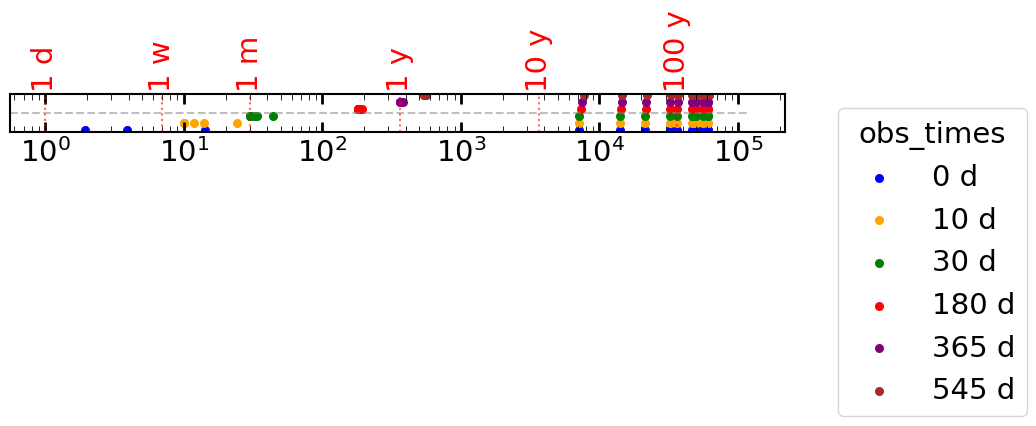

In [163]:
import numpy as np
import matplotlib.pyplot as plt

# 给定 delays
delays = np.array([
    32168.291, 0.000, 49357.614, 47298.660, 60693.964, 60746.907,
    7131.528, 0.000, 14081.725, 21348.268, 36320.005, 46139.454,
    1.944, 0.000, 3.907, 14.327, 55528.014
])
delays = delays[delays >= 0]  # 保留 >=0

# 观测时间点
obs_times = np.array([0, 10, 30, 180, 365, 545])

# 颜色列表
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

# y 方向偏移量
y_base = 0.5
y_offsets = np.linspace(-0.08, 0.08, len(obs_times))  # 六个 obs_times 的小偏移

# 时间尺度标记
scale_points = {
    "1 d": 1,
    "1 w": 7,
    "1 m": 30,
    "1 y": 365,
    "10 y": 365*10,
    "100 y": 365*100,
}

plt.figure(figsize=(10, 0.5))
plt.hlines(y_base, min(delays.min(), obs_times.min())/2,
           max(delays.max(), obs_times.max())*2,
           color="gray", linestyle="--", alpha=0.5)

# 绘制每个 obs_time 平移后的 delays
for t, c, y_off in zip(obs_times, colors, y_offsets):
    shifted = delays + t
    plt.scatter(shifted, np.ones_like(shifted)*(y_base + y_off), color=c, s=30, label=f"{t} d")

# log 轴
plt.xscale("log")

# 时间尺度参考线
for label, t in scale_points.items():
    plt.axvline(t, color="red", linestyle=":", alpha=0.6)
    plt.text(t, y_base + 0.1, label, ha="center", va="bottom", rotation=90, color="red")

# plt.ylim(0.8, 1.2)
# plt.xlabel("Time [days] (log scale)")
plt.yticks([])
# plt.title("Shifted time delays (delays + obs_times)")

plt.legend(title="obs_times", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/1970225530.py:35: UserWarning: Warning: converting a masked element to nan.
  hst_mag      = np.array([col[k] for k in magkey_hst], dtype=float)
/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/1970225530.py:37: UserWarning: Warning: converting a masked element to nan.
  hst_sig      = np.array([col[k] for k in sigkey_hst], dtype=float)


ValueError: 'x' and 'y' must have the same size

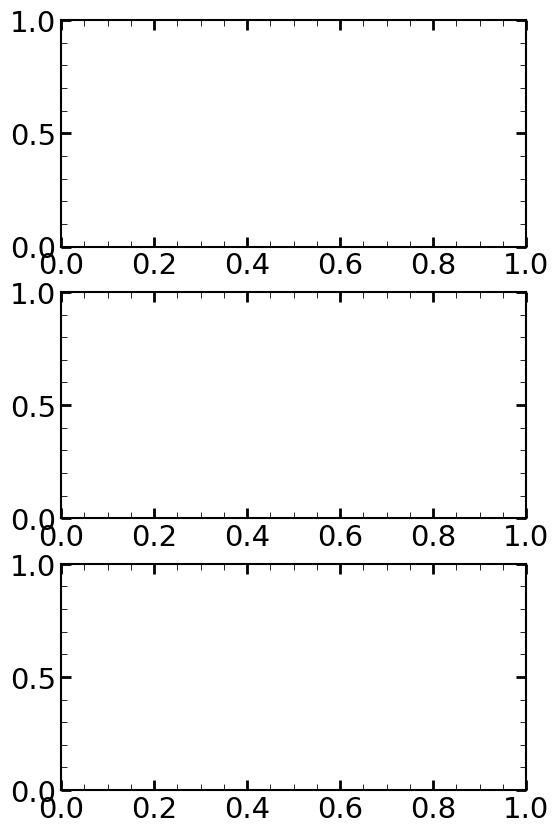

In [291]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# --- AB mag 转 nJy ---
def mag_to_njy(mag):
    return 10**((31.4 - mag) / 2.5)


# bands = ['F125W', 'F140W', 'F105W', 'F606W', 'F435W', 'F814W', 'F160W']
# wave_hst = np.array([1.25, 1.4, 1.05, 0.606, 0.435, 0.814, 1.60])  # micron
# wave_jwst = np.array([1.671, 3.247])

# magkey_hst = [band.lower() + '_mag' for band in bands] 
# magkey_jwst = ['MAG_AUTO_1', 'MAG_AUTO_2']
# magerr_key_hst = [band.lower() + '_magerr_2' for band in bands] 
# magerr_key_jwst = ['MAGERR_AUTO_1', 'MAGERR_AUTO_2']
sigkey_hst = [band.lower() + '_sig_new' for band in hstbands] 

# --- 通用绘图函数 ---
def plot_system(ax, system_key, tab, color_cycle):
    plotted_labels = set()
    images = systems_data[system_key]["images"]

    for col in tab:
        name = col['ID_2']
        if(name in ['2.1','3.4', '3.5', '3.6', '3.7', '3.8']):
            continue
        color = next(color_cycle)
        
        # 找到对应 image 的 mu
        img_idx = int(name.split('.')[1]) - 1
        mu = images[img_idx]["mu"]

        hst_mag      = np.array([col[k] for k in magkey_hst], dtype=float)
        hst_mag_err  = np.array([col[k] for k in magerr_key_hst], dtype=float)
        hst_sig      = np.array([col[k] for k in sigkey_hst], dtype=float)
        # jwst_mag     = np.array([systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F150W2'], systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F322W2']])#np.array([col[k] for k in magkey_jwst], dtype=float)
        # jwst_mag_err = np.array([systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F150W2_err'], systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F322W2_err']])#np.array([col[k] for k in magerr_key_jwst], dtype=float)
        # jwst_mag      = np.array([col[k] for k in magkey_jwst], dtype=float)
        # jwst_mag_err  = np.array([col[k] for k in magerr_key_jwst], dtype=float)
        jwst_flux      = np.array([col[k] for k in fluxkey_jwst], dtype=float)
        jwst_flux_err  = np.array([col[k] for k in fluxerr_key_jwst], dtype=float)

        mu_abs = np.abs(mu)
        hst_mag_corr = hst_mag + 2.5 * np.log10(mu_abs)
        # jwst_mag_corr = jwst_mag + 2.5 * np.log10(mu_abs)
        jwst_flux = jwst_flux / mu_abs
        jwst_flux_err = jwst_flux_err / mu_abs

        factor = 245.78743366/jwst_flux[-1]

        # --- 修正放大率 ---
        mu_abs = np.abs(mu)
        hst_mag_corr = hst_mag + 2.5 * np.log10(mu_abs)
        # jwst_mag_corr = jwst_mag + 2.5 * np.log10(mu_abs)
        hst_mag_err = hst_mag_err + 2.5 * np.log10(mu_abs)

        # --- 转换为 flux ---
        hst_flux = mag_to_njy(hst_mag_corr)
        # jwst_flux = mag_to_njy(jwst_mag_corr)
        hst_flux_err = mag_to_njy(hst_mag_err) #hst_flux * (np.log(10)/2.5) * hst_mag_err
        # jwst_flux_err = jwst_flux * (np.log(10)/2.5) * jwst_mag_err

        # mask
        det_mask = (hst_sig >= 2) & np.isfinite(hst_flux)
        uplim_mask = (~det_mask) & np.isfinite(hst_flux_err)

        # 检测点
        # if np.any(det_mask):
        #     ax.errorbar(
        #         wave_hst[det_mask], hst_flux[det_mask],
        #         yerr=hst_flux_err[det_mask],
        #         fmt='o', ms=5, color=color, mfc='white', mew=1,
        #         elinewidth=1, capsize=2
        #     )

        # # 上限 (横杠 + 箭头)
        # if np.any(uplim_mask):
        #     x_uplim = wave_hst[uplim_mask]
        #     y_uplim = 3*hst_flux_err[uplim_mask]
        #     ax.scatter(x_uplim, y_uplim, marker='_', color=color, s=40, linewidths=1.5)
        #     for x, y in zip(x_uplim, y_uplim):
        #         ax.annotate(
        #             '', xy=(x, y*0.7), xytext=(x, y),
        #             arrowprops=dict(arrowstyle='-|>', color=color, lw=1.2,
        #                             shrinkA=0, shrinkB=0)
        #         )

        # JWST
        if np.all(np.isfinite(jwst_flux)):
            ax.errorbar(
                wave_jwst, jwst_flux, yerr=jwst_flux_err,
                fmt='s', ms=7, color=color, mfc='none', mew=1,
                elinewidth=1, capsize=2,
                label=name if name not in plotted_labels else None
            )
            plotted_labels.add(name)

    ax.set_yscale("log")
    ax.grid(alpha=0.3, which='both')
    ax.legend(fontsize=10)
    ax.set_ylabel("Intrinsic Flux Density (nJy)", fontsize = 13)

# --- 主绘图 ---
fig, axes = plt.subplots(3, 1, sharex=False, figsize=(6, 10))

# system-1
mask1 = np.array(['1.' in i for i in tab_hst_jwst_combined['ID_2']])
sel1 = tab_hst_jwst_combined[mask1]
plot_system(axes[0], "system-1 (z=6.07)", sel1, cycle(plt.cm.tab10.colors))
axes[0].set_title("LRD 1 (z=6.07)")
axes[0].plot(wave_rest_spec * 7.24 , fnu_spec*9)
axes[0].axvline(0.3656 *  7.24, color = 'gray', ls = '--')
axes[0].set_xlim(0.5, 5)
axes[0].set_ylim(1e1, 7e2)
# system-2
mask2 = np.array(['2.' in i for i in tab_hst_jwst_combined['ID_2']])
sel2 = tab_hst_jwst_combined[mask2]
plot_system(axes[1], "system-2 (z=4.31)", sel2, cycle(plt.cm.tab10.colors))
axes[1].set_title("LRD 2 (z=4.31)")
axes[1].plot(wave_rest_spec * 5.31 , fnu_spec*1.4)
axes[1].axvline(0.3656 *  5.31, color = 'gray', ls = '--')
axes[1].set_xlim(0.5, 5)
axes[1].set_ylim(1e0, 2e2)
axes[1].set_xlabel("Observed Wavelength (µm)")
# system-3
mask3 = np.array(['3.' in i for i in tab_hst_jwst_combined['ID_2']])
sel3 = tab_hst_jwst_combined[mask3]
plot_system(axes[2], "system-3 (z=4.63)", sel3, cycle(plt.cm.tab10.colors))
axes[2].set_title("LRD 3 (z=4.63)")
axes[2].plot(wave_rest_spec * 5.63 , fnu_spec*10)
axes[2].axvline(0.3656 *  5.63, color = 'gray', ls = '--')
axes[2].set_xlim(0.4, 5)
axes[2].set_ylim(1e1, 7e2)
axes[2].set_xlabel("Observed Wavelength (µm)")

plt.tight_layout()
plt.savefig('hst_jwst_sed.png')
# plt.show()

In [89]:
for col in sel_tab:
    name = col['ID_2']
    color = next(color_cycle)

    img_idx = int(name.split('.')[1]) - 1
    mu = systems_data["system-1 (z=6.07)"]["images"][img_idx]["mu"]

    hst_mag      = np.array([col[k] for k in magkey_hst], dtype=float)
    hst_mag_err  = np.array([col[k] for k in magerr_key_hst], dtype=float)
    hst_sig      = np.array([col[k] for k in sigkey_hst], dtype=float)
    # jwst_mag     = np.array([systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F150W2'], systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F322W2']])#np.array([col[k] for k in magkey_jwst], dtype=float)
    # jwst_mag_err = np.array([systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F150W2_err'], systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F322W2_err']])#np.array([col[k] for k in magerr_key_jwst], dtype=float)
    # jwst_mag      = np.array([col[k] for k in magkey_jwst], dtype=float)
    # jwst_mag_err  = np.array([col[k] for k in magerr_key_jwst], dtype=float)
    jwst_flux      = np.array([col[k] for k in fluxkey_jwst], dtype=float)
    jwst_flux_err  = np.array([col[k] for k in fluxerr_key_jwst], dtype=float)

    mu_abs = np.abs(mu)
    hst_mag_corr = hst_mag + 2.5 * np.log10(mu_abs)
    # jwst_mag_corr = jwst_mag + 2.5 * np.log10(mu_abs)
    jwst_flux = jwst_flux / mu_abs
    jwst_flux_err = jwst_flux_err / mu_abs

    factor = 245.78743366/jwst_flux[-1]
    
    jwstflux_list.append(jwst_flux*factor)
    jwstfluxerr_list.append(jwst_flux_err*factor)
    print(name)
    print(jwst_flux)
    hst_flux = mag_to_njy(hst_mag_corr)
    # jwst_flux = mag_to_njy(jwst_mag_corr)

    hst_flux_err = mag_to_njy(hst_mag_err)# hst_flux * (np.log(10)/2.5) * hst_mag_err
    # jwst_flux_err = jwst_flux * (np.log(10)/2.5) * jwst_mag_err

    det_mask = (hst_sig >= 2) & np.isfinite(hst_flux)
    uplim_mask = (~det_mask) & np.isfinite(hst_flux_err)

    # jwst_mask = (jwst_mag_err > 0)*(jwst_mag < 40)*(jwst_mag > 20)
    # 检测点
    if np.any(det_mask):
        ax.errorbar(
            wave_hst[det_mask], hst_flux[det_mask]*factor,
            yerr=hst_flux_err[det_mask]*factor,
            fmt='o', ms=5, color=color, mfc='white', mew=1,
            elinewidth=1, capsize=2,
            
        )
        

    # 上限：横杠+箭头
    if np.any(uplim_mask):
        x_uplim = wave_hst[uplim_mask]
        y_uplim = hst_flux_err[uplim_mask]
        ax.scatter(x_uplim, y_uplim, marker='_', color=color, s=40, linewidths=1.5)

        # 画箭头：短竖线+箭头头部
        for x, y in zip(x_uplim, y_uplim):
            ax.annotate(
                '', xy=(x, y*0.7), xytext=(x, y),  # 竖向移动 30%
                arrowprops=dict(arrowstyle='-|>', color=color, lw=1.2, shrinkA=0, shrinkB=0)
            )

    # JWST
    if np.all(np.isfinite(jwst_flux)):
        ax.errorbar(
            wave_jwst, jwst_flux*factor, yerr=jwst_flux_err*factor,
            fmt='s', ms=7, color=color, mfc='none', mew=1,
            elinewidth=1, capsize=2, 
            label=name if name not in plotted_labels else None
        )
        plotted_labels.add(name)
ax.set_ylim(4, 4e2)
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Intrinsic Flux Density (nJy)")
ax.set_yscale("log")
ax.grid(alpha=0.3, which='both')
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

1.1
[  7.44116728   9.44436043  17.59941256  23.76716994  25.31535976
 112.70934803 113.23203663 266.65072258 216.41911114 245.78743366]
1.2
[  8.93983163   9.61142978  12.38338234  21.42517149  23.14307797
  68.86948048  64.55743112 177.72561423 147.27972334 160.18780368]
1.3
[ 11.89778906  11.976512    17.65517501  25.88414316  29.78570829
 102.96521356 102.86681234 255.04635401 203.66172489 228.23241908]
1.4
[  4.49342937  16.29813563  15.31635374  22.65449749  35.89604486
 108.51139419 109.08241058 277.652365   215.58271449 233.2352926 ]


/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/2833531907.py:8: UserWarning: Warning: converting a masked element to nan.
  hst_mag      = np.array([col[k] for k in magkey_hst], dtype=float)
/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_15208/2833531907.py:10: UserWarning: Warning: converting a masked element to nan.
  hst_sig      = np.array([col[k] for k in sigkey_hst], dtype=float)


<Figure size 640x480 with 0 Axes>

In [76]:
data = Table.read('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/COSMOS-Web_LRDs_stacked_SED.dat', format="ascii")
mask = (data['logwavrest'] < 0.001) & (data['logwavrest'] > -0.914)
logwave_rest = data['logwavrest'][mask]
lognuLnu = data['lognuLnu'][mask]
wave_rest_spec = 10**logwave_rest
wave_m = wave_rest_spec.value * 1e-6               # 单位：m
c = 2.99792458e8                        # 单位：m/s
nu = c / wave_m                         # 单位：Hz
nuLnu = 10**lognuLnu                 # 单位：W
fnu_spec = nuLnu / nu * 1e6 * u.nJy

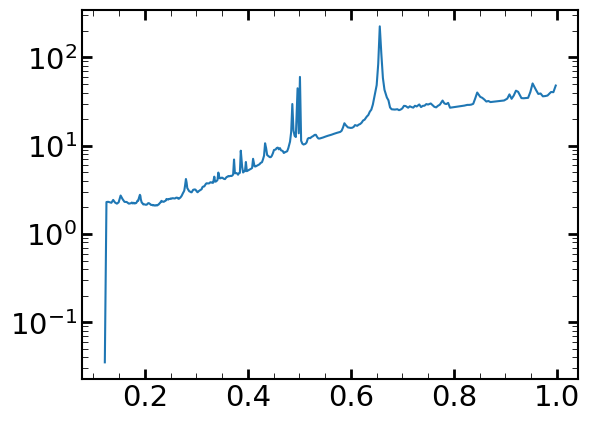

In [77]:
plt.plot(wave_rest_spec, fnu_spec)
plt.yscale('log')
# plt.xlim(0.1, 3)

In [51]:
hst_mag_err[det_mask]

array([], dtype=float64)

In [38]:
tab_hst_jwst_combined

id_1,ra_1,dec_1,f435w_mag,f435w_magerr_1,f435w_flux,f435w_fluxerr,f435w_fluxnJy,f435w_fluxnJyerr,f435w_sig,f606w_mag,f606w_magerr_1,f606w_flux,f606w_fluxerr,f606w_fluxnJy,f606w_fluxnJyerr,f606w_sig,f814w_mag,f814w_magerr_1,f814w_flux,f814w_fluxerr,f814w_fluxnJy,f814w_fluxnJyerr,f814w_sig,f105w_mag,f105w_magerr_1,f105w_flux,f105w_fluxerr,f105w_fluxnJy,f105w_fluxnJyerr,f105w_sig,f125w_mag,f125w_magerr_1,f125w_flux,f125w_fluxerr,f125w_fluxnJy,f125w_fluxnJyerr,f125w_sig,f140w_mag,f140w_magerr_1,f140w_flux,f140w_fluxerr,f140w_fluxnJy,f140w_fluxnJyerr,f140w_sig,f160w_mag,f160w_magerr_1,f160w_flux,f160w_fluxerr,f160w_fluxnJy,f160w_fluxnJyerr,f160w_sig,NUMBER_1,ID_PARENT_1,FLUX_ISO_1,FLUXERR_ISO_1,MAG_ISO_1,MAGERR_ISO_1,FLUX_ISOCOR_1,FLUXERR_ISOCOR_1,MAG_ISOCOR_1,MAGERR_ISOCOR_1,FLUX_APER_1,FLUXERR_APER_1,MAG_APER_1,MAGERR_APER_1,FLUX_AUTO_1,FLUXERR_AUTO_1,MAG_AUTO_1,MAGERR_AUTO_1,FLUX_PETRO_1,FLUXERR_PETRO_1,MAG_PETRO_1,MAGERR_PETRO_1,FLUX_BEST_1,FLUXERR_BEST_1,MAG_BEST_1,MAGERR_BEST_1,FLUX_WIN_1,FLUXERR_WIN_1,MAG_WIN_1,MAGERR_WIN_1,SNR_WIN_1,KRON_RADIUS_1,PETRO_RADIUS_1,BACKGROUND_1,THRESHOLD_1,FLUX_MAX_1,ISOAREA_IMAGE_1,ISOAREAF_IMAGE_1,XMIN_IMAGE_1,YMIN_IMAGE_1,XMAX_IMAGE_1,YMAX_IMAGE_1,XPEAK_IMAGE_1,YPEAK_IMAGE_1,XPEAK_FOCAL_1,YPEAK_FOCAL_1,XPEAK_WORLD_1,YPEAK_WORLD_1,X_IMAGE_1,Y_IMAGE_1,ALPHA_J2000_1,DELTA_J2000_1,ALPHA_B1950_1,DELTA_B1950_1,A_IMAGE_1,B_IMAGE_1,THETA_IMAGE_1,FLAGS_1,FWHM_IMAGE_1,FWHM_WORLD_1,ELONGATION_1,ELLIPTICITY_1,CLASS_STAR_1,FLUX_RADIUS_1,ORIGIN_1,Separation_1,NUMBER_2,ID_PARENT_2,FLUX_ISO_2,FLUXERR_ISO_2,MAG_ISO_2,MAGERR_ISO_2,FLUX_ISOCOR_2,FLUXERR_ISOCOR_2,MAG_ISOCOR_2,MAGERR_ISOCOR_2,FLUX_APER_2,FLUXERR_APER_2,MAG_APER_2,MAGERR_APER_2,FLUX_AUTO_2,FLUXERR_AUTO_2,MAG_AUTO_2,MAGERR_AUTO_2,FLUX_PETRO_2,FLUXERR_PETRO_2,MAG_PETRO_2,MAGERR_PETRO_2,FLUX_BEST_2,FLUXERR_BEST_2,MAG_BEST_2,MAGERR_BEST_2,FLUX_WIN_2,FLUXERR_WIN_2,MAG_WIN_2,MAGERR_WIN_2,SNR_WIN_2,KRON_RADIUS_2,PETRO_RADIUS_2,BACKGROUND_2,THRESHOLD_2,FLUX_MAX_2,ISOAREA_IMAGE_2,ISOAREAF_IMAGE_2,XMIN_IMAGE_2,YMIN_IMAGE_2,XMAX_IMAGE_2,YMAX_IMAGE_2,XPEAK_IMAGE_2,YPEAK_IMAGE_2,XPEAK_FOCAL_2,YPEAK_FOCAL_2,XPEAK_WORLD_2,YPEAK_WORLD_2,X_IMAGE_2,Y_IMAGE_2,ALPHA_J2000_2,DELTA_J2000_2,ALPHA_B1950_2,DELTA_B1950_2,A_IMAGE_2,B_IMAGE_2,THETA_IMAGE_2,FLAGS_2,FWHM_IMAGE_2,FWHM_WORLD_2,ELONGATION_2,ELLIPTICITY_2,CLASS_STAR_2,FLUX_RADIUS_2,ORIGIN_2,Separation_1a,ra_2,dec_2,f125w_fluxerr_njy,f125w_magerr_2,f140w_fluxerr_njy,f140w_magerr_2,f105w_fluxerr_njy,f105w_magerr_2,f606w_fluxerr_njy,f606w_magerr_2,f435w_fluxerr_njy,f435w_magerr_2,f814w_fluxerr_njy,f814w_magerr_2,f160w_fluxerr_njy,f160w_magerr_2,ID_2,Separation,new_f125w_sig,new_f140w_sig,new_f105w_sig,new_f606w_sig,new_f435w_sig,new_f814w_sig,new_f160w_sig,f125w_sig_new,f140w_sig_new,f105w_sig_new,f606w_sig_new,f435w_sig_new,f814w_sig_new,f160w_sig_new
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,,,,ct,ct,ct,pix2,pix2,pix,pix,pix,pix,pix,pix,,,deg,deg,pix,pix,deg,deg,deg,deg,pix,pix,deg,,pix,deg,,,,pix,,arcsec,,,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,,,,ct,ct,ct,pix2,pix2,pix,pix,pix,pix,pix,pix,,,deg,deg,pix,pix,deg,deg,deg,deg,pix,pix,deg,,pix,deg,,,,pix,,arcsec,,,,,,,,,,,,,,,,,,arcsec,,,,,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int32,int32,float32,float32,float32,float32,float32,float32,float32,float32,float32[10],float32[10],float32[10],float32[10],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,floa